In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.20


# Cosmetic settings

In [2]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}



period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

# 1. Workbook setups

## 1.1 Import packages

In [3]:
import numpy as np
np.random.seed(42) ### for reproducibility

from numpy.linalg import inv, LinAlgError, pinv

import xarray as xr

import pandas as pd
pd.options.mode.chained_assignment = None  # Disable warnings
pd.set_option("display.float_format", "{:.2f}".format)  # Reduce memory usage
import geopandas as gpd
import math

import scipy as scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from scipy.spatial import cKDTree

from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.neighbors import BallTree

from odrpack import odr_fit

### import curve_fit
from scipy.optimize import curve_fit

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle, Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cmocean.cm as cmo
import seaborn as sns

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
import regionmask

import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *
from TEXAS.models import predict_sst_from_tex86, predict_tex86_from_sst
from TEXAS.data import MahalanobisOutlierDetector
print("texas-psm verion:", TEXAS.__version__)

texas-psm verion: 0.1.10


## 1.2 Miscellaneous codes

### 1.2.2 Miscellaneous math and distance calculations

In [4]:
def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

def count_decimal_places(number):
    s = str(number)
    if '.' in s:
        return len(s.split('.')[-1])
    else:
        return 0

def round_up_to_next5(n):
    # This formula calculates the remainder (n % 5) 
    # and determines how much to add to reach the next multiple of 5.
    return n + (5 - n) % 5

def round_down_to_nearest_5(x):
    # Convert to string to determine decimal places
    str_x = str(x)
    if '.' in str_x:
        decimal_places = len(str_x.split('.')[1])
    else:
        decimal_places = 0
    
    # Step size is 5 * 10^(-decimal_places)
    step = 5 * 10**(-decimal_places)
    
    # Round down to nearest step
    return math.floor(x / step) * step

def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

import inspect
from IPython.display import Markdown
def display_function_signature(func):
    sig = inspect.signature(func)
    params = []
    for param_name, param in sig.parameters.items():
        if param.default != inspect.Parameter.empty:
            params.append(f"    {param_name}={param.default}")
        else:
            params.append(f"    {param_name}")

    formatted = f"{func.__name__}(\n" + ",\n".join(params) + "\n)"
    return Markdown(f"```python\n{formatted}\n```")

### 1.2.3 Oceanographic calculations

In [5]:
def integrate_profile_to_depth(temp_profile, depths, max_depth):
    """
    Integrate temperature from surface to max_depth
    Returns integrated value (°C·m) or NaN
    """
    # Handle invalid inputs
    if np.isnan(max_depth) or max_depth <= 0:
        return np.nan
    
    # Get valid (non-NaN) data
    valid = ~np.isnan(temp_profile)
    if valid.sum() < 2:
        return np.nan
    
    temp_valid = temp_profile[valid]
    depth_valid = depths[valid]
    
    # Only use depths from surface to max_depth
    mask = depth_valid <= max_depth
    if mask.sum() < 2:
        # Not enough points - return single point or NaN
        if mask.sum() == 1:
            # Single point: assume constant from 0 to that depth
            return temp_valid[mask][0] * depth_valid[mask][0]
        return np.nan
    
    temp_subset = temp_valid[mask]
    depth_subset = depth_valid[mask]
    
    # If max_depth is deeper than our deepest valid point, 
    # interpolate value at max_depth
    if depth_subset[-1] < max_depth:
        # Find next deeper point for interpolation
        deeper_mask = depth_valid > depth_subset[-1]
        if deeper_mask.any():
            next_idx = np.where(deeper_mask)[0][0]
            # Interpolate
            temp_at_max = np.interp(
                max_depth,
                [depth_subset[-1], depth_valid[next_idx]],
                [temp_subset[-1], temp_valid[next_idx]]
            )
            # Add interpolated point
            depth_subset = np.append(depth_subset, max_depth)
            temp_subset = np.append(temp_subset, temp_at_max)
    
    # Trapezoidal integration
    integrated = np.trapz(temp_subset, depth_subset)
    
    return integrated


def depth_average_profile_to_depth(temp_profile, depths, max_depth):
    """
    Calculate depth-averaged temperature from surface to max_depth
    Returns mean temperature (°C) or NaN
    """
    # Get integrated value
    integrated = integrate_profile_to_depth(temp_profile, depths, max_depth)
    
    if np.isnan(integrated) or np.isnan(max_depth) or max_depth <= 0:
        return np.nan
    
    # Divide by depth range to get average
    # Assuming integration starts from surface (depth = 0)
    # If your first depth is not 0, adjust accordingly
    first_depth = 0  # or depths[0] if integration doesn't start at surface
    depth_range = max_depth - first_depth
    
    if depth_range <= 0:
        return np.nan
    
    return integrated / depth_range




In [6]:
# ── sig-fig helpers (self-contained) ─────────────────────────────────────────

def _n_decimals(scale: float) -> int:
    """Decimal places needed to show `scale` to 1-2 sig figs (GUM §7.2.6)."""
    if not math.isfinite(scale) or scale <= 0:
        return 3
    mag = math.floor(math.log10(abs(scale)))
    first_digit = int(abs(scale) / 10 ** mag)
    return max(0, 1 - mag) if first_digit <= 3 else max(0, -mag)


def _format_stat(median: float, std: float, fmt: str | None = None) -> str:
    """Return 'median ± std' formatted to appropriate significant figures.
    Uncertainty drives precision: 1 sig fig on std (2 if leading digit <= 3).

    Parameters
    ----------
    fmt : str or None
        Optional format spec override (e.g. ``'.3f'``, ``'.2e'``).
        When given, both median and std are formatted with this spec and
        the automatic sig-fig logic is bypassed entirely.
    """
    if fmt is not None:
        return f"{median:{fmt}} ± {std:{fmt}}"
    if not math.isfinite(std) or std <= 0:
        return f"{median:.3g}"
    n_dec = _n_decimals(std)
    fmt   = f".{n_dec}f"
    return f"{round(median, n_dec):{fmt}} ± {round(std, n_dec):{fmt}}"


# ── formatting helpers ────────────────────────────────────────────────────────

def _fmt_r2(r2: float) -> str:
    """R² precision driven by unexplained variance; capped at 3 d.p."""
    n = min(_n_decimals(1 - r2), 3)
    return f"{round(r2, n):.{n}f}"


def _fmt_rmse(rmse: float) -> str:
    """RMSE always reported to 2 sig figs."""
    mag = math.floor(math.log10(abs(rmse)))
    n   = max(0, 1 - mag)
    return f"{round(rmse, n):.{n}f}"


def _fmt_delta_r2(dr2: float) -> str:
    if abs(dr2) == 0:
        return f"{dr2:.3f}"
    n = _n_decimals(abs(dr2))
    return f"{round(dr2, n):.{n}f}"


def _fmt_p(p: float) -> str:
    if p < 0.001:
        return "<0.001"
    mag = math.floor(math.log10(abs(p)))
    return f"{round(p, -mag + 1):.2e}"


def _fmt_coef(coef: float, ci_halfwidth: float) -> str:
    """coef ± 95% CI, precision driven by CI half-width."""
    sigma = ci_halfwidth / 1.96
    return _format_stat(coef, sigma)


def _fmt_delta(delta: float) -> str:
    """Delta to 2 sig figs with sign."""
    if abs(delta) == 0:
        return "+0.000"
    d_mag = math.floor(math.log10(abs(delta)))
    nd    = max(0, 1 - d_mag)
    return f"{delta:+.{nd}f}"


## 1.3  Functional forms

In [7]:
def generalized_logistic_model(x, x0, b, a, k, v, Q, C=1):
    """
    Generalized logistic model function.
    
    Parameters:
    - x: Independent variable (e.g., temperature)
    - x0: Inflection point (the value of x at which the function changes from concave down to concave up)
    
    - b: Lower asymptote (left asymptote)
    - a: the right horizontal asymptote when C = 1. If b = 0 and C = 1, then a is the carrying capacity.
    - k: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is b + (a - b) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + (a - b) / np.power(C + Q * np.exp(-k * (x - x0)), 1/v)
    return Y

def generalized_logistic_inflection_point(x0, k, v):
    """
    Calculate the inflection point of a generalized logistic function.

    Parameters:
    - x0 (float or array): center/shift parameter
    - k (float or array): growth rate
    - v (float or array): shape/asymmetry parameter (nu)

    Returns:
    - Inflection point (same shape as input)
    """
    return x0 + np.log(v) / k

def generalized_logistic_model_fixed_upper(x, x0, b, k, v):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + np.exp(-k * (x - x0)), 1/v))
    return Y

def linear_model(x, m, b):
    return m * x + b

## 1.4 Dictionaries

In [8]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':4,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren5 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren2 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':2, 
    'fGDGT_cren':2,
    'reported_1292_iso':2,
    'fGDGT_cren_prime':2,
    'reported_1292_iso2':2,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised_cren3 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':3, 
    'fGDGT_cren':3,
    'reported_1292_iso':3,
    'fGDGT_cren_prime':3,
    'reported_1292_iso2':3,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


## 1.5 Set local paths

In [9]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# Detect environment
IN_DOCKER = Path("/home/micromamba/app").exists()

if IN_DOCKER:
    local_onedrive_path = Path("/mnt/onedrive")
    local_github_path = Path("/home/micromamba/app")
    print(local_github_path)
else:
    local_onedrive_path = Path.home() / "OneDrive"   # adjust if needed
    local_github_path = Path.home() / "Documents/GitHub/TEXAS"
    print(local_github_path)

Set CMDSTAN -> /home/rrattan/miniforge3/envs/texas-env/bin/cmdstan
/home/rrattan/Documents/GitHub/TEXAS


# 2. Import data

## 2.1 Ocean products

### 2.1.1 WOA23 - Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [10]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

### 2.1.3 WOA23 and CMEMS Nitrate

CMEMS = Copernicus Marine Environmental Monitoring Service

- Nitrate - Mole concentration of nitrate in sea water 0.25deg x 0.25deg
- Unit: mmol/m3
- Link to data product website: https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/description

- Raw data: monthly climatology hindcasts from 1993-2022 (30 years)
- Processing: The climatology mean field of annual average were generated from 30-year montly climatologies using ncclimo function (https://nco.sourceforge.net/nco.html)

In [11]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
### calculate thermocline along depth dimension of T_1deg_da using min T gradient approach (depth with the fastest drop in T)
### calculate using diff method from xarray and divide by the diff of depth
sliced_T_1deg_da = T_1deg_da.sel(depth=slice(0,1100))
gradient = sliced_T_1deg_da.diff('depth')/sliced_T_1deg_da.depth.diff('depth')

### mask NaN values
gradient = abs(gradient.where(~np.isnan(T_1deg_da)))

### fill NaN values with infinity to avoid error in argmin
gradient_filled = gradient.fillna(-np.inf)
maxabs_gradient_idx = gradient_filled.argmax('depth',skipna=True).astype(int)+1

### mask locations where all depth values are NaN
all_nan_mask = np.isnan(sliced_T_1deg_da).all('depth')

### mask maxabs_gradient_idx where all depth values are NaN
maxabs_gradient_idx = maxabs_gradient_idx.where(~all_nan_mask, drop=False)

# Flatten the lat-lon grid for advanced indexing
stacked = sliced_T_1deg_da.stack(grid=["lat", "lon"])

# Ensure maxabs_gradient_idx is an integer, replacing NaN with a valid placeholder index (e.g., 0)
valid_idx = maxabs_gradient_idx.fillna(0).astype(int)

# Use isel to index the depth dimension with the flattened indices
thermoT_depth_values = stacked["depth"].isel(depth=valid_idx.stack(grid=["lat", "lon"]))
thermoT_values = stacked.isel(depth=valid_idx.stack(grid=["lat", "lon"]))
# Mask locations where maxabs_gradient_idx was NaN
nan_mask = maxabs_gradient_idx.isnull()
thermoT_depth_values = thermoT_depth_values.where(~nan_mask.stack(grid=["lat", "lon"]))
thermoT_values = thermoT_values.where(~nan_mask.stack(grid=["lat", "lon"]))
# Unstack to return to the original lat-lon dimensions
thermoT_depth_1deg_da = thermoT_depth_values.unstack("grid")
thermoT_1deg_da = thermoT_values.unstack("grid")
masked_T_1deg_da = T_1deg_da.where(T_1deg_da["depth"]<=thermoT_depth_1deg_da)

len_notnull_values_along_depth = np.unique(masked_T_1deg_da.notnull().sum('depth').values)
sel_masked_1deg_da = masked_T_1deg_da
tmp_1deg_da = xr.DataArray(np.zeros_like(sel_masked_1deg_da.isel(depth=0).values),
                      dims=sel_masked_1deg_da.isel(depth=0).dims,
                      coords=sel_masked_1deg_da.isel(depth=0).coords
                      )
tmp_1deg_da
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = sel_masked_1deg_da.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            sel_masked_1deg_da.where(sel_masked_1deg_da.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        
        # Update tmp_1deg_da with the calculated values at the same grid points
    tmp_1deg_da = tmp_1deg_da.where(~mask, other=cal_values)
tmp_1deg_da2 = tmp_1deg_da
#### mask locations where there are more than 1 valid depth values
mask_below_SST = sel_masked_1deg_da.notnull().sum('depth') > 1
cal_values = tmp_1deg_da2.where(mask_below_SST)/thermoT_depth_1deg_da.where(mask_below_SST)
# apply mask where all depth values are NaN
all_nan_mask = np.isnan(sel_masked_1deg_da).all('depth')
tmp_1deg_da2 = tmp_1deg_da2.where(~all_nan_mask)

thermocline_depthIntegral_T_1deg_da = tmp_1deg_da2.where(~mask_below_SST, other=cal_values)
thermocline_depthIntegral_T_1deg_da


<xarray.DataArray (lat: 180, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [-1.2768773, -1.2799466, -1.2829043, ..., -1.4295026, -1.271273 ,
        -1.2740542],
       [-1.2734717, -1.274759 , -1.2760662, ..., -1.2691069, -1.2707332,
        -1.2721268],
       [-1.2634081, -1.2634081, -1.2634081, ..., -1.2634081, -1.2634081,
        -1.2634081]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    depth    float32 0.0

In [12]:
fpath = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/nitrate'
fname = 'woa23_all_n00_01.nc'

woa23_nitrate_ds = xr.open_dataset(os.path.join(fpath,fname),decode_times=False).drop('time')
woa23_nitrate = woa23_nitrate_ds.isel(time=0).n_an.load()
woa23_nitrate_sea = woa23_nitrate_ds.isel(time=0).n_sea.load()

In [13]:
masked_woa23_nitrate_regrid_lld_da = woa23_nitrate.where(woa23_nitrate["depth"]<=thermoT_depth_1deg_da)
masked_tmp_grid = masked_woa23_nitrate_regrid_lld_da
len_notnull_values_along_depth = np.unique(masked_tmp_grid.notnull().sum('depth').values)
tmp_da = xr.DataArray(np.zeros_like(masked_tmp_grid.isel(depth=0).values),
                      dims=masked_tmp_grid.isel(depth=0).dims,
                      coords=masked_tmp_grid.isel(depth=0).coords
                      )
tmp_da2 = xr.DataArray(np.zeros_like(masked_tmp_grid.isel(depth=0).values),
                        dims=masked_tmp_grid.isel(depth=0).dims,
                        coords=masked_tmp_grid.isel(depth=0).coords
                        )
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = masked_tmp_grid.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=0)
        )
        cal_values2 = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        ### grab last value of nitrate
        cal_values2 = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .isel(depth=i-1)
        )
    # Update tmp_da with the calculated values at the same grid points
    tmp_da = tmp_da.where(~mask, other=cal_values)
    tmp_da2 = tmp_da2.where(~mask, other=cal_values2)

#### mask locations where there are more than 1 valid depth values
mask_below_surface = masked_tmp_grid.notnull().sum('depth') > 1
cal_values = tmp_da.where(mask_below_surface)/thermoT_depth_1deg_da.where(mask_below_surface)

# apply mask where all depth values are NaN
all_nan_mask = np.isnan(masked_tmp_grid).all('depth')
tmp_da = tmp_da.where(~all_nan_mask)
thermocline_depthIntegral_woa23_nitrate_da = tmp_da
thermocline_depthIntegral_woa23_nitrate_da = thermocline_depthIntegral_woa23_nitrate_da.where(~mask_below_surface, other=cal_values)
display(thermocline_depthIntegral_woa23_nitrate_da)

tmp_da2 = tmp_da2.where(~all_nan_mask)
thermocline_woa23_nitrate_da = tmp_da2
display(thermocline_woa23_nitrate_da)


<xarray.DataArray (lat: 180, lon: 360)>
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [5.9040422, 5.9228544, 5.946482 , ..., 5.058457 , 5.8687625,
        5.88737  ],
       [5.67362  , 5.685511 , 5.6993546, ..., 5.6302495, 5.6478033,
        5.661916 ],
       [5.414655 , 5.414655 , 5.414655 , ..., 5.414655 , 5.414655 ,
        5.414655 ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    depth    float32 0.0

<xarray.DataArray (lat: 180, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [11.059551 , 11.109554 , 11.168578 , ..., 10.237384 , 10.963257 ,
        11.0125885],
       [10.045896 , 10.079221 , 10.116056 , ...,  9.940072 ,  9.9796095,
        10.013854 ],
       [ 8.903845 ,  8.903845 ,  8.903845 , ...,  8.903845 ,  8.903845 ,
         8.903845 ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

In [14]:
masked_woa23_nitrate_sea_regrid_lld_da = woa23_nitrate_sea.where(woa23_nitrate_sea["depth"]<=thermoT_depth_1deg_da)
masked_tmp_grid = masked_woa23_nitrate_sea_regrid_lld_da
len_notnull_values_along_depth = np.unique(masked_tmp_grid.notnull().sum('depth').values)
tmp_da = xr.DataArray(np.zeros_like(masked_tmp_grid.isel(depth=0).values),
                      dims=masked_tmp_grid.isel(depth=0).dims,
                      coords=masked_tmp_grid.isel(depth=0).coords
                      )
tmp_da2 = xr.DataArray(np.zeros_like(masked_tmp_grid.isel(depth=0).values),
                        dims=masked_tmp_grid.isel(depth=0).dims,
                        coords=masked_tmp_grid.isel(depth=0).coords
                        )
# Loop through the unique counts of non-NaN values along depth
for i in len_notnull_values_along_depth:
    if i == 0:
        continue  # Skip cases where no valid data is available
    # Select grid points where the non-NaN count equals `i`
    mask = masked_tmp_grid.notnull().sum('depth') == i
    
    if i == 1:
        # if only one valid depth slice, use the first depth slice
        cal_values = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=0)
        )
        cal_values2 = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=0)
        )
    else:
        # Calculate the integrated values for the valid depth slices
        cal_values = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .integrate('depth')
        )
        ### grab last value of nitrate
        cal_values2 = (
            masked_tmp_grid.where(masked_tmp_grid.notnull().sum('depth') == i)
            .isel(depth=slice(0, i))
            .isel(depth=i-1)
        )
    # Update tmp_da with the calculated values at the same grid points
    tmp_da = tmp_da.where(~mask, other=cal_values)
    tmp_da2 = tmp_da2.where(~mask, other=cal_values2)

#### mask locations where there are more than 1 valid depth values
mask_below_surface = masked_tmp_grid.notnull().sum('depth') > 1
cal_values = tmp_da.where(mask_below_surface)/thermoT_depth_1deg_da.where(mask_below_surface)

# apply mask where all depth values are NaN
all_nan_mask = np.isnan(masked_tmp_grid).all('depth')
tmp_da = tmp_da.where(~all_nan_mask)
thermocline_depthIntegral_woa23_nitrate_sea_da = tmp_da
thermocline_depthIntegral_woa23_nitrate_sea_da = thermocline_depthIntegral_woa23_nitrate_sea_da.where(~mask_below_surface, other=cal_values)
display(thermocline_depthIntegral_woa23_nitrate_sea_da)

tmp_da2 = tmp_da2.where(~all_nan_mask)
thermocline_woa23_nitrate_sea_da = tmp_da2
display(thermocline_woa23_nitrate_sea_da)


<xarray.DataArray (lat: 180, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.00314259, 0.00314381, 0.0031437 , ..., 0.00319127, 0.00315098,
        0.0031492 ],
       [0.00198524, 0.00198616, 0.0019825 , ..., 0.00199898, 0.00199754,
        0.00199386],
       [0.00127881, 0.00128082, 0.00127841, ..., 0.00128983, 0.00128739,
        0.00128498]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    depth    float32 0.0

<xarray.DataArray (lat: 180, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.00165038, 0.00164833, 0.00164801, ..., 0.0041907 , 0.00165454,
        0.00165262],
       [0.00119318, 0.00119185, 0.00118981, ..., 0.00119707, 0.00119665,
        0.00119536],
       [0.00084924, 0.00084891, 0.00084814, ..., 0.0008517 , 0.00085087,
        0.00085005]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

### 2.1.4 Depth-integrated calculations

In [15]:
from scipy.stats import gamma
def gamma_weighted_mean_temperature(temp_da, depths, a=4.5, scale=15, max_depth=200):
    """
    Calculate gamma-weighted mean temperature
    
    The gamma distribution gives more weight to shallower depths
    with peak weight at depth = (a-1)*scale
    
    Parameters
    ----------
    temp_da : xarray.DataArray
        Temperature data
    depths : array
        Depth values
    a : float
        Gamma distribution shape parameter (alpha)
    scale : float
        Gamma distribution scale parameter (beta)
    max_depth : float
        Maximum depth for integration
    
    Returns
    -------
    xarray.DataArray
        Gamma-weighted mean temperature
    """
    # Select depth range
    temp_subset = temp_da.sel(depth=slice(0, max_depth))
    depths_subset = temp_subset['depth'].values
    
    # Calculate gamma weights at each depth
    weights = gamma.pdf(depths_subset, a=a, scale=scale)
    
    # Create DataArray for weights
    weights_da = xr.DataArray(weights, dims=['depth'], coords={'depth': depths_subset})
    
    # Multiply temperature by weights
    weighted_temp = temp_subset * weights_da
    
    # Integrate over depth (sum of weighted values * depth spacing)
    integrated_weighted = weighted_temp.integrate('depth')
    
    # Integrate weights to normalize
    integrated_weights = weights_da.integrate('depth')
    
    # Weighted mean = integral(T*w) / integral(w)
    gamma_weighted_mean = integrated_weighted / integrated_weights
    
    return gamma_weighted_mean

#### 2.1.4.1 Temperature integration calculations

In [16]:

mean_temp_0_200m = T_da.sel(depth=slice(0,200)).mean('depth')

weighted_temp_0_200m = gamma_weighted_mean_temperature(T_da, T_da['depth'].values, 
                                                        a=4.5, scale=15, max_depth=200)



### 2.1.6 Processed ocean properties --- Rattanasriampaipong et al. 2025

In [17]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds['no3_sf2tc_avg_woa23_1deg'] = thermocline_woa23_nitrate_da.interp_like(ocean_prop_ds['no3_sf2tc_avg'])
ocean_prop_ds

<xarray.Dataset>
Dimensions:                   (lat: 720, lon: 1440)
Coordinates:
  * lat                       (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                       (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    no3_sf2tc_avg             (lat, lon) float32 ...
    no3_tc                    (lat, lon) float32 ...
    t_sf2tc_avg               (lat, lon) float32 ...
    tc_depth                  (lat, lon) float32 ...
    t_tc                      (lat, lon) float32 ...
    no3_sf2tc_avg_woa23_1deg  (lat, lon) float32 nan nan nan nan ... nan nan nan
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

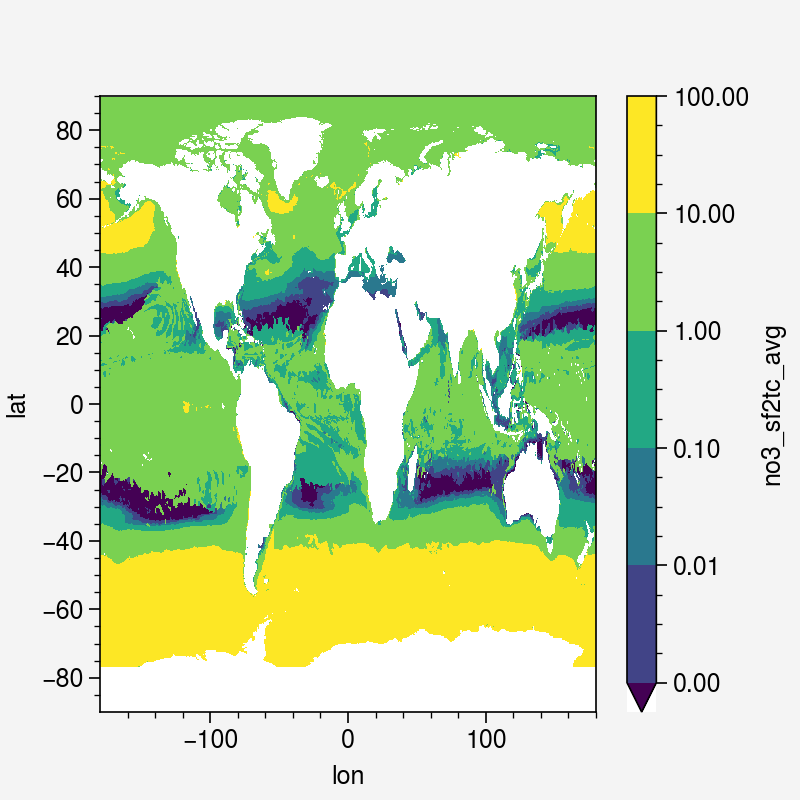

In [18]:
ocean_prop_ds['no3_sf2tc_avg'].plot(robust=True,levels=[1e-3,1e-2,1e-1,1,10,100])

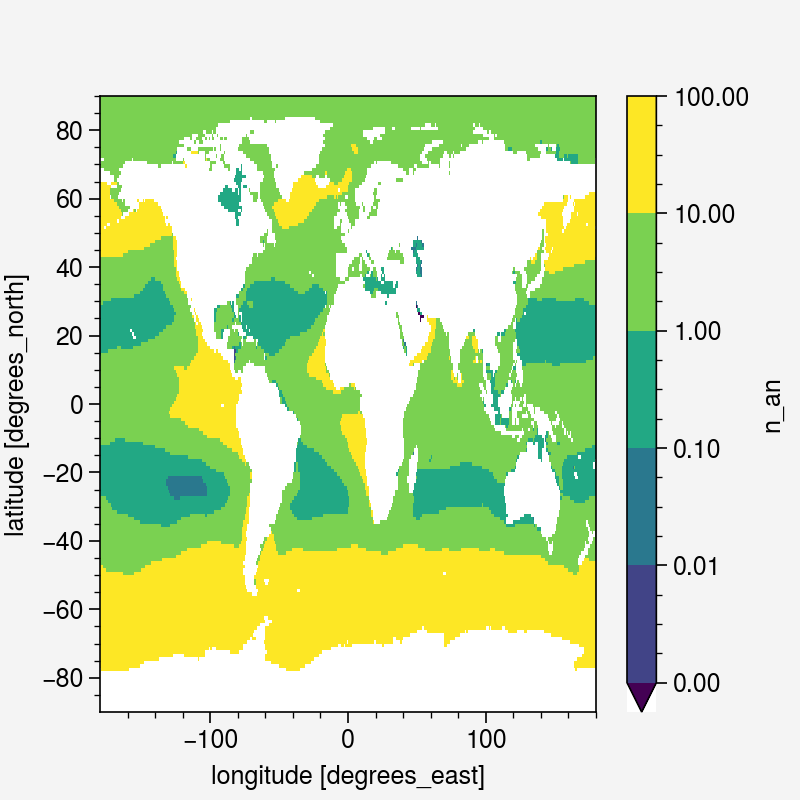

In [19]:
woa23_nitrate.sel(depth=slice(0,200)).mean('depth').plot(robust=True,levels=[1e-3,1e-2,1e-1,1,10,100])

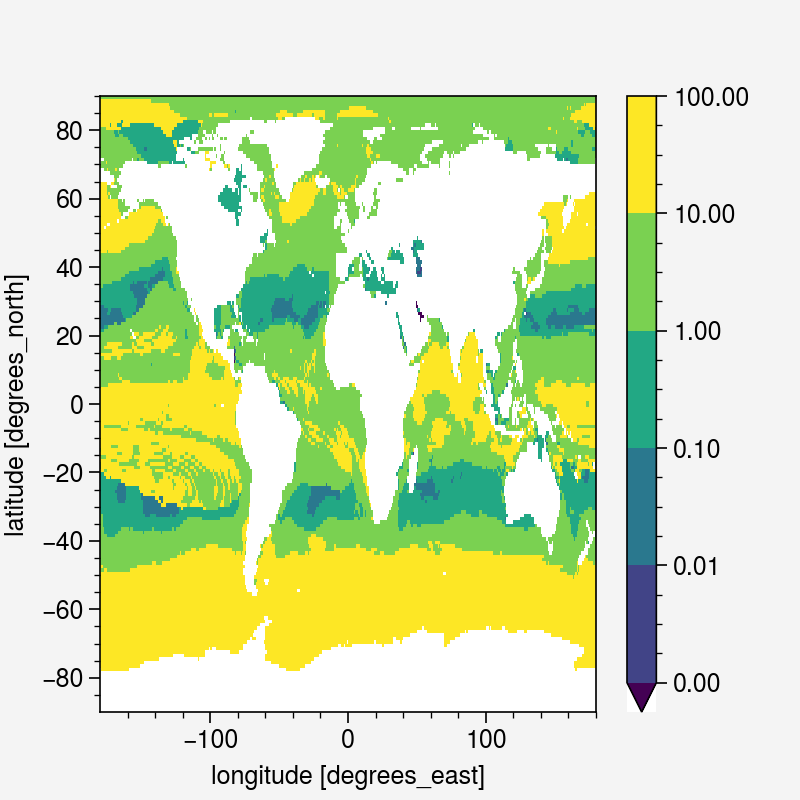

In [20]:
thermocline_woa23_nitrate_da.plot(robust=True,levels=[1e-3,1e-2,1e-1,1,10,100])

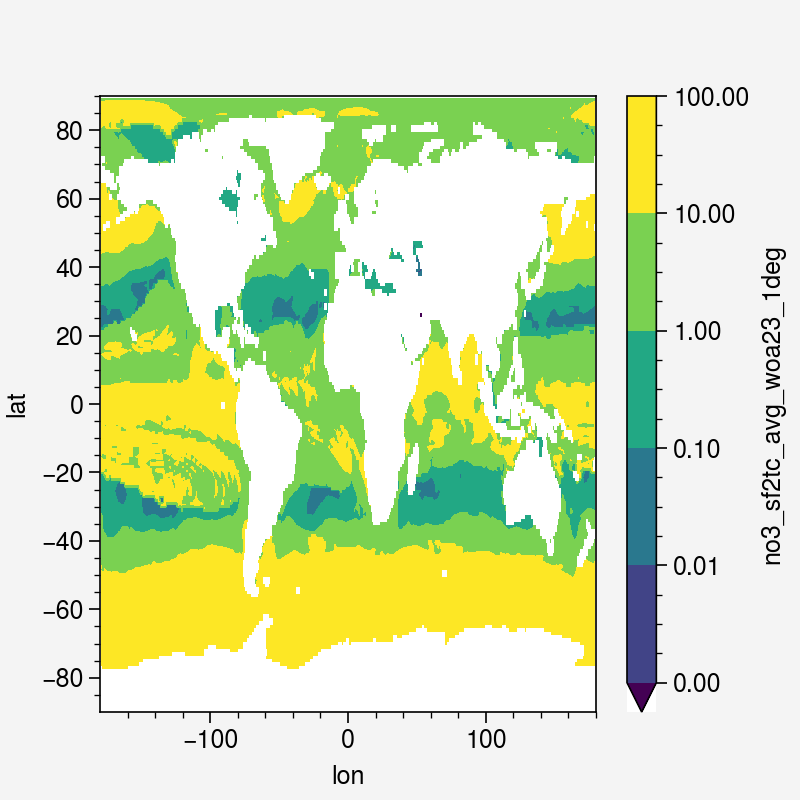

In [21]:
ocean_prop_ds['no3_sf2tc_avg_woa23_1deg'].plot(robust=True,levels=[1e-3,1e-2,1e-1,1,10,100])

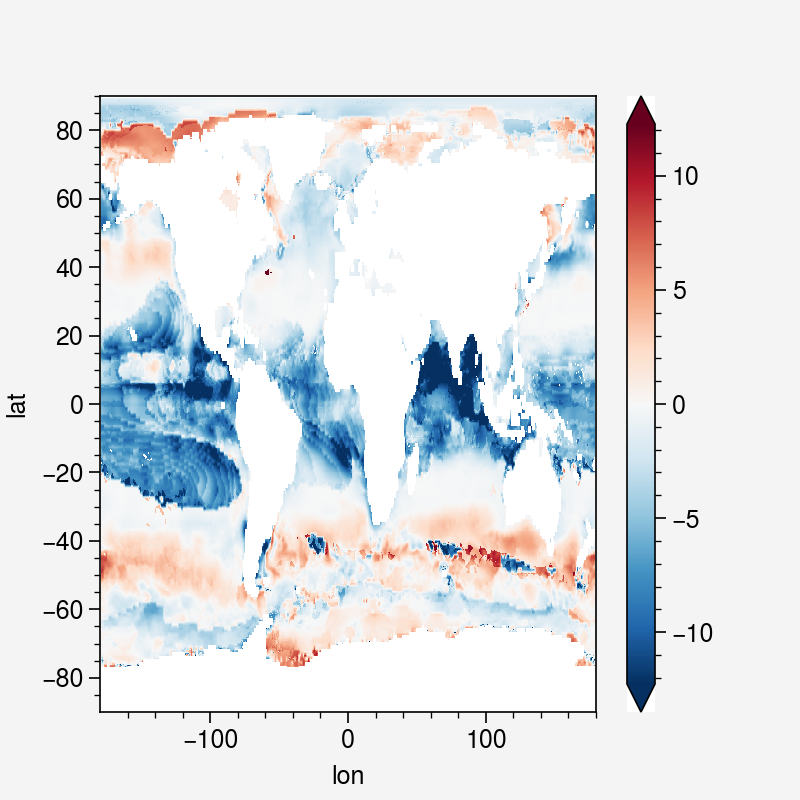

In [22]:
(ocean_prop_ds['no3_sf2tc_avg'] - ocean_prop_ds['no3_sf2tc_avg_woa23_1deg']).plot(robust=True)

## 2.2 Coretop compilation

In [23]:
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'ds01_updated_global_coretop_tex_revised_011226.csv'


coretop_df = pd.read_csv(os.path.join(fpath,fname))
coretop_df = coretop_df.rename(columns={
    'latitude':'Latitude',
    'longitude':'Longitude',
    'depth':'modernWaterDepth',
    'tex86':'TEX86',
    'bit':'BIT'
})
coretop_df = coretop_df[coretop_df['exclude_data']!='yes']
coretop_df['TEX86L'] = (coretop_df['fGDGT_2']) / (coretop_df['fGDGT_1'] + coretop_df['fGDGT_2'] + coretop_df['fGDGT_3'])
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,publicationYear,reference_name,remark,exclude_data,exclusion_remark,reference_link,dataset_DOI,OPTiMAL_Dnearest,OPTiMAL_SST,TEX86L
0,JET_RR_00001,GeoB7702-3,GC,5.00,6.00,31.65,34.07,562.00,NaN,NaN,...,2010,Castaneda2010,Data published in Tierney & Tingley (2015),NaN,NaN,http://dx.doi.org/10.1029/2009PA001740,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,NaN,NaN,10.5281/zenodo.14806962,0.25,21.64,0.47
2,JET_RR_00003,KNR195-5-6 MC12,MC,0.00,1.00,-3.71,-81.12,378.00,NaN,NaN,...,2011,Chazen2011,Data published in Tierney & Tingley (2015),NaN,NaN,https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
3,JET_RR_00004,KNR195-5-7 MC16,MC,0.00,1.00,-3.75,-81.14,379.00,NaN,NaN,...,2011,Chazen2011,Data published in Tierney & Tingley (2015),NaN,NaN,https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,NaN,NaN,10.5281/zenodo.14806962,0.30,19.29,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.14,27.14,0.46
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.42,26.12,0.44
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.90,25.55,0.46
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,2026,Tran2026,Data from original source,NaN,NaN,NaN,NaN,0.48,24.25,0.43


### 2.2.1 calculate GDGT indices

In [24]:
coretop_df['lowAbundanceFlag'] = False
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
features_noCren = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']
tex_features = ['fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren_prime']
coretop_df = coretop_df.dropna(subset=features)
## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    coretop_df['lowAbundanceFlag'] = coretop_df['lowAbundanceFlag'] | (((coretop_df[feature]>0) & (coretop_df[feature]<0.001))
                                                                       & coretop_df[feature].notna())


coretop_df['inv_fGDGT0'] = 1-coretop_df['fGDGT_0']

coretop_df['weighted_tex'] = np.sum(coretop_df[tex_features] * [ringNumbers_dict_zhang16.get(col) for col in tex_features], axis=1)/np.sum(coretop_df[tex_features], axis=1)
coretop_df['weighted_tex_cren2'] = np.sum(coretop_df[tex_features] * [ringNumbers_dict_revised_cren2.get(col) for col in tex_features], axis=1)/np.sum(coretop_df[tex_features], axis=1)
coretop_df['weighted_tex_cren3'] = np.sum(coretop_df[tex_features] * [ringNumbers_dict_revised_cren3.get(col) for col in tex_features], axis=1)/np.sum(coretop_df[tex_features], axis=1)
coretop_df['weighted_tex_cren5'] = np.sum(coretop_df[tex_features] * [ringNumbers_dict_revised_cren5.get(col) for col in tex_features], axis=1)/np.sum(coretop_df[tex_features], axis=1)

coretop_df['ringIndex'] = np.sum(coretop_df[features] * [ringNumbers_dict_zhang16.get(col) for col in features], axis=1)/np.sum(coretop_df[features], axis=1)
coretop_df['ringIndex_cren2'] = np.sum(coretop_df[features] * [ringNumbers_dict_revised_cren2.get(col) for col in features], axis=1)/np.sum(coretop_df[features], axis=1)
coretop_df['ringIndex_cren3'] = np.sum(coretop_df[features] * [ringNumbers_dict_revised_cren3.get(col) for col in features], axis=1)/np.sum(coretop_df[features], axis=1)
coretop_df['ringIndex_cren5'] = np.sum(coretop_df[features] * [ringNumbers_dict_revised_cren5.get(col) for col in features], axis=1)/np.sum(coretop_df[features], axis=1)
coretop_df['ringIndex_noCren'] = np.sum(coretop_df[features_noCren] * [ringNumbers_dict_zhang16.get(col) for col in features_noCren], axis=1)/np.sum(coretop_df[features_noCren], axis=1)
coretop_df['ringIndex_noCren_cren2'] = np.sum(coretop_df[features_noCren] * [ringNumbers_dict_revised_cren2.get(col) for col in features_noCren], axis=1)/np.sum(coretop_df[features_noCren], axis=1)
coretop_df['ringIndex_noCren_cren3'] = np.sum(coretop_df[features_noCren] * [ringNumbers_dict_revised_cren3.get(col) for col in features_noCren], axis=1)/np.sum(coretop_df[features_noCren], axis=1)
coretop_df['ringIndex_noCren_cren5'] = np.sum(coretop_df[features_noCren] * [ringNumbers_dict_revised_cren5.get(col) for col in features_noCren], axis=1)/np.sum(coretop_df[features_noCren], axis=1)
coretop_df['ringIndex_noCrens'] = np.sum(coretop_df[features[:-2]] * [ringNumbers_dict_zhang16.get(col) for col in features[:-2]], axis=1)/np.sum(coretop_df[features[:-2]], axis=1)

RI_TEX = -0.77*coretop_df['TEX86'] + 3.32*coretop_df['TEX86']**2 + 1.59
coretop_df['deltaRI'] = RI_TEX - coretop_df['ringIndex']
coretop_df['scaledRI'] = coretop_df['ringIndex']/4
coretop_df['scaledRI_cren2'] = coretop_df['ringIndex_cren2']/2
coretop_df['scaledRI_cren3'] = coretop_df['ringIndex_cren3']/3
coretop_df['scaledRI_cren5'] = coretop_df['ringIndex_cren5']/5
coretop_df['scaledRI_noCren'] = coretop_df['ringIndex_noCren']/4
coretop_df['scaledRI_noCren_cren2'] = coretop_df['ringIndex_noCren_cren2']/2
coretop_df['scaledRI_noCren_cren3'] = coretop_df['ringIndex_noCren_cren3']/3
coretop_df['scaledRI_noCren_cren5'] = coretop_df['ringIndex_noCren_cren5']/5
coretop_df['scaledRI_noCrens'] = coretop_df['ringIndex_noCrens']/3
coretop_df['gdgt23ratio'] = coretop_df['fGDGT_2']/coretop_df['fGDGT_3']
coretop_df['gdgt23ratio_se'] = 0.1
coretop_df['ZeroOverZeroCren'] = coretop_df['fGDGT_0']/(coretop_df['fGDGT_cren']+coretop_df['fGDGT_0'])
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,scaledRI_cren3,scaledRI_cren5,scaledRI_noCren,scaledRI_noCren_cren2,scaledRI_noCren_cren3,scaledRI_noCren_cren5,scaledRI_noCrens,gdgt23ratio,gdgt23ratio_se,ZeroOverZeroCren
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,0.60,0.57,0.17,0.28,0.21,0.15,0.15,13.18,0.10,0.40
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,0.66,0.63,0.18,0.30,0.22,0.16,0.16,4.88,0.10,0.33
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,0.64,0.61,0.19,0.31,0.23,0.16,0.18,4.41,0.10,0.35
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,0.62,0.60,0.19,0.30,0.23,0.17,0.16,6.87,0.10,0.37
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,0.58,0.55,0.17,0.29,0.21,0.15,0.16,8.43,0.10,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.72,0.69,0.25,0.40,0.30,0.22,0.22,3.96,0.10,0.27
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.71,0.68,0.24,0.39,0.29,0.21,0.22,3.40,0.10,0.27
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.77,0.74,0.27,0.46,0.33,0.24,0.27,3.06,0.10,0.21
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.69,0.66,0.21,0.36,0.26,0.18,0.21,3.21,0.10,0.30


### 2.2.2 match ocean properties

In [25]:
woa23_04deg_lats = T_da['lat'].values
woa23_04deg_lons = T_da['lon'].values

coretop_df['match_lat_04deg'] = coretop_df['Latitude'].apply(lambda x: woa23_04deg_lats[np.abs(woa23_04deg_lats - x).argmin()])
coretop_df['match_lon_04deg'] = coretop_df['Longitude'].apply(lambda x: woa23_04deg_lons[np.abs(woa23_04deg_lons - x).argmin()])

coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,scaledRI_noCren,scaledRI_noCren_cren2,scaledRI_noCren_cren3,scaledRI_noCren_cren5,scaledRI_noCrens,gdgt23ratio,gdgt23ratio_se,ZeroOverZeroCren,match_lat_04deg,match_lon_04deg
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,0.17,0.28,0.21,0.15,0.15,13.18,0.10,0.40,-1.62,-86.88
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,0.18,0.30,0.22,0.16,0.16,4.88,0.10,0.33,-3.88,-81.38
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,0.19,0.31,0.23,0.16,0.18,4.41,0.10,0.35,-3.62,-81.12
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,0.19,0.30,0.23,0.17,0.16,6.87,0.10,0.37,-3.12,-82.88
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,0.17,0.29,0.21,0.15,0.16,8.43,0.10,0.42,-3.62,-83.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.25,0.40,0.30,0.22,0.22,3.96,0.10,0.27,-27.38,112.12
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.24,0.39,0.29,0.21,0.22,3.40,0.10,0.27,-28.12,112.62
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.27,0.46,0.33,0.24,0.27,3.06,0.10,0.21,-28.12,112.88
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,0.21,0.36,0.26,0.18,0.21,3.21,0.10,0.30,-28.38,113.12


In [26]:
woa23_nitrate

<xarray.DataArray 'n_an' (depth: 102, lat: 180, lon: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.5065072 , 0.5077519 , 0.50824255, ..., 0.49354407,
         0.49962154, 0.50394267],
        [0.5509077 , 0.552426  , 0.55362046, ..., 0.53350955,
         0.5418536 , 0.54766   ],
        [0.5734835 , 0.5734835 , 0.5734835 , ..., 0.5734835 ,
         0.5734835 , 0.5734835 ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  moles_of_nitrate_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_nitrate_per...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

In [27]:
thermocline_woa23_nitrate_da

<xarray.DataArray (lat: 180, lon: 360)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [11.059551 , 11.109554 , 11.168578 , ..., 10.237384 , 10.963257 ,
        11.0125885],
       [10.045896 , 10.079221 , 10.116056 , ...,  9.940072 ,  9.9796095,
        10.013854 ],
       [ 8.903845 ,  8.903845 ,  8.903845 , ...,  8.903845 ,  8.903845 ,
         8.903845 ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

In [28]:
coretop_df['SST'] = np.array([
    T_da.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').isel(depth=0).values
    for _, row in coretop_df.iterrows()
])


coretop_df['t_sf2tc_avg'] = np.array([
    ocean_prop_ds['t_sf2tc_avg'].sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])


coretop_df['no3_sf2tc_avg'] = np.array([
    ocean_prop_ds['no3_sf2tc_avg'].sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['no3_sf2tc_woa23'] = np.array([
    np.atleast_1d(thermocline_woa23_nitrate_da.sel(lon=x,lat=y,method='nearest'))[0]
    for x, y in zip(coretop_df['match_lon_04deg'],coretop_df['match_lat_04deg'])
])

coretop_df['thermoNO3_se'] = pd.DataFrame([
    np.atleast_1d(thermocline_woa23_nitrate_sea_da.sel(lon=x,lat=y,method='nearest'))[0]
    for x, y in zip(coretop_df['match_lon_04deg'],coretop_df['match_lat_04deg'])
]).fillna(0)


In [29]:
def get_nearest_valid_value(ds, target_lats, target_lons, lat_dim='lat', lon_dim='lon'):
    """
    Finds the nearest non-NaN value in an xarray dataset for a set of coordinates.
    Useful for getting ocean data while skipping land pixels.
    """
    # 1. Extract the variable and ensure we only have lat/lon dimensions
    # (If your ds has 'time', this selects the first time step or assumes it's already sliced)
    data_slice = ds
    
    # 2. Stack and remove NaNs (Land)
    # This creates a 1D array of only valid ocean points
    ocean_points = data_slice.stack(grid_point=(lat_dim, lon_dim)).dropna('grid_point')
    
    # 3. Get coordinates of valid ocean points
    ocean_coords = np.column_stack((ocean_points[lat_dim].values, 
                                    ocean_points[lon_dim].values))
    
    # 4. Build the tree
    tree = cKDTree(ocean_coords)
    
    # 5. Format target coordinates
    target_coords = np.column_stack((target_lats, target_lons))
    
    # 6. Query tree for nearest indices
    # distances can be used to filter out points that are "too far" from any ocean
    distances, indices = tree.query(target_coords)
    
    # 7. Return the values
    return ocean_points.isel(grid_point=indices).values

In [30]:
#### handling missing near land data
SST_da = T_da.isel(depth=0)
nan_idx_sst = coretop_df['SST'].isna()
print(f"{nan_idx_sst.sum()} sites requires SST nearest-neighbor infilling")
coretop_df.loc[nan_idx_sst,'SST'] = get_nearest_valid_value(
    ds=SST_da,
    target_lats=coretop_df.loc[nan_idx_sst,'Latitude'],
    target_lons=coretop_df.loc[nan_idx_sst,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)

thermoT_da = ocean_prop_ds['t_sf2tc_avg']
nan_idx_thermoT = coretop_df['t_sf2tc_avg'].isna()
print(f"{nan_idx_thermoT.sum()} sites requires thermoT nearest-neighbor infilling")
coretop_df.loc[nan_idx_thermoT,'t_sf2tc_avg'] = get_nearest_valid_value(
    ds=thermoT_da,
    target_lats=coretop_df.loc[nan_idx_thermoT,'Latitude'],
    target_lons=coretop_df.loc[nan_idx_thermoT,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)

thermoNO3_da = ocean_prop_ds['no3_sf2tc_avg']
nan_idx_thermoNO3 = coretop_df['no3_sf2tc_avg'].isna()
print(f"{nan_idx_thermoNO3.sum()} sites requires thermoNO3 nearest-neighbor infilling")
coretop_df.loc[nan_idx_thermoNO3,'no3_sf2tc_avg'] = get_nearest_valid_value(
    ds=thermoNO3_da,
    target_lats=coretop_df.loc[nan_idx_thermoNO3,'Latitude'],
    target_lons=coretop_df.loc[nan_idx_thermoNO3,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)

thermoNO3_woa23_da = thermocline_woa23_nitrate_da
nan_idx_thermoNO3 = coretop_df['no3_sf2tc_woa23'].isna()
print(f"{nan_idx_thermoNO3.sum()} sites requires thermoNO3 (WOA23) nearest-neighbor infilling")
coretop_df.loc[nan_idx_thermoNO3,'no3_sf2tc_woa23'] = get_nearest_valid_value(
    ds=thermoNO3_woa23_da,
    target_lats=coretop_df.loc[nan_idx_thermoNO3,'Latitude'],
    target_lons=coretop_df.loc[nan_idx_thermoNO3,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)

thermoNO3_se_da = thermocline_depthIntegral_woa23_nitrate_sea_da
nan_idx_thermoNO3_se = coretop_df['thermoNO3_se'].isna()
print(f"{nan_idx_thermoNO3_se.sum()} sites requires thermoNO3 nearest-neighbor infilling")
coretop_df.loc[nan_idx_thermoNO3_se,'thermoNO3_se'] = get_nearest_valid_value(
    ds=thermoNO3_se_da,
    target_lats=coretop_df.loc[nan_idx_thermoNO3_se,'Latitude'],
    target_lons=coretop_df.loc[nan_idx_thermoNO3_se,'Longitude'],
    lat_dim='lat',
    lon_dim='lon'
)



120 sites requires SST nearest-neighbor infilling
120 sites requires thermoT nearest-neighbor infilling
231 sites requires thermoNO3 nearest-neighbor infilling
446 sites requires thermoNO3 (WOA23) nearest-neighbor infilling
60 sites requires thermoNO3 nearest-neighbor infilling


In [31]:
display(coretop_df[['SST','TEX86']].corr(method='spearman'))
display(coretop_df[['SST','ringIndex']].corr(method='spearman'))
display(coretop_df[['SST','weighted_tex']].corr(method='spearman'))
display(coretop_df[['SST','weighted_tex_cren3']].corr(method='spearman'))
display(coretop_df[['SST','ringIndex_cren3']].corr(method='spearman'))
display(coretop_df[['SST','ringIndex_noCren_cren3']].corr(method='spearman'))

,SST,TEX86
SST,1.00,0.87
TEX86,0.87,1.00


,SST,ringIndex
SST,1.00,0.85
ringIndex,0.85,1.00


,SST,weighted_tex
SST,1.00,0.79
weighted_tex,0.79,1.00


,SST,weighted_tex_cren3
SST,1.00,0.82
weighted_tex_cren3,0.82,1.00


,SST,ringIndex_cren3
SST,1.00,0.86
ringIndex_cren3,0.86,1.00


,SST,ringIndex_noCren_cren3
SST,1.00,0.91
ringIndex_noCren_cren3,0.91,1.00


## 2.3 Culture-Mesocosm Data

In [32]:
### Regression dataset compilation
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'culture_mesocosm_combined_rev_092325.xlsx'

culture_meso_df = pd.read_excel(os.path.join(fpath, fname),sheet_name='culture_mesocosm_combined_rev_0')
culture_meso_df

,sampleID,sampleName,Source,TLE_method,MS_method,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,OPTiMAL_Dnearest,OPTiMAL_SST
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,37,0.58,2.79,0.70,0.48,...,0.13,0.44,0.08,culture,0.42,0.17,0,Culture-temperature_Terrestrial thermophile,16.22,15.54
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,46,0.81,3.73,0.93,0.48,...,0.04,0.71,0.17,culture,0.12,0.01,0,Culture-temperature_Terrestrial thermophile,3.03,15.66
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,50,0.76,3.73,0.93,0.65,...,0.03,0.75,0.14,culture,0.11,0.01,0,Culture-temperature_Terrestrial thermophile,2.22,16.33
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NAOA2_18,Elling et al. (2015) GCA,NaN,NaN,18,0.86,2.44,0.61,0.40,...,0.43,0.16,0.02,culture,0.80,0.43,0,Culture-temperature_Marine mesophile,79.57,15.54
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NAOA2_22,Elling et al. (2015) GCA,NaN,NaN,22,0.83,2.24,0.56,1.09,...,0.24,0.20,0.01,culture,0.74,0.45,0,Culture-temperature_Marine mesophile,40.85,15.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,TEXAS_PSM_culture_RR167,meso_017,Schouten2007,NaN,NaN,25,0.45,2.77,0.69,2.63,...,0.01,0.64,0.01,mesocosm,0.16,0.27,0,NaN,0.70,16.22
167,TEXAS_PSM_culture_RR168,meso_018,Schouten2007,NaN,NaN,32,0.68,2.63,0.66,3.55,...,0.02,0.56,0.04,mesocosm,0.17,0.33,0,NaN,0.51,24.19
168,TEXAS_PSM_culture_RR169,meso_019,Schouten2007,NaN,NaN,34,0.61,3.24,0.81,2.32,...,0.02,0.75,0.01,mesocosm,0.13,0.14,0,NaN,1.02,23.32
169,TEXAS_PSM_culture_RR170,meso_020,Schouten2007,NaN,NaN,36,0.81,3.60,0.90,2.40,...,0.02,0.82,0.03,mesocosm,0.11,0.06,0,NaN,1.53,18.86


## 2.4 Combined dataset --- Coretop, Mesocosm, Culture

## Handling missing SST and nitrate data for coretop near land

In [33]:
#####################

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
features_noCren = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']
tex_features = ['fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren_prime']
culture_meso_df = culture_meso_df.dropna(subset=features)

culture_meso_df['weighted_tex'] = np.sum(culture_meso_df[tex_features] * [ringNumbers_dict_zhang16.get(col) for col in tex_features], axis=1)/np.sum(culture_meso_df[tex_features], axis=1)
culture_meso_df['weighted_tex_cren2'] = np.sum(culture_meso_df[tex_features] * [ringNumbers_dict_revised_cren2.get(col) for col in tex_features], axis=1)/np.sum(culture_meso_df[tex_features], axis=1)
culture_meso_df['weighted_tex_cren3'] = np.sum(culture_meso_df[tex_features] * [ringNumbers_dict_revised_cren3.get(col) for col in tex_features], axis=1)/np.sum(culture_meso_df[tex_features], axis=1)
culture_meso_df['weighted_tex_cren5'] = np.sum(culture_meso_df[tex_features] * [ringNumbers_dict_revised_cren5.get(col) for col in tex_features], axis=1)/np.sum(culture_meso_df[tex_features], axis=1)

culture_meso_df['ringIndex'] = np.sum(culture_meso_df[features] * [ringNumbers_dict_zhang16.get(col) for col in features], axis=1)/np.sum(culture_meso_df[features], axis=1)
culture_meso_df['ringIndex_cren2'] = np.sum(culture_meso_df[features] * [ringNumbers_dict_revised_cren2.get(col) for col in features], axis=1)/np.sum(culture_meso_df[features], axis=1)
culture_meso_df['ringIndex_cren3'] = np.sum(culture_meso_df[features] * [ringNumbers_dict_revised_cren3.get(col) for col in features], axis=1)/np.sum(culture_meso_df[features], axis=1)
culture_meso_df['ringIndex_cren5'] = np.sum(culture_meso_df[features] * [ringNumbers_dict_revised_cren5.get(col) for col in features], axis=1)/np.sum(culture_meso_df[features], axis=1)
culture_meso_df['ringIndex_noCren'] = np.sum(culture_meso_df[features_noCren] * [ringNumbers_dict_zhang16.get(col) for col in features_noCren], axis=1)/np.sum(culture_meso_df[features_noCren], axis=1)
culture_meso_df['ringIndex_noCren_cren2'] = np.sum(culture_meso_df[features_noCren] * [ringNumbers_dict_revised_cren2.get(col) for col in features_noCren], axis=1)/np.sum(culture_meso_df[features_noCren], axis=1)
culture_meso_df['ringIndex_noCren_cren3'] = np.sum(culture_meso_df[features_noCren] * [ringNumbers_dict_revised_cren3.get(col) for col in features_noCren], axis=1)/np.sum(culture_meso_df[features_noCren], axis=1)
culture_meso_df['ringIndex_noCren_cren5'] = np.sum(culture_meso_df[features_noCren] * [ringNumbers_dict_revised_cren5.get(col) for col in features_noCren], axis=1)/np.sum(culture_meso_df[features_noCren], axis=1)
culture_meso_df['ringIndex_noCrens'] = np.sum(culture_meso_df[features[:-2]] * [ringNumbers_dict_zhang16.get(col) for col in features[:-2]], axis=1)/np.sum(culture_meso_df[features[:-2]], axis=1)
RI_TEX = -0.77*culture_meso_df['TEX86'] + 3.32*culture_meso_df['TEX86']**2 + 1.59

culture_meso_df['deltaRI'] = RI_TEX - culture_meso_df['ringIndex']
culture_meso_df['scaledRI'] = culture_meso_df['ringIndex']/4
culture_meso_df['scaledRI_cren2'] = culture_meso_df['ringIndex_cren2']/2
culture_meso_df['scaledRI_cren3'] = culture_meso_df['ringIndex_cren3']/3
culture_meso_df['scaledRI_cren5'] = culture_meso_df['ringIndex_cren5']/5
culture_meso_df['scaledRI_noCren'] = culture_meso_df['ringIndex_noCren']/4
culture_meso_df['scaledRI_noCren_cren2'] = culture_meso_df['ringIndex_noCren_cren2']/2
culture_meso_df['scaledRI_noCren_cren3'] = culture_meso_df['ringIndex_noCren_cren3']/3
culture_meso_df['scaledRI_noCren_cren5'] = culture_meso_df['ringIndex_noCren_cren5']/5
culture_meso_df['scaledRI_noCrens'] = culture_meso_df['ringIndex_noCrens']/3
culture_meso_df['inv_fGDGT0'] = 1-culture_meso_df['fGDGT_0']
culture_meso_df['organism_broadClass2'].replace({'NorthSea_mesocosm':'mesocosm', 'Seychelles_mesocosm':'mesocosm'}, inplace=True)
culture_meso_df['organism_broadClass3'].replace({'NorthSea_mesocosm':'mesocosm', 'Seychelles_mesocosm':'mesocosm'}, inplace=True)

culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
culture_meso_df['gdgt23ratio_se'] = 0.1
culture_meso_df['thermoNO3_se'] = np.nan
culture_meso_df['no3_sf2tc_avg'] = np.nan
culture_meso_df['no3_sf2tc_woa23'] = np.nan

In [34]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
temp_df1 = coretop_df[['Latitude','Longitude',
                       'match_lat_04deg','match_lon_04deg',
                       'modernWaterDepth',
                       't_sf2tc_avg','SST',
                       'no3_sf2tc_avg','no3_sf2tc_woa23','thermoNO3_se',
                       'TEX86','gdgt23ratio','gdgt23ratio_se',
                       'weighted_tex','weighted_tex_cren2','weighted_tex_cren3','weighted_tex_cren5',
                       'ringIndex','ringIndex_cren2','ringIndex_cren3','ringIndex_cren5',
                       'ringIndex_noCren','ringIndex_noCren_cren2','ringIndex_noCren_cren3','ringIndex_noCren_cren5',
                       'ringIndex_noCrens',
                       'scaledRI','scaledRI_cren2','scaledRI_cren3','scaledRI_cren5',
                       'scaledRI_noCren','scaledRI_noCren_cren2','scaledRI_noCren_cren3','scaledRI_noCren_cren5',
                       'scaledRI_noCrens',
                       'inv_fGDGT0',
                       'BIT','methaneIndex',
                       'OPTiMAL_Dnearest','OPTiMAL_SST',
                       'regionName',
                       'reference_name']+features]
temp_df1['datatype'] = 'coretop'
temp_df1['Strains'] = 'coretop'
temp_df1['organism_commonName'] = 'coretop'
temp_df1['organism_broadClass'] = 'coretop'
temp_df1['organism_broadClass2'] = 'coretop'
temp_df1['organism_broadClass3'] = 'coretop'


temp_df2 = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][
        ['TEX86','gdgt23ratio','gdgt23ratio_se','no3_sf2tc_avg','no3_sf2tc_woa23','thermoNO3_se',
        'weighted_tex','weighted_tex_cren2','weighted_tex_cren3','weighted_tex_cren5',
        'ringIndex','ringIndex_cren2','ringIndex_cren3','ringIndex_cren5',
        'ringIndex_noCren','ringIndex_noCren_cren2','ringIndex_noCren_cren3','ringIndex_noCren_cren5',
        'ringIndex_noCrens',
        'scaledRI','scaledRI_cren2','scaledRI_cren3','scaledRI_cren5',
        'scaledRI_noCren','scaledRI_noCren_cren2','scaledRI_noCren_cren3','scaledRI_noCren_cren5',
        'scaledRI_noCrens',
        'inv_fGDGT0','BIT','methaneIndex',
        'OPTiMAL_Dnearest','OPTiMAL_SST',
        'datatype','Source',
        'Strains','organism_commonName',
        'organism_broadClass','organism_broadClass2', 'organism_broadClass3'
        ]+features].rename(columns={'Source':'reference_name'})

temp_df2['t_sf2tc_avg'] = culture_meso_df['Temperature']
temp_df2['SST'] = culture_meso_df['Temperature']
temp_df2['regionName'] = temp_df2['datatype']
combined_df_raw = pd.concat([temp_df1, temp_df2], ignore_index=True)
combined_df_raw



,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,10.87,0.08,...,0.06,0.00,0.50,0.03,coretop,coretop,coretop,coretop,coretop,coretop
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,9.03,0.08,...,0.05,0.01,0.56,0.03,coretop,coretop,coretop,coretop,coretop,coretop
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,9.03,0.09,...,0.06,0.01,0.54,0.03,coretop,coretop,coretop,coretop,coretop,coretop
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,12.16,0.08,...,0.06,0.01,0.52,0.04,coretop,coretop,coretop,coretop,coretop,coretop
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,12.27,0.05,...,0.07,0.01,0.47,0.03,coretop,coretop,coretop,coretop,coretop,coretop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,NaN,NaN,...,0.04,0.01,0.64,0.01,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,NaN,NaN,...,0.06,0.02,0.56,0.04,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2165,NaN,NaN,NaN,NaN,NaN,34.00,34.00,NaN,NaN,NaN,...,0.05,0.02,0.75,0.01,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,NaN,NaN,...,0.05,0.02,0.82,0.03,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm


### Calculate additional indices for combined dataset

In [35]:
combined_df_raw['TEXRI_Zhang16'] = -0.77*combined_df_raw['TEX86'] + (3.32*np.power(combined_df_raw['TEX86'],2)) + 1.59
combined_df_raw['deltaRI'] = combined_df_raw['TEXRI_Zhang16'] - combined_df_raw['ringIndex']
combined_df_raw['abs_deltaRI'] = abs(combined_df_raw['deltaRI'])
combined_df_raw['ZeroOverZeroCren'] = combined_df_raw['fGDGT_0'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['CrenOverZeroCren'] = combined_df_raw['fGDGT_cren'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['CrenPrimeOverCren'] = combined_df_raw['fGDGT_cren_prime'] / (combined_df_raw['fGDGT_cren_prime'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['inv_fGDGT0'] = 1 - combined_df_raw['fGDGT_0']

In [36]:
combined_df_raw['reference_name'] = ['Rattanasriampaipong2025' if row == 'this study' else row for row in combined_df_raw['reference_name']]
combined_df_raw['reference_name'] = ['Rattanasriampaipong2026' if row == 'Elling et al. Unpublished' else row for row in combined_df_raw['reference_name']]
print(combined_df_raw['reference_name'].unique())
combined_df_raw['publicationYear'] = np.nan
for i in range(len(combined_df_raw)):
    if pd.isna(combined_df_raw['reference_name'].iloc[i]):
        continue
    
    ### find '20' substring in reference name
    if '20' in combined_df_raw['reference_name'].iloc[i]:
        year_str = combined_df_raw['reference_name'].iloc[i].split('20')[1][:2]
        try:
            combined_df_raw['publicationYear'].iloc[i] = int('20' + year_str)
            continue
        except:
            pass



['Rattanasriampaipong2025' 'Fallet2012' 'Ho2011' 'Hu2012' 'Jia2012'
 'Kaiser2015' 'Kim2008' 'Kim2010' 'Leider2010' 'Trommer2009' 'Wei2011'
 'Hernandez-Sanchez2014' 'Tierney2015SciAdv' 'Ho2014' 'Chen2014'
 'Seki2014' 'Kaiser2014' 'Lu2014' 'Zhou2014' 'Zell2014' 'Tierney2015'
 'Richey and Tierney 2016' 'Park2014' 'Lengger2014' 'Harning2019'
 'Chen2018' 'Kim2016' 'Schukies2018' 'Ceccopieri2018' 'Kusch2016'
 'Kim2015' 'Hagemann2023' 'Lamping2021' 'Jaeschke2017' 'Liu2014'
 'SinnigheDamste2022' 'SinnigheDamste2016' 'Lo2018' 'Bale2013' 'Varma2024'
 'Yang2018' 'Pan2016' 'Wei2020' 'Harning2023' 'Tran2026'
 'Bale et al. (2019) AEM' 'Elling et al. (2015) GCA'
 'Elling et al. (2017) Environmnental Microbiology'
 'Qin et al. (2015) PNAS' 'Pitcher et al. (2011) AEM'
 'Sinninghe Damste et al. (2012) AEM' 'Schouten et al. (2008) AEM'
 'Sinninghe Damste et al. (2002) Journal of Lipid Research'
 'Jung et al. (2011) AEM' 'Jung et al. (2014) AEM'
 'Varma et al. (2024) Biogeosciences' 'Rattanasriampaipong20

In [37]:
combined_df_raw['organism_broadClass4'] = combined_df_raw['organism_broadClass3']
combined_df_raw['organism_broadClass4'] = ['Marine Group 1.1a' if '1.1a-marine' in x else
                                    'Non-marine Group 1.1a' if '1.1a' in x else
                                    'Group 1.1b' if '1.1b' in x else
                                    'Coretop' if 'coretop' in x.lower() else
                                    'Mesocosm' if 'mesocosm' in x.lower() else
                                    x for x in combined_df_raw['organism_broadClass3']]
combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,organism_broadClass2,organism_broadClass3,TEXRI_Zhang16,deltaRI,abs_deltaRI,ZeroOverZeroCren,CrenOverZeroCren,CrenPrimeOverCren,publicationYear,organism_broadClass4
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,10.87,0.08,...,coretop,coretop,2.33,-0.01,0.01,0.40,0.60,0.06,2025.00,Coretop
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,9.03,0.08,...,coretop,coretop,2.32,-0.25,0.25,0.33,0.67,0.05,2025.00,Coretop
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,9.03,0.09,...,coretop,coretop,2.38,-0.12,0.12,0.35,0.65,0.05,2025.00,Coretop
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,12.16,0.08,...,coretop,coretop,2.34,-0.09,0.09,0.37,0.63,0.07,2025.00,Coretop
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,12.27,0.05,...,coretop,coretop,2.29,0.04,0.04,0.42,0.58,0.06,2025.00,Coretop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,NaN,NaN,...,mesocosm,mesocosm,1.92,-0.86,0.86,0.27,0.73,0.02,2007.00,Mesocosm
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,NaN,NaN,...,mesocosm,mesocosm,2.61,-0.01,0.01,0.33,0.67,0.07,2007.00,Mesocosm
2165,NaN,NaN,NaN,NaN,NaN,34.00,34.00,NaN,NaN,NaN,...,mesocosm,mesocosm,2.35,-0.89,0.89,0.14,0.86,0.02,2007.00,Mesocosm
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,NaN,NaN,...,mesocosm,mesocosm,3.16,-0.44,0.44,0.06,0.94,0.03,2007.00,Mesocosm


### Data Screening Criteria

In [38]:
coretop_df['lowAbundanceFlag'] = False
## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    coretop_df['lowAbundanceFlag'] = coretop_df['lowAbundanceFlag'] | (coretop_df[feature]<0.001)


QC_traditional = (
    (coretop_df['BIT'] < 0.5)
    & (coretop_df['methaneIndex'] < 0.3)
    & (coretop_df['ZeroOverZeroCren'] < 0.67)
    & (abs(coretop_df['deltaRI']) < 0.5)
)

coretop_df['QCflag_manual'] = True
coretop_df['QCflag_manual'] = QC_traditional

######################################################

QC_traditional_skipna = (
    ((coretop_df['BIT'] < 0.5) | (coretop_df['BIT'].isna()))
    & ((coretop_df['methaneIndex'] < 0.3) | (coretop_df['methaneIndex'].isna()))
    & ((coretop_df['ZeroOverZeroCren'] < 0.67) | (coretop_df['ZeroOverZeroCren'].isna()))
    & ((abs(coretop_df['deltaRI']) < 0.5) | (coretop_df['deltaRI'].isna()))
)

coretop_df['QCflag_manual_skipna'] = True
coretop_df['QCflag_manual_skipna'] = QC_traditional_skipna

#######################################################

QC_traditional2 = (
    (coretop_df['BIT'] < 0.5)
    & (coretop_df['methaneIndex'] < 0.3)
    & (coretop_df['ZeroOverZeroCren'] < 0.67)
)

coretop_df['QCflag_manual_noDRI'] = True
coretop_df['QCflag_manual_noDRI'] = QC_traditional2

#######################################################

QC_traditional2_skipna = (
    ((coretop_df['BIT'] < 0.5) | (coretop_df['BIT'].isna()))
    & ((coretop_df['methaneIndex'] < 0.3) | (coretop_df['methaneIndex'].isna()))
    & ((coretop_df['ZeroOverZeroCren'] < 0.67) | (coretop_df['ZeroOverZeroCren'].isna()))
)

coretop_df['QCflag_manual_noDRI_skipna'] = True
coretop_df['QCflag_manual_noDRI_skipna'] = QC_traditional2_skipna

coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,match_lon_04deg,SST,t_sf2tc_avg,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,-86.88,23.41,22.52,5.32,10.87,0.08,True,True,True,True
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,-81.38,22.39,21.32,4.97,9.03,0.08,True,True,True,True
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,-81.12,23.42,22.09,4.21,9.03,0.09,True,True,True,True
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,-82.88,22.13,20.62,6.49,12.16,0.08,True,True,True,True
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,-83.88,22.48,21.17,6.71,12.27,0.05,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,JET_RR_02117,coretop_18585,NaN,0.00,2.00,-27.26,112.04,1182.70,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.12,22.76,19.28,1.47,5.94,0.03,True,True,True,True
2117,JET_RR_02118,coretop_18586,NaN,0.00,2.00,-28.14,112.63,1014.60,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.62,22.58,18.86,1.63,5.87,0.03,True,True,True,True
2118,JET_RR_02119,coretop_18587,NaN,0.00,2.00,-28.13,112.94,797.80,62.00,Eastern Indian Ocean (Offshore NW Australia),...,112.88,22.67,19.09,1.46,5.87,0.03,True,True,True,True
2119,JET_RR_02120,coretop_18588,NaN,0.00,2.00,-28.38,113.02,810.20,62.00,Eastern Indian Ocean (Offshore NW Australia),...,113.12,22.57,19.13,1.36,5.33,0.03,True,True,True,True


In [39]:
import numpy as np
from scipy.spatial import cKDTree

plot_data = coretop_df[coretop_df['SST'].isna()]

# 1. Prepare only the valid ocean points (dropping land/NaNs)
# Replace 'sst' with your actual variable name (e.g., 'sea_water_temperature')
ocean_points = SST_da.stack(grid_point=('lat', 'lon')).dropna('grid_point')

# 2. Build the search tree using the coordinates of valid ocean points
ocean_coords = np.column_stack((ocean_points.lat, ocean_points.lon))
tree = cKDTree(ocean_coords)

# 3. Prepare your target coordinates from the dataframe
target_coords = np.column_stack((plot_data['Latitude'], plot_data['Longitude']))

# 4. Query the tree for the nearest valid ocean index
distances, indices = tree.query(target_coords)

# 5. Extract the SST values using those indices
extracted_sst = ocean_points.isel(grid_point=indices).values

# 6. Add back to your dataframe
plot_data['SST_nearest'] = extracted_sst


In [40]:
combined_df_raw['lowAbundanceFlag'] = False
## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    combined_df_raw['lowAbundanceFlag'] = combined_df_raw['lowAbundanceFlag'] | (combined_df_raw[feature]<0.001)
combined_df_raw

coretop_idx = combined_df_raw[combined_df_raw['datatype']=='coretop'].index
QC_traditional = (
    (combined_df_raw['BIT'] < 0.5)
    & (combined_df_raw['methaneIndex'] < 0.3)
    & (combined_df_raw['ZeroOverZeroCren'] < 0.67)
    & (abs(combined_df_raw['deltaRI']) < 0.5)
)

combined_df_raw['QCflag_manual'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual'] = QC_traditional[coretop_idx]

######################################################

QC_traditional_skipna = (
    ((combined_df_raw['BIT'] < 0.5) | (combined_df_raw['BIT'].isna()))
    & ((combined_df_raw['methaneIndex'] < 0.3) | (combined_df_raw['methaneIndex'].isna()))
    & ((combined_df_raw['ZeroOverZeroCren'] < 0.67) | (combined_df_raw['ZeroOverZeroCren'].isna()))
    & ((abs(combined_df_raw['deltaRI']) < 0.5) | (combined_df_raw['deltaRI'].isna()))
)

combined_df_raw['QCflag_manual_skipna'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_skipna'] = QC_traditional_skipna[coretop_idx]

#######################################################

QC_traditional2 = (
    (combined_df_raw['BIT'] < 0.5)
    & (combined_df_raw['methaneIndex'] < 0.3)
    & (combined_df_raw['ZeroOverZeroCren'] < 0.67)
)

combined_df_raw['QCflag_manual_noDRI'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_noDRI'] = QC_traditional2[coretop_idx]

#######################################################

QC_traditional2_skipna = (
    ((combined_df_raw['BIT'] < 0.5) | (combined_df_raw['BIT'].isna()))
    & ((combined_df_raw['methaneIndex'] < 0.3) | (combined_df_raw['methaneIndex'].isna()))
    & ((combined_df_raw['ZeroOverZeroCren'] < 0.67) | (combined_df_raw['ZeroOverZeroCren'].isna()))
)

combined_df_raw['QCflag_manual_noDRI_skipna'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_noDRI_skipna'] = QC_traditional2_skipna[coretop_idx]

combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,ZeroOverZeroCren,CrenOverZeroCren,CrenPrimeOverCren,publicationYear,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,10.87,0.08,...,0.40,0.60,0.06,2025.00,Coretop,False,True,True,True,True
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,9.03,0.08,...,0.33,0.67,0.05,2025.00,Coretop,False,True,True,True,True
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,9.03,0.09,...,0.35,0.65,0.05,2025.00,Coretop,False,True,True,True,True
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,12.16,0.08,...,0.37,0.63,0.07,2025.00,Coretop,False,True,True,True,True
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,12.27,0.05,...,0.42,0.58,0.06,2025.00,Coretop,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,NaN,NaN,...,0.27,0.73,0.02,2007.00,Mesocosm,False,True,True,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,NaN,NaN,...,0.33,0.67,0.07,2007.00,Mesocosm,False,True,True,True,True
2165,NaN,NaN,NaN,NaN,NaN,34.00,34.00,NaN,NaN,NaN,...,0.14,0.86,0.02,2007.00,Mesocosm,False,True,True,True,True
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,NaN,NaN,...,0.06,0.94,0.03,2007.00,Mesocosm,False,True,True,True,True


In [41]:
fpath = fr'{local_github_path}/data/spreadsheets'
combined_df_raw.to_csv(os.path.join(fpath, 'combined_coretop_culture_mesocosm_rev20260210.csv'), index=False)

# 3. Data screening

## 3.1 Low abundance screening

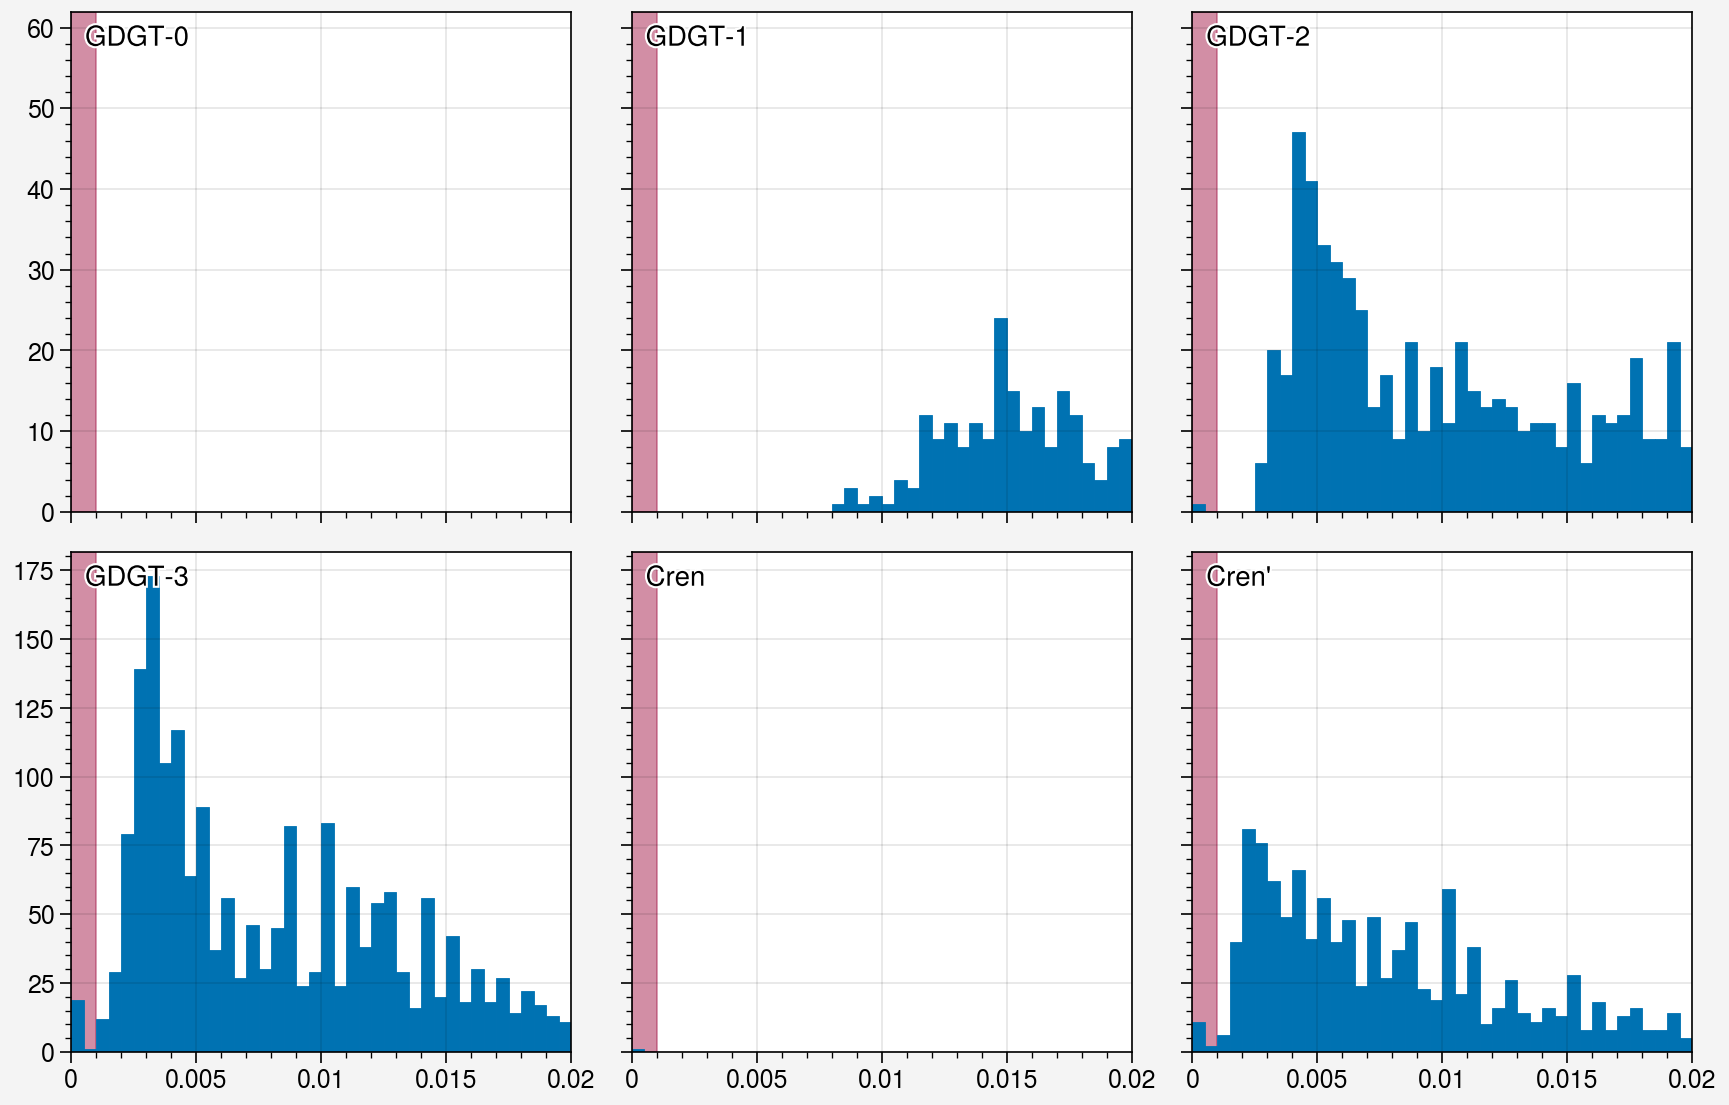

In [42]:
fig, axs = plot.subplots(ncols=3,nrows=2)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
plot_data = coretop_df.dropna(how='any',subset=features)

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    ax.format(ultitle=f'{label}',fontweight='bold')
    XX = plot_data[feature].values
    ax.hist(XX,bins=np.arange(XX.min(),XX.max(),0.0005))
    
axs.format(xlim=(0,0.02))
axs.axvspan(0,0.001, color='pink9', alpha=0.5, edgecolor='none', zorder=0)

plt.show()

## 3.2 Ring Index as a predictand

In [43]:
combined_df_raw['organism_broadClass4'].unique()

array(['Coretop', 'Non-marine Group 1.1a', 'Marine Group 1.1a',
       'Group 1.1b', 'Mesocosm'], dtype=object)

In [44]:
broadClass4_color_dict = {
    'Coretop':'cyan9',
    'Marine Group 1.1a':'eggplant purple',
    'Non-marine Group 1.1a':'yellow9',
    'Group 1.1b':'dark taupe',
    'Mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

In [45]:
combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,ZeroOverZeroCren,CrenOverZeroCren,CrenPrimeOverCren,publicationYear,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,10.87,0.08,...,0.40,0.60,0.06,2025.00,Coretop,False,True,True,True,True
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,9.03,0.08,...,0.33,0.67,0.05,2025.00,Coretop,False,True,True,True,True
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,9.03,0.09,...,0.35,0.65,0.05,2025.00,Coretop,False,True,True,True,True
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,12.16,0.08,...,0.37,0.63,0.07,2025.00,Coretop,False,True,True,True,True
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,12.27,0.05,...,0.42,0.58,0.06,2025.00,Coretop,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,NaN,NaN,...,0.27,0.73,0.02,2007.00,Mesocosm,False,True,True,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,NaN,NaN,...,0.33,0.67,0.07,2007.00,Mesocosm,False,True,True,True,True
2165,NaN,NaN,NaN,NaN,NaN,34.00,34.00,NaN,NaN,NaN,...,0.14,0.86,0.02,2007.00,Mesocosm,False,True,True,True,True
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,NaN,NaN,...,0.06,0.94,0.03,2007.00,Mesocosm,False,True,True,True,True


overall -- fGDGT_0: spearman rho: -0.888, p-value: 0.000e+00, n=2137
  cultures (all) -- fGDGT_0: spearman rho: -0.771, p-value: 1.606e-17, n=83
  Coretop -- fGDGT_0: spearman rho: -0.890, p-value: 0.000e+00, n=2033
  Mesocosm -- fGDGT_0: spearman rho: -0.882, p-value: 1.214e-07, n=21
  Marine Group 1.1a -- fGDGT_0: spearman rho: -0.679, p-value: 1.869e-09, n=61
  Non-marine Group 1.1a -- fGDGT_0: spearman rho: -0.594, p-value: 7.016e-02, n=10
  Group 1.1b -- fGDGT_0: spearman rho: -0.856, p-value: 3.780e-04, n=12
overall -- fGDGT_1: spearman rho: 0.515, p-value: 8.911e-145, n=2137
  cultures (all) -- fGDGT_1: spearman rho: -0.322, p-value: 3.024e-03, n=83
  Coretop -- fGDGT_1: spearman rho: 0.539, p-value: 2.456e-153, n=2033
  Mesocosm -- fGDGT_1: spearman rho: -0.706, p-value: 3.454e-04, n=21
  Marine Group 1.1a -- fGDGT_1: spearman rho: -0.049, p-value: 7.074e-01, n=61
  Non-marine Group 1.1a -- fGDGT_1: spearman rho: -0.582, p-value: 7.783e-02, n=10
  Group 1.1b -- fGDGT_1: spearma

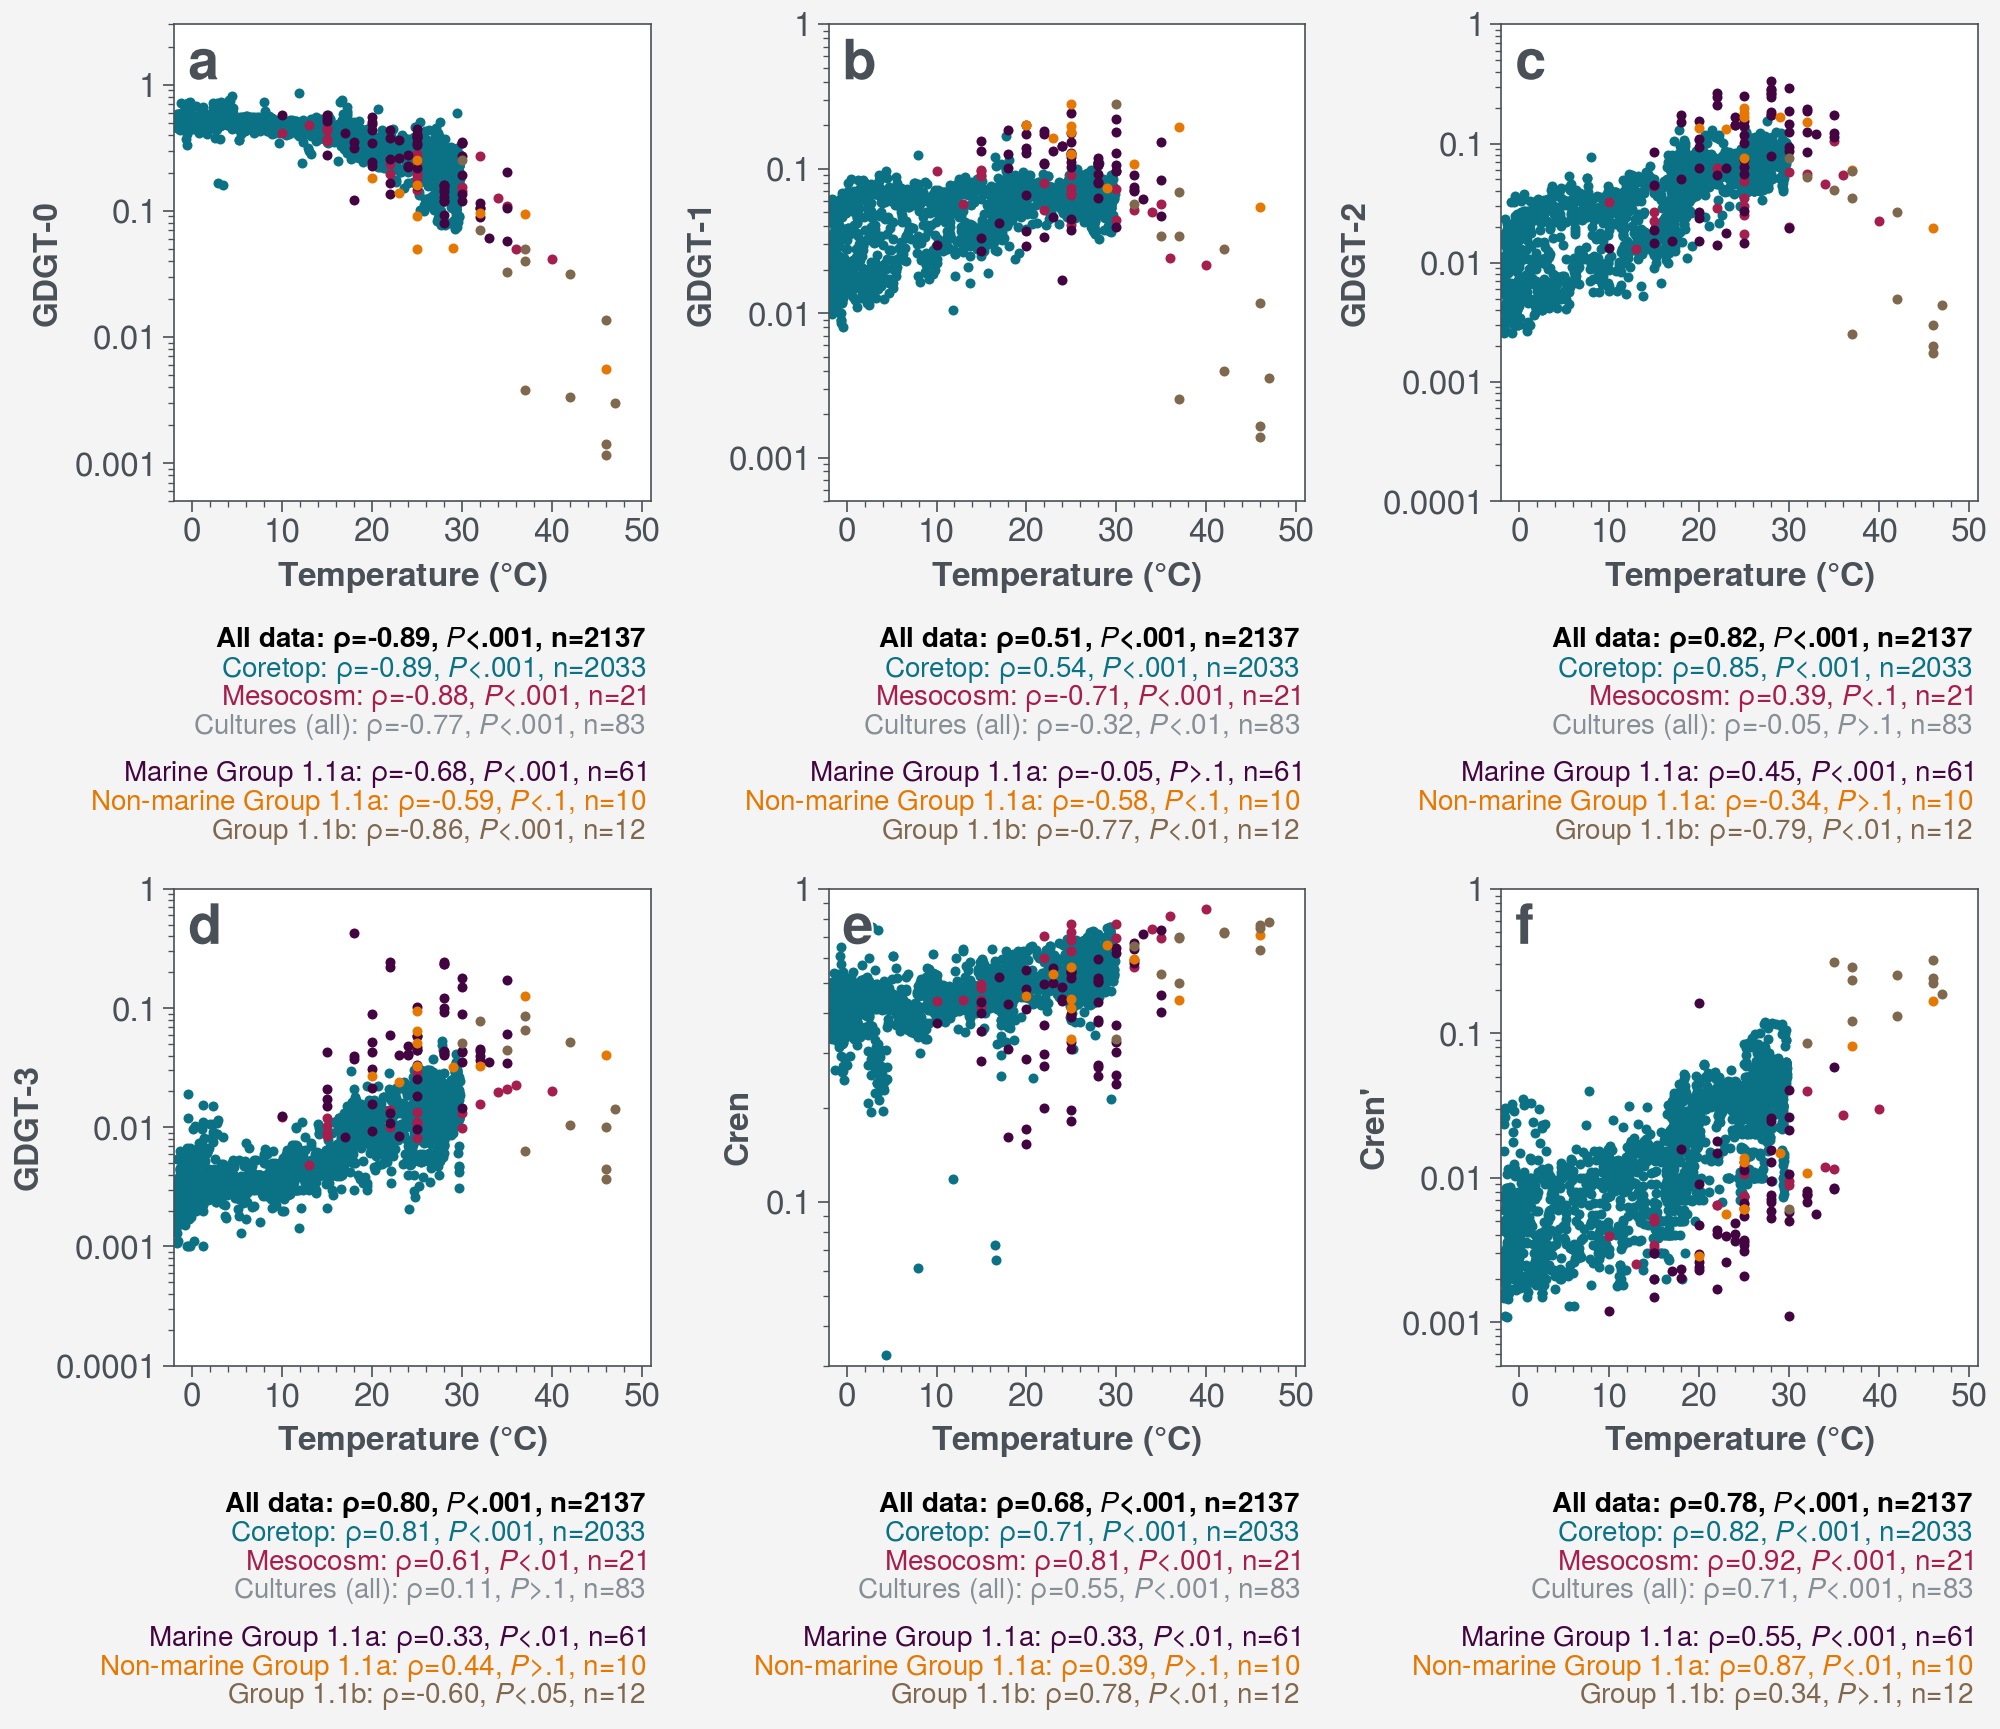

In [46]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
temp_param = 'SST'

fig, axs = plot.subplots(ncols=3, nrows=2, width=10, share=False)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag'] == False]
plot_data = plot_data.sort_values(
    'datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})
).reset_index(drop=True)

ordered_categories = ['Coretop', 'Mesocosm', 'Marine Group 1.1a', 'Non-marine Group 1.1a', 'Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(
    plot_data['organism_broadClass4'], categories=ordered_categories, ordered=True
)
grouped = plot_data.groupby('sorted_datatype')
sel_color_dict = broadClass4_color_dict

# --- y-positions below axes (shared across all panels) ---
# Order: [0]=All data, [1]=Coretop, [2]=Mesocosm, [3]=Cultures(all),
#        [4]=Marine Group 1.1a, [5]=Non-marine Group 1.1a, [6]=Group 1.1b
ypos_below = [-0.06-0.2, -0.12-0.2, -0.18-0.2, -0.24-0.2,
              -0.34-0.2, -0.40-0.2, -0.46-0.2]

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]

    # --- Scatter per group ---
    for name, group in grouped:
        ax.scatter(
            group[temp_param], group[feature],
            label=name, m='.', c=sel_color_dict.get(name, 'gray')
        )

    # --- All data stats ---
    nonnan_idx = (~plot_data[temp_param].isna()) & (~plot_data[feature].isna())
    reg_x = plot_data.loc[nonnan_idx, temp_param]
    reg_y = plot_data.loc[nonnan_idx, feature]
    rho_all, pval_all = spearmanr(reg_x, reg_y)
    n_all = len(reg_y)
    print(f'overall -- {feature}: spearman rho: {rho_all:.3f}, p-value: {pval_all:.3e}, n={n_all}')
    pval_label_all = label_pvalues(pval_all)
    label_text_all = fr'All data: $\rho$={rho_all:.2f}, {pval_label_all}, n={n_all}'
    ax.text(0.99, ypos_below[0], label_text_all,
            transform=ax.transAxes, clip_on=False,
            ha='right', va='top', fontsize=10, fontweight='bold', color='black')

    # --- Cultures (all) stats ---
    cult_data = plot_data[plot_data['datatype'] == 'culture']
    nonnan_cult = (~cult_data[temp_param].isna()) & (~cult_data[feature].isna())
    reg_xc = cult_data.loc[nonnan_cult, temp_param]
    reg_yc = cult_data.loc[nonnan_cult, feature]
    rho_cult, pval_cult = spearmanr(reg_xc, reg_yc)
    n_cult = len(reg_yc)
    print(f'  cultures (all) -- {feature}: spearman rho: {rho_cult:.3f}, p-value: {pval_cult:.3e}, n={n_cult}')
    pval_label_cult = label_pvalues(pval_cult)
    label_text_cult = fr'Cultures (all): $\rho$={rho_cult:.2f}, {pval_label_cult}, n={n_cult}'
    ax.text(0.99, ypos_below[3], label_text_cult,
            transform=ax.transAxes, clip_on=False,
            ha='right', va='top', fontsize=10, color='gray6')

    # --- Per-group stats ---
    for j, (name, group) in enumerate(grouped):
        nonnan_idx = (~group[temp_param].isna()) & (~group[feature].isna())
        reg_x = group.loc[nonnan_idx, temp_param]
        reg_y = group.loc[nonnan_idx, feature]
        rho, pval = spearmanr(reg_x, reg_y)
        n_grp = len(reg_y)
        print(f'  {name} -- {feature}: spearman rho: {rho:.3f}, p-value: {pval:.3e}, n={n_grp}')

        pval_label = label_pvalues(pval)
        label_text = fr'{name}: $\rho$={rho:.2f}, {pval_label}, n={n_grp}'
        ypos_ = ypos_below[j+2] if ('1.1' in str(name)) else ypos_below[j+1]
        ax.text(0.99, ypos_, label_text,
                transform=ax.transAxes, clip_on=False,
                ha='right', va='top', fontsize=10,
                color=sel_color_dict.get(name, 'gray'))

axs.format(
    abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul', abccolor='gray7',
    xlim=(-2, 51),
    grid=False,
    labelsize=12,
    fontsize=12,
    labelweight='bold',
    labelcolor='gray7',
    textcolor='gray7',
    tickcolor='gray7',
    ticklabelcolor='gray7',
    yscale='log'
)

ylims_list   = [(5e-4, 3e0), (5e-4, 1e0), (1e-4, 1e0), (1e-4, 1e0), (3e-2, 1e0), (5e-4, 1e0)]
ylabels_list = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
for ax, ylim, ylabel in zip(axs, ylims_list, ylabels_list):
    ax.set_ylim(ylim)
    ax.set_ylabel(ylabel=ylabel, fontsize=12, fontweight='bold')

for ax in axs:
    ax.spines[:].set_color('gray7')
    ax.format(xlabel=r'Temperature ($\degree$C)')


fpath = fr'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS1_coretop_culture_mesocosm_fractinal_GDGTs_vs_Temp.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

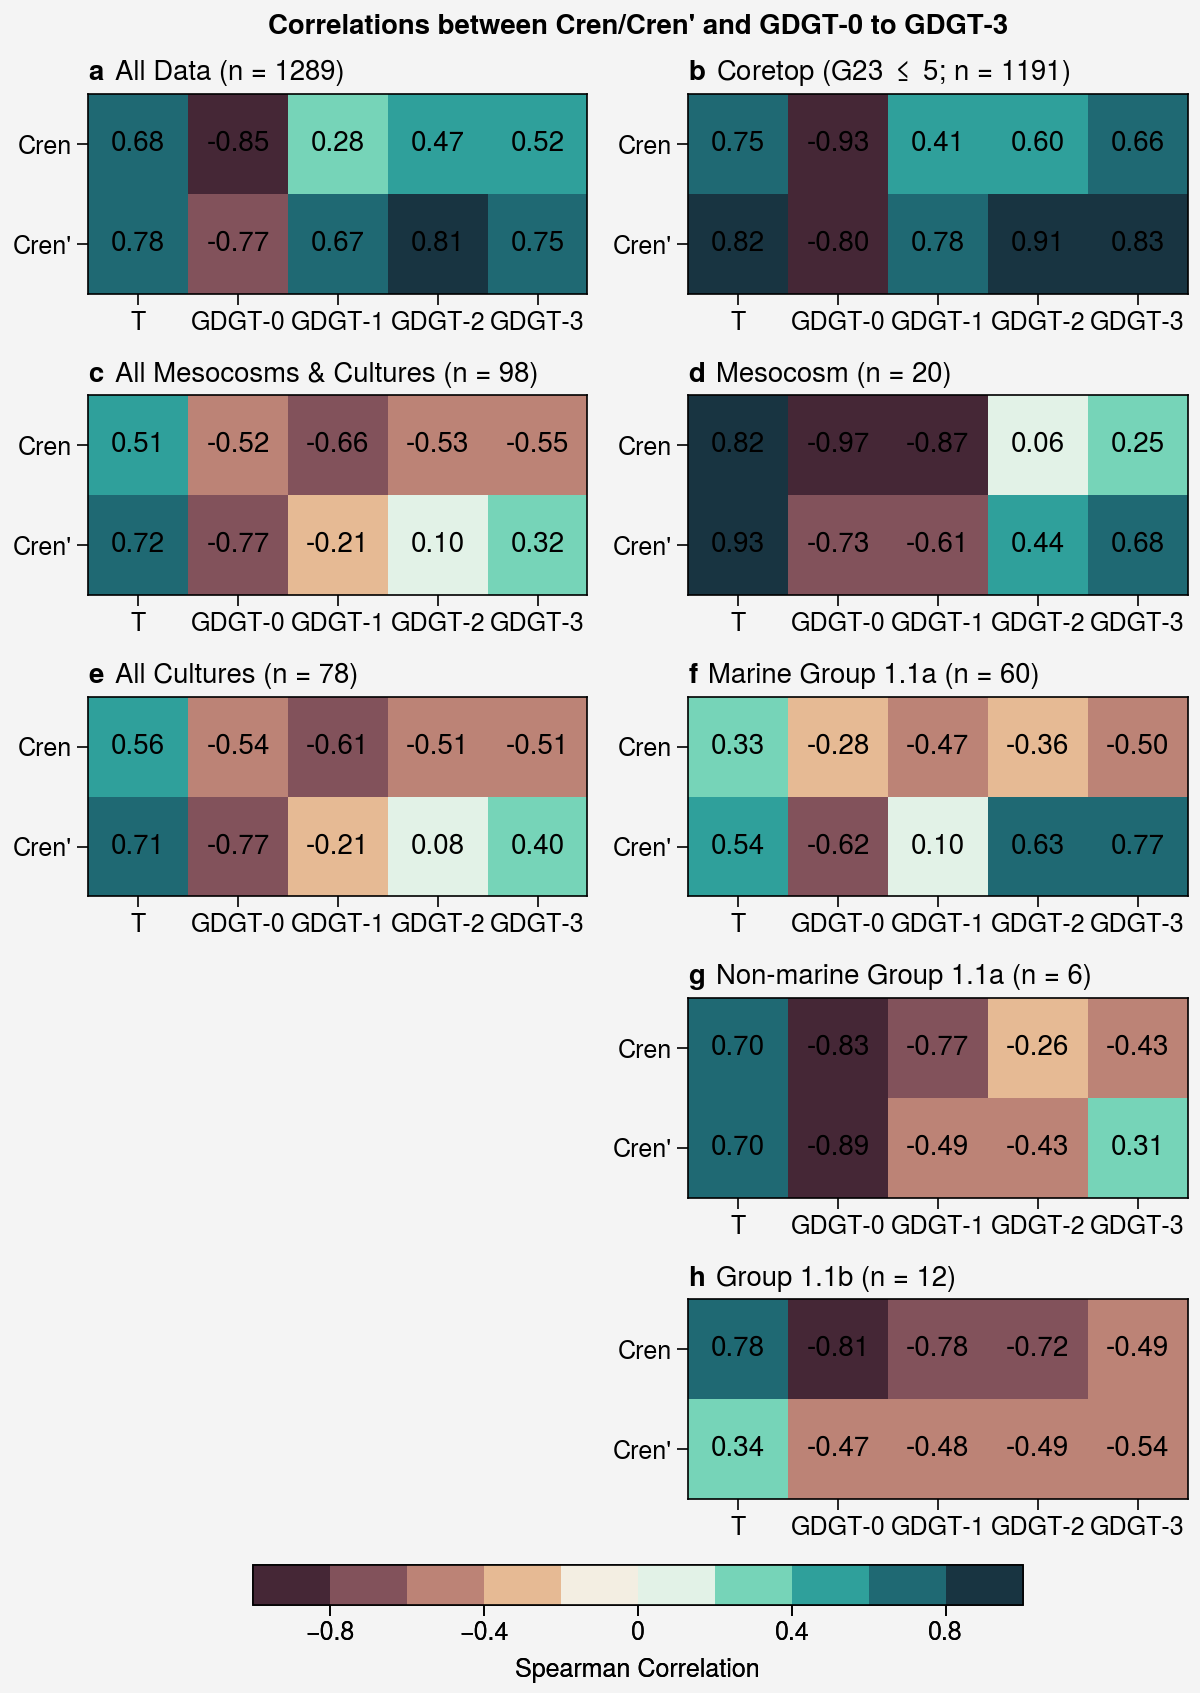

In [47]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren','fGDGT_cren_prime']

plot_data = combined_df_raw[(
    (combined_df_raw['lowAbundanceFlag'] == False)
    # & (combined_df_raw['SST'].between(10,30))
    & (combined_df_raw['gdgt23ratio']<5)
    # & (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False)
    # & (combined_df_raw['datatype']!='coretop')
    )]
plot_data = plot_data.sort_values(
    'datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})
).reset_index(drop=True)

ordered_categories = ['Coretop', 'Mesocosm', 'Marine Group 1.1a', 'Non-marine Group 1.1a', 'Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(
    plot_data['organism_broadClass4'], categories=ordered_categories, ordered=True
)

features = ['SST','fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
target_rows = ['SST','fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3']
ticklabels_dict={
    'SST':'T',
    'fGDGT_0':'GDGT-0',
    'fGDGT_1':'GDGT-1',
    'fGDGT_2':'GDGT-2',
    'fGDGT_3':'GDGT-3',
    'fGDGT_cren':"Cren",
    'fGDGT_cren_prime':"Cren'"
}
target_cols = ['fGDGT_cren', 'fGDGT_cren_prime']

ordered_categories = ['Coretop', 'Mesocosm', 'Marine Group 1.1a', 'Non-marine Group 1.1a', 'Group 1.1b']

groups_dict = {
    'All Data': plot_data,
    'All Mesocosms & Cultures' : plot_data[plot_data['datatype'] != 'coretop'],
    'All Cultures': plot_data[plot_data['datatype'] == 'culture'],
}
for cat in ordered_categories:
    groups_dict[cat] = plot_data[plot_data['organism_broadClass4'] == cat]
    

fig, axes = plot.subplots(
    nrows=5,ncols=2,
    width=6,
    share=False,
)
# --- Fix: reassign numbers to skip the invisible axes ---
# axes layout (1-indexed internally by proplot):
#  [0,0]=1(a)  [0,1]=2(b)
#  [1,0]=3(c)  [1,1]=4(d)
#  [2,0]=5(e)  [2,1]=6(f)
#  [3,0]=7     [3,1]=8(h) ← should be 7(g)
#  [4,0]=9     [4,1]=10(j) ← should be 8(h)

axes[3, 1].number = 7   # reassign: 'h' → 'g'
axes[4, 1].number = 8   # reassign: 'j' → 'h'

# Keep abc suppressed only on the invisible axes (already in your code)
axes[3:, 0].format(abc=False)
axes[3:, 0].set_visible(False)
axes.format(abc=True)

axes_dict = {
    'All Data': axes[0,0],
    'All Mesocosms & Cultures': axes[1,0],
    'All Cultures': axes[2,0]
}

ii=0
for i, (label, group_data) in enumerate(groups_dict.items()):
    ax = axes_dict.get(label,axes[ii,1])
    if label in ordered_categories:
        ii += 1 
    cat_corr = (
        group_data[features]
        .corr(method='spearman')[target_cols].T[target_rows]
    )

    n_rows, n_cols = cat_corr.shape

    m = ax.pcolormesh(
        cat_corr.values,
        cmap='DryWet',
        vmin=-1, vmax=1,
    )

    for r in range(n_rows):
        for c in range(n_cols):
            val = cat_corr.values[r, c]
            if not np.isnan(val):
                ax.text(
                    c, r, f'{val:.2f}',
                    ha='center', va='center',
                    fontsize=10, color='k',
                    transform=ax.transData
                )

    ax.format(
        ltitle=label+f' (n = {len(group_data)})' if label!='Coretop' else label+r' (G23 $\leq$ 5;'+f' n = {len(group_data)})',
        xlabel='', ylabel='',
        yreverse=True,
        xtickminor=False, ytickminor=False,
        xticks=np.arange(0, n_cols, 1),
        yticks=np.arange(0, n_rows, 1),
        xticklabels=[ticklabels_dict.get(r, r) for r in target_rows],
        yticklabels=[ticklabels_dict.get(c, c) for c in target_cols],
        grid=False,
        aspect='equal'
    )

fig.colorbar(m, label='Spearman Correlation', shrink=0.7, loc='b')
fig.format(suptitle="Correlations between Cren/Cren' and GDGT-0 to GDGT-3")
fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS2_cren_crenprime_correlations'
fig.savefig(os.path.join(fpath,fname+'.pdf'),dpi=300,tight_layout=True)

Coretop
 full -- name: Coretop, TEX86 vs SST: spearman rho: 0.871, p-value: 0.000e+00
 full -- name: Coretop, RI vs SST: spearman rho: 0.860, p-value: 0.000e+00
Mesocosm
 full -- name: Mesocosm, TEX86 vs SST: spearman rho: 0.890, p-value: 6.825e-08
 full -- name: Mesocosm, RI vs SST: spearman rho: 0.876, p-value: 1.891e-07
Marine Group 1.1a
 full -- name: Marine Group 1.1a, TEX86 vs SST: spearman rho: 0.463, p-value: 1.741e-04
 full -- name: Marine Group 1.1a, RI vs SST: spearman rho: 0.651, p-value: 1.333e-08
Non-marine Group 1.1a
 full -- name: Non-marine Group 1.1a, TEX86 vs SST: spearman rho: 0.732, p-value: 1.618e-02
 full -- name: Non-marine Group 1.1a, RI vs SST: spearman rho: 0.757, p-value: 1.131e-02
Group 1.1b
 full -- name: Group 1.1b, TEX86 vs SST: spearman rho: 0.725, p-value: 7.662e-03
 full -- name: Group 1.1b, RI vs SST: spearman rho: 0.789, p-value: 2.296e-03
overall TEX86 vs SST: spearman rho: 0.857, p-value: 0.000e+00
overall RI vs SST: spearman rho: 0.855, p-value: 

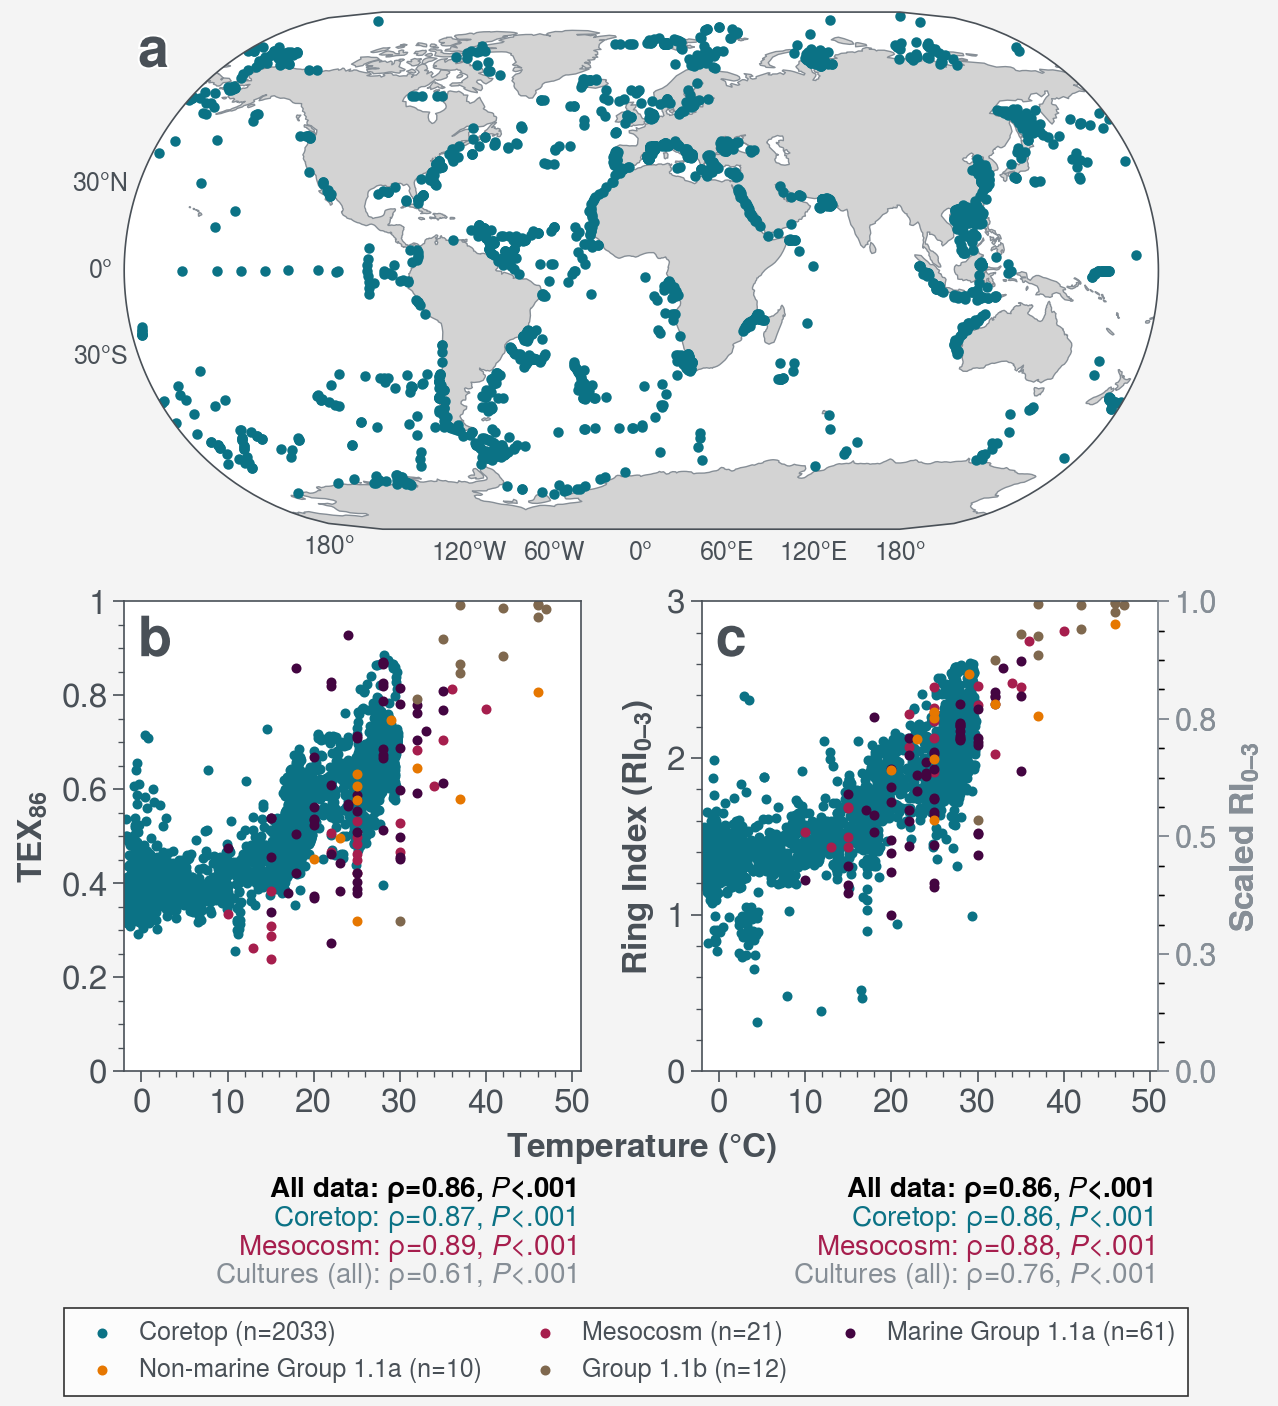

In [48]:
array = [
    [1,1],
    [2,3]
]
fig, axs = plot.subplots(array, width=7, sharey=0, proj={1:'eck3'},
                         hratios=[1.1,1])

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)

ax = axs[0,0]
ax.format(land=True, landcolor='lightgray', landzorder=0,
          coast=True, coastcolor='gray6', coastzorder=1, coastlinewidth=0.5,
          latlabels=True, lonlabels=True,
          gridlabelsize='large')

plot_lat = plot_data[plot_data['datatype']=='coretop']['Latitude']
plot_lon = plot_data[plot_data['datatype']=='coretop']['Longitude']
sc = ax.scatter(plot_lon, plot_lat, c=datatype_color_dict.get('coretop','gray'),
                s=10, marker='o', label='coretop', zorder=2)

ordered_categories = ['Coretop','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['organism_broadClass4'],
                                              categories=ordered_categories,
                                              ordered=True)
grouped = plot_data.groupby('sorted_datatype')
sel_color_dict = broadClass4_color_dict

# --- y-positions below axes (negative = below subplot) ---
# Order: All data, Coretop, Mesocosm, Cultures (all), MG1.1a, NMG1.1a, G1.1b
ypos_below = [-0.06-0.16, -0.12-0.16, -0.18-0.16, -0.24-0.16, 
              -0.32-0.16, -0.38-0.16, -0.44-0.16]
# extra gap before 1.1 subgroups (indices 4,5,6) accounts for longer labels

for i, (name, group) in enumerate(grouped):
    print(name)
    plot_x  = group['SST']
    plot_y  = group['TEX86']
    plot_y2 = group['ringIndex_cren3']

    axs[1,0].scatter(plot_x, plot_y,  label=name+f" (n={len(plot_y)})", m='.', c=sel_color_dict.get(name,'gray'))
    axs[1,1].scatter(plot_x, plot_y2, label=name+f" (n={len(plot_y)})", m='.', c=sel_color_dict.get(name,'gray'))

    # TEX86 stats
    nonnan_idx = (~plot_x.isna()) & (~plot_y.isna())
    reg_x, reg_y = plot_x[nonnan_idx], plot_y[nonnan_idx]
    rho, pval = spearmanr(reg_x, reg_y)
    print(f' full -- name: {name}, TEX86 vs SST: spearman rho: {rho:.3f}, p-value: {pval:.3e}')

    # RI stats
    nonnan_idx2 = (~plot_x.isna()) & (~plot_y2.isna())
    reg_x2, reg_y2 = plot_x[nonnan_idx2], plot_y2[nonnan_idx2]
    rho2, pval2 = spearmanr(reg_x2, reg_y2)
    print(f' full -- name: {name}, RI vs SST: spearman rho: {rho2:.3f}, p-value: {pval2:.3e}')

    pval_label  = label_pvalues(pval)
    pval_label2 = label_pvalues(pval2)
    
    label_text  = fr'{name}: $\rho$={rho:.2f}, {pval_label}'
    label_text2 = fr'{name}: $\rho$={rho2:.2f}, {pval_label2}'

    ypos_ = ypos_below[i+2] if ('1.1' in name) else ypos_below[i+1]
    
    if '1.1' in name:
        continue
    else:
        axs[1,0].text(0.99, ypos_, label_text,
                    transform=axs[1,0].transAxes, clip_on=False,
                    ha='right', va='top', fontsize=10,
                    color=sel_color_dict.get(name,'gray'))
        axs[1,1].text(0.99, ypos_, label_text2,
                    transform=axs[1,1].transAxes, clip_on=False,
                    ha='right', va='top', fontsize=10,
                    color=sel_color_dict.get(name,'gray'))

# --- All data stats ---
reg_XX  = plot_data['SST']
reg_YY  = plot_data['TEX86']
nonnan_idx = (~reg_XX.isna()) & (~reg_YY.isna())
reg_X, reg_Y = reg_XX[nonnan_idx].values.reshape(-1,1), reg_YY[nonnan_idx].values
rho_all, pval_all = spearmanr(reg_X, reg_Y)
print(f'overall TEX86 vs SST: spearman rho: {rho_all:.3f}, p-value: {pval_all:.3e}')
pval_label_all = label_pvalues(pval_all)
label_text_all = fr'All data: $\rho$={rho_all:.2f}, {pval_label_all}'
axs[1,0].text(0.99, ypos_below[0], label_text_all,
              transform=axs[1,0].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, fontweight='bold', color='black')

reg_XX2 = plot_data['SST']
reg_YY2 = plot_data['ringIndex_cren3']
nonnan_idx2 = (~reg_XX2.isna()) & (~reg_YY2.isna())
reg_X2, reg_Y2 = reg_XX2[nonnan_idx2].values.reshape(-1,1), reg_YY2[nonnan_idx2].values
rho_all2, pval_all2 = spearmanr(reg_X2, reg_Y2)
print(f'overall RI vs SST: spearman rho: {rho_all2:.3f}, p-value: {pval_all2:.3e}')
pval_label_all2 = label_pvalues(pval_all2)
label_text_all2 = fr'All data: $\rho$={rho_all2:.2f}, {pval_label_all2}'
axs[1,1].text(0.99, ypos_below[0], label_text_all2,
              transform=axs[1,1].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, fontweight='bold', color='black')

# --- Cultures (all) stats --- placed between Mesocosm and subgroups (index 3)
reg_XX  = plot_data[plot_data['datatype']=='culture']['SST']
reg_YY  = plot_data[plot_data['datatype']=='culture']['TEX86']
nonnan_idx = (~reg_XX.isna()) & (~reg_YY.isna())
reg_X, reg_Y = reg_XX[nonnan_idx].values.reshape(-1,1), reg_YY[nonnan_idx].values
rho_all, pval_all = spearmanr(reg_X, reg_Y)
pval_label_all = label_pvalues(pval_all)
label_text_all = fr'Cultures (all): $\rho$={rho_all:.2f}, {pval_label_all}'
axs[1,0].text(0.99, ypos_below[3], label_text_all,
              transform=axs[1,0].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, color='gray6')

reg_XX2 = plot_data[plot_data['datatype']=='culture']['SST']
reg_YY2 = plot_data[plot_data['datatype']=='culture']['ringIndex_cren3']
nonnan_idx2 = (~reg_XX2.isna()) & (~reg_YY2.isna())
reg_X2, reg_Y2 = reg_XX2[nonnan_idx2].values.reshape(-1,1), reg_YY2[nonnan_idx2].values
rho_all2, pval_all2 = spearmanr(reg_X2, reg_Y2)
pval_label_all2 = label_pvalues(pval_all2)
label_text_all2 = fr'Cultures (all): $\rho$={rho_all2:.2f}, {pval_label_all2}'
axs[1,1].text(0.99, ypos_below[3], label_text_all2,
              transform=axs[1,1].transAxes, clip_on=False,
              ha='right', va='top', fontsize=10, color='gray6')

# # --- Reference lines ---
# axs[1,0].plot([0.2,0.98], [-0.46,-0.46], transform=axs[1,0].transAxes, c='gray9', lw=0.5, clip_on=False)
# axs[1,1].plot([0.2,0.98], [-0.46,-0.46], transform=axs[1,1].transAxes, c='gray9', lw=0.5, clip_on=False)

# --- Axis formatting ---
axs[1:,0].format(ylim=(0,1), yticks=np.arange(0,1.2,0.2), ylabel=r'TEX$_{86}$')
axs[1:,1].format(ylim=(0,3), yticks=np.arange(0,3.1,1),   ylabel=u'Ring Index (RI$_{0\u20133}$)')

ax_right = axs[1,1].twinx()
ax_right.set_ylim(axs[1,1].get_ylim())
yticks = np.linspace(0, 3.1, 5)
ax_right.set_yticks(yticks)
ax_right.set_yticklabels([f'{(tick/3):.1f}' for tick in yticks], fontsize=11)
ax_right.set_ylabel(u'Scaled RI$_{0\u20133}$', fontsize=12, fontweight='bold')
ax_right.yaxis.label.set_color('gray6')
ax_right.tick_params(axis='y', colors='gray6')
ax_right.spines['right'].set_edgecolor('gray6')

axs.format(
    labelsize=12, fontsize=12, labelweight='bold',
    xlim=(-2, 51),   # <-- updated
    grid=False,
    xlabel=r'Temperature ($\degree$C)',
    abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul',
    abccolor='gray7', labelcolor='gray7', textcolor='gray7',
    tickcolor='gray7', ticklabelcolor='gray7',
)

h, l = axs[1,-1].get_legend_handles_labels()
legend = axs[1].legend(h, l, loc='b', ncol=3,
              bbox_to_anchor=(1.1, 1), 
              borderaxespad=0.,
              frameon=True,
            #   title='Data legend',
              fontsize=12, fontcolor='gray7')
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('gray7')

for ax in axs:
    ax.spines[:].set_color('gray7')

# Add bottom margin so clipped text is visible
fig.subplots_adjust(bottom=0.18)

fpath = fr'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig3_coretop_TEX86_SST_RI_scatter'
fig.savefig(os.path.join(fpath, fname+'.pdf'), dpi=300, bbox_inches='tight')


--- Sensitivity analysis: RI0-3 combined advantage ---
index_key            RI0-3  RI0-4  RI0-5  combined_advantage
range   t_min t_max                                         
15–40°C 15    40      0.72   1.01   1.16                0.73
15–30°C 15    30      0.92   1.20   1.34                0.70
10–40°C 10    40      0.73   1.00   1.15                0.68
15–35°C 15    35      0.70   0.96   1.09                0.65
10–35°C 10    35      0.72   0.96   1.08                0.60
10–30°C 10    30      0.83   1.06   1.18                0.59

✓ Auto-selected range: 15–40°C  (combined_advantage=0.733)


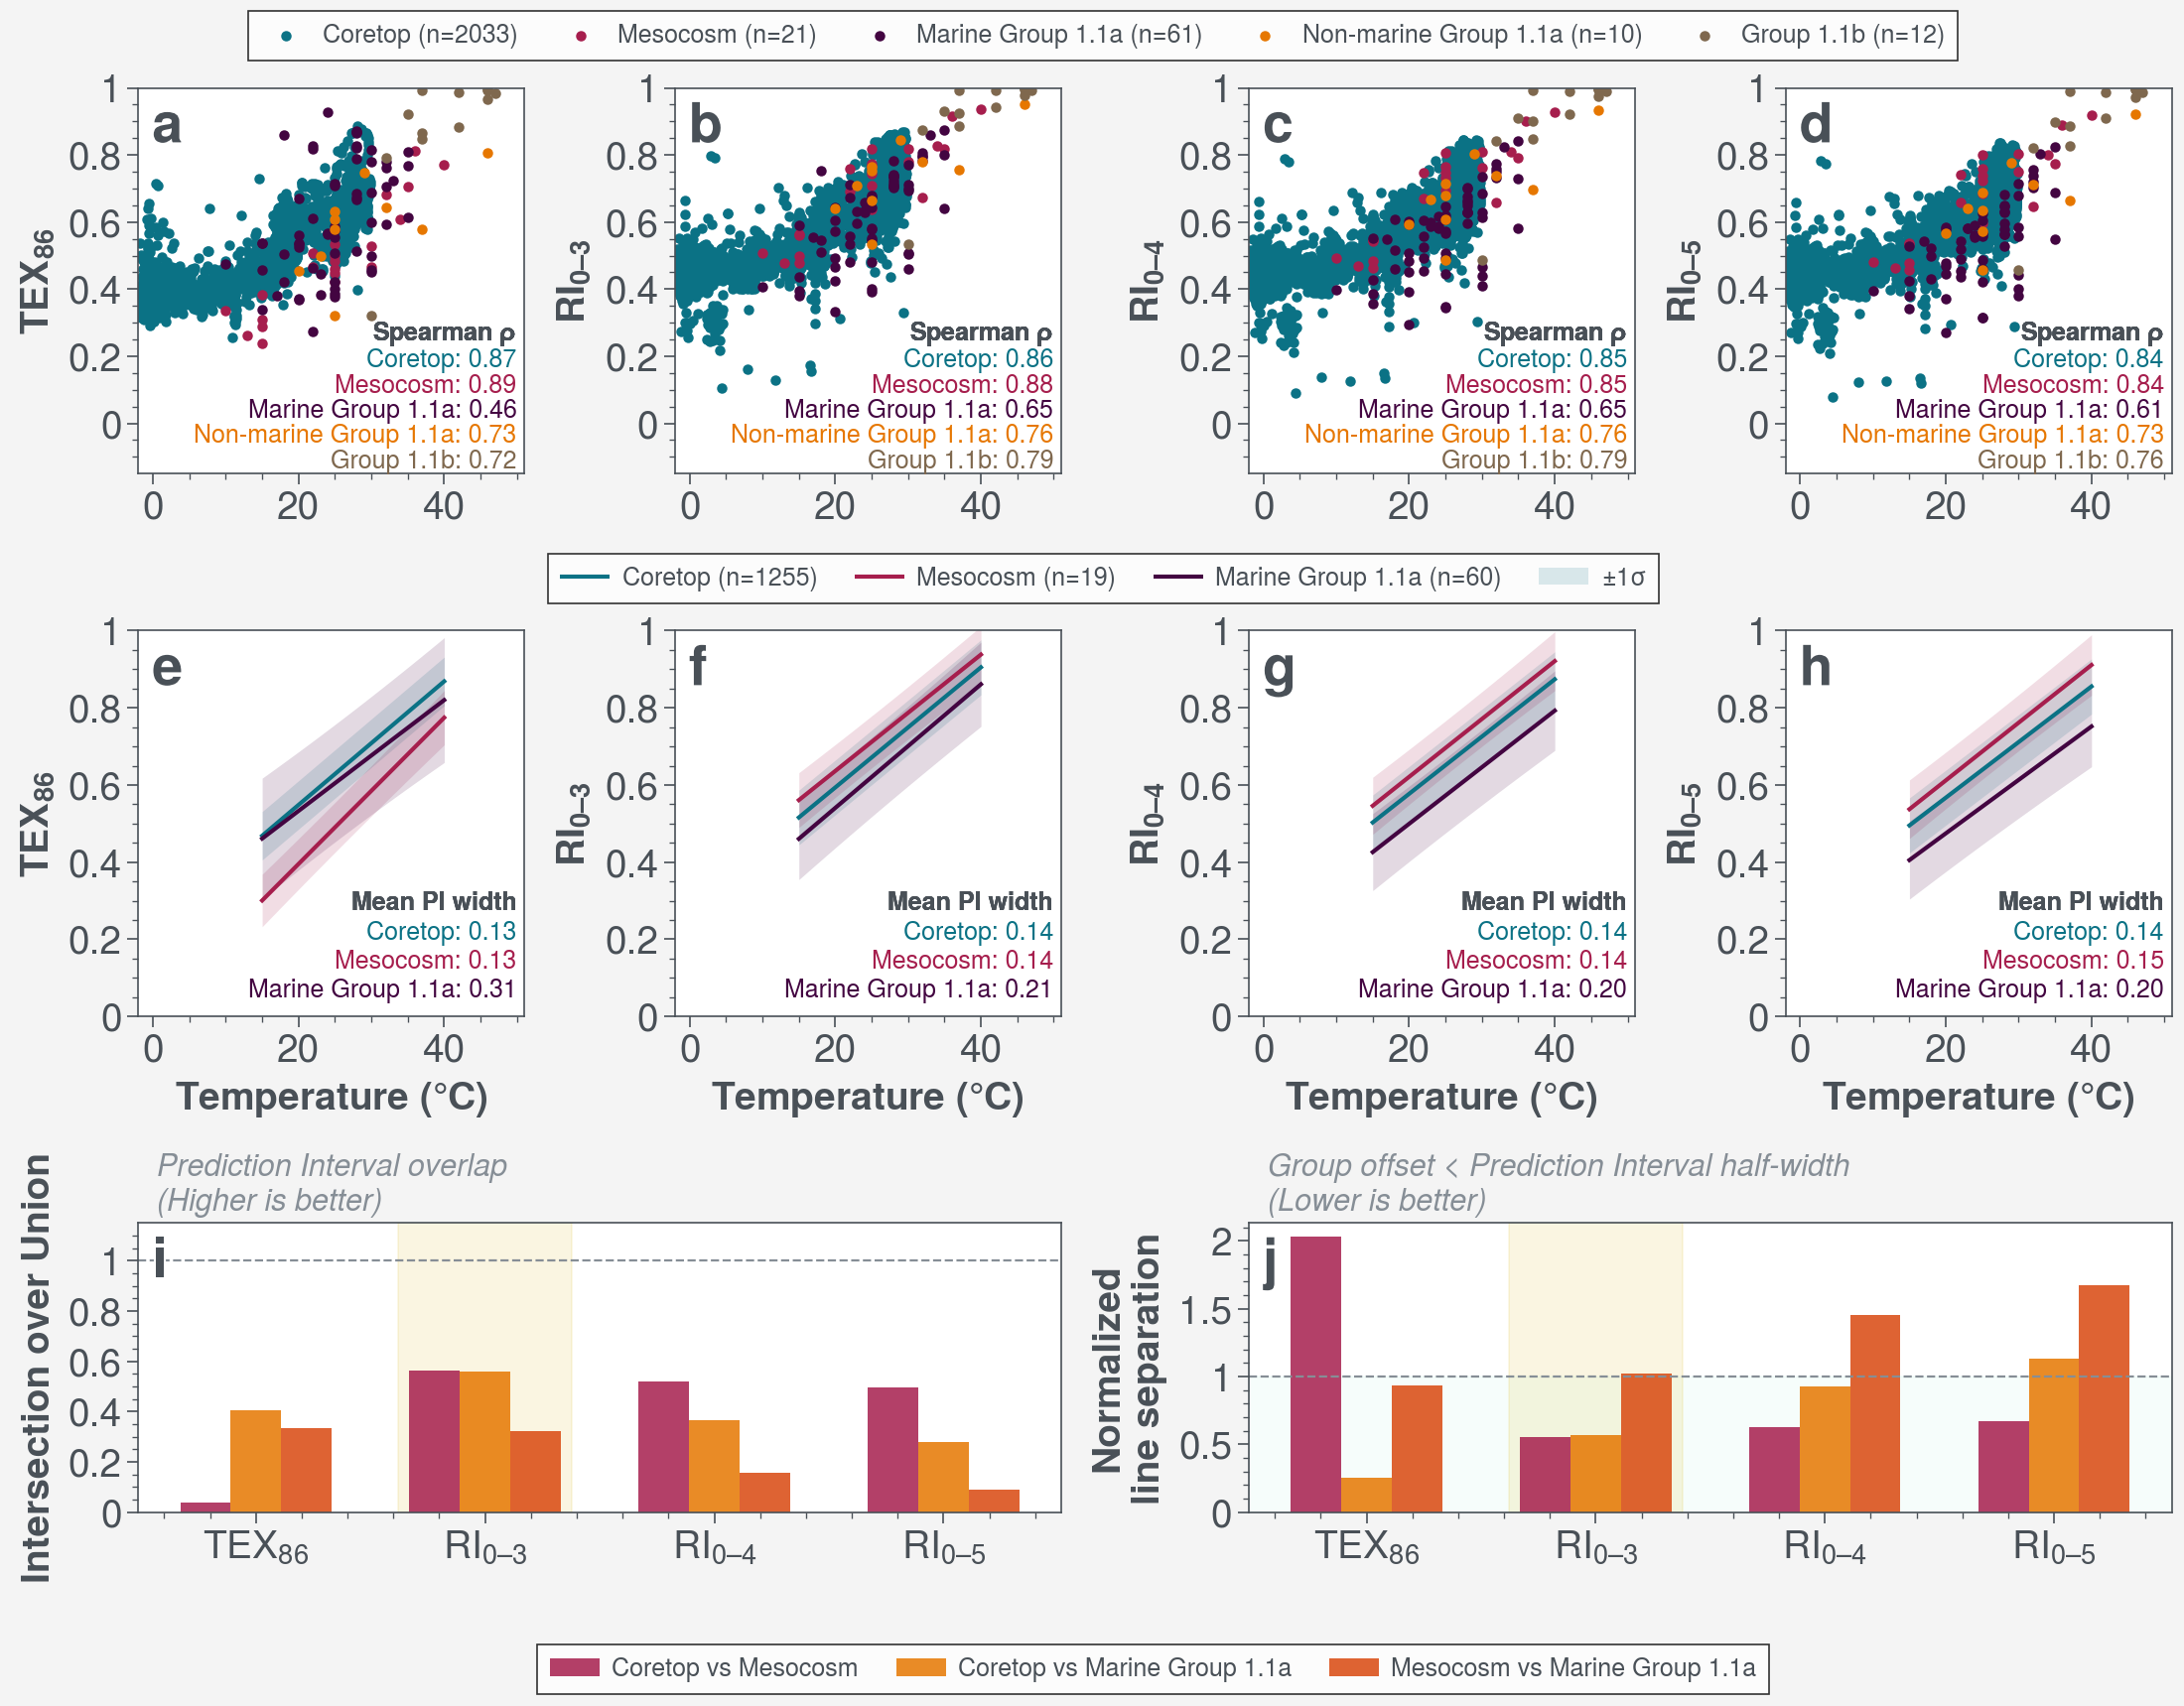

In [49]:
from scipy import stats
from itertools import combinations, product

# ============================================================
# CONFIG  (ranges to test; everything else stays fixed)
# ============================================================
T_MIN_CANDIDATES = [10, 15]
T_MAX_CANDIDATES = [30, 35, 40]

yparams        = ['TEX86', 'scaledRI_cren3', 'scaledRI', 'scaledRI_cren5']
yparams_labels = [r'TEX$_{86}$', u'RI$_{0\u20133}$', u'RI$_{0\u20134}$', u'RI$_{0\u20135}$']
yparams_short  = ['TEX86', 'RI0-3', 'RI0-4', 'RI0-5']

ordered_categories = ['Coretop', 'Mesocosm', 'Marine Group 1.1a',
                      'Non-marine Group 1.1a', 'Group 1.1b']
ypos_below = [-0.22, -0.28, -0.34, -0.40, -0.48, -0.54, -0.60]
KEY_PAIRS  = ['Coretop vs Mesocosm', 'Coretop vs Marine Group 1.1a','Mesocosm vs Marine Group 1.1a',]
PAIR_MAP = {
    'Coretop vs Mesocosm':           ('Coretop',  'Mesocosm'),
    'Coretop vs Marine Group 1.1a':  ('Coretop',  'Marine Group 1.1a'),
    'Mesocosm vs Marine Group 1.1a': ('Mesocosm', 'Marine Group 1.1a'),
}

# ============================================================
# HELPERS
# ============================================================
def prep_data(t_min, t_max):
    df = (
        combined_df_raw
        .loc[combined_df_raw['lowAbundanceFlag'] == False]
        .loc[combined_df_raw['SST'].between(t_min, t_max)]
        .sort_values('datatype',
                     key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2}))
        .reset_index(drop=True)
    )
    df['sorted_datatype'] = pd.Categorical(
        df['organism_broadClass4'],
        categories=ordered_categories, ordered=True
    )
    return df


def fit_and_predict(reg_x, reg_y, xx):
    model     = LinearRegression().fit(reg_x.reshape(-1, 1), reg_y)
    n         = len(reg_x)
    yy        = model.predict(xx.reshape(-1, 1))
    residuals = reg_y - model.predict(reg_x.reshape(-1, 1))
    mse       = np.sum(residuals ** 2) / (n - 2)
    x_mean    = reg_x.mean()
    Sxx       = np.sum((reg_x - x_mean) ** 2)
    se_pred   = np.sqrt(mse * (1 + 1 / n + (xx - x_mean) ** 2 / Sxx))
    t_lo      = stats.t.ppf(0.16, df=n - 2)
    t_hi      = stats.t.ppf(0.84, df=n - 2)
    rmse      = np.sqrt(np.mean(residuals ** 2))
    return model, yy, yy + t_lo * se_pred, yy + t_hi * se_pred, rmse


def collect_fits(grouped, xx):
    """Return fits[index_short][group] = (yy, pi_lo, pi_hi)."""
    fits = {}
    for jj, yparam in enumerate(yparams):
        fits[yparams_short[jj]] = {}
        for name, group in grouped:
            nonnan = (~group['SST'].isna()) & (~group[yparam].isna())
            rx = group.loc[nonnan, 'SST'].values
            ry = group.loc[nonnan, yparam].values
            if len(rx) <= 10:
                continue
            _, yy, pi_lo, pi_hi, _ = fit_and_predict(rx, ry, xx)
            fits[yparams_short[jj]][name] = (yy, pi_lo, pi_hi)
    return fits


def pi_iou(lo1, hi1, lo2, hi2):
    intersection = np.maximum(0, np.minimum(hi1, hi2) - np.maximum(lo1, lo2))
    union        = np.maximum(hi1, hi2) - np.minimum(lo1, lo2)
    return float(np.mean(intersection / np.where(union > 0, union, np.nan)))


def norm_separation(yy1, yy2, lo1, hi1, lo2, hi2):
    line_gap = np.abs(yy1 - yy2)
    avg_hw   = ((hi1 - lo1) + (hi2 - lo2)) / 4
    return float(np.mean(line_gap / np.where(avg_hw > 0, avg_hw, np.nan)))


def build_overlap_df(fits):
    records = []
    for jj, ykey in enumerate(yparams_short):
        gf = fits[ykey]
        for (g1, (yy1, lo1, hi1)), (g2, (yy2, lo2, hi2)) in combinations(gf.items(), 2):
            records.append({
                'index':     yparams_labels[jj],
                'index_key': ykey,
                'g1': g1, 'g2': g2,
                'pair':      f'{g1}\nvs\n{g2}',
                'iou':       pi_iou(lo1, hi1, lo2, hi2),
                'norm_sep':  norm_separation(yy1, yy2, lo1, hi1, lo2, hi2),
            })
    return pd.DataFrame(records)


# ============================================================
# BLOCK 1 — sensitivity scan → auto-select t_min, t_max
# ============================================================
sens_records = []

for t_min_s, t_max_s in product(T_MIN_CANDIDATES, T_MAX_CANDIDATES):
    xx_s       = np.linspace(t_min_s, t_max_s, 50)
    grouped_s  = prep_data(t_min_s, t_max_s).groupby('sorted_datatype')
    fits_s     = collect_fits(grouped_s, xx_s)

    for jj, ykey in enumerate(yparams_short):
        gf = fits_s[ykey]
        for pair_label in KEY_PAIRS:
            g1, g2 = PAIR_MAP[pair_label]
            if g1 not in gf or g2 not in gf:
                continue
            yy1, lo1, hi1 = gf[g1]
            yy2, lo2, hi2 = gf[g2]
            sens_records.append({
                'range':     f'{t_min_s}–{t_max_s}°C',
                't_min':     t_min_s,
                't_max':     t_max_s,
                'index_key': ykey,
                'pair':      pair_label,
                'iou':       pi_iou(lo1, hi1, lo2, hi2),
                'norm_sep':  norm_separation(yy1, yy2, lo1, hi1, lo2, hi2),
            })

df_sens = pd.DataFrame(sens_records)

# rank by RI0-3 combined advantage over RI0-4 and RI0-5
pivot = df_sens.groupby(['range', 't_min', 't_max', 'index_key'])['norm_sep'].mean().unstack('index_key')
pivot['combined_advantage'] = (pivot['RI0-4'] - pivot['RI0-3']) + (pivot['RI0-5'] - pivot['RI0-3'])
pivot = pivot.sort_values('combined_advantage', ascending=False)

print("\n--- Sensitivity analysis: RI0-3 combined advantage ---")
print(pivot[['RI0-3','RI0-4','RI0-5','combined_advantage']].round(3).to_string())

# --- AUTO-SELECT ---
best_row     = pivot.index[0]                      # (range_str, t_min, t_max)
t_min, t_max = int(best_row[1]), int(best_row[2])
xx           = np.linspace(t_min, t_max, 50)

print(f"\n✓ Auto-selected range: {t_min}–{t_max}°C  "
      f"(combined_advantage={pivot.loc[best_row,'combined_advantage']:.3f})")


# ============================================================
# BLOCK 2 — final data prep + fits at optimal range
# ============================================================
plot_data = prep_data(t_min, t_max)
plot_data_full = prep_data(-2,50)
grouped = plot_data.groupby('sorted_datatype')
grouped_full = plot_data_full.groupby('sorted_datatype')
sel_color_dict = broadClass4_color_dict

fits       = collect_fits(grouped, xx)
df_overlap = build_overlap_df(fits)


array = [
    [1, 2, 3, 4],    # row 1 (NEW): raw scatter
    [5, 6, 7, 8],    # row 2: regression + PI lines
    [9, 9, 10, 10],  # row 3: bar charts
]

fig, axs = plot.subplots(
    array,
    width=11,
    share=0,
    hratios=[1, 1, 0.75],   # scatter taller, lines equal, bars shorter
)

# ============================================================
# ROW 1 — raw scatter (axs[0]–axs[3])
# ============================================================
for jj, yparam in enumerate(yparams):
    ax = axs[jj]

    for i, (name_full, group_full) in enumerate(grouped_full):
        nonnan       = (~group_full['SST'].isna()) & (~group_full[yparam].isna())
        plot_x       = group_full.loc[nonnan, 'SST'].values
        plot_y       = group_full.loc[nonnan, yparam].values
        if len(plot_x) == 0:
            continue
        color = sel_color_dict.get(name_full, 'gray5')
        ax.scatter(plot_x, plot_y,
                   c=color, s=10,
                   label=name_full+f' (n={len(plot_x)})' if jj == 0 else '_nolegend_')
        
        ## reg data
        nonnan_idx = ~(np.isnan(plot_x)) & ~(np.isnan(plot_y))
        rho, pval = spearmanr(plot_x[nonnan_idx],plot_y[nonnan_idx])
        ax.text(0.98,0.4,r'Spearman $\rho$',weight='bold',c='gray7',
                transform=ax.transAxes,
                ha='right',va='top',fontsize=9)
        ax.text(0.98,0.325-(0.065*i),f'{name_full}: {rho:.2f}',color=color,
                transform=ax.transAxes,
                ha='right',va='top',fontsize=9)

    ax.format(
        ylabel=yparams_labels[jj],
        xlim=(-2, 51), grid=False,
        ylim=(-0.15,1),
        yticks=np.arange(0,1.1,0.2),
        xlabel='',
    )
    ax.spines[:].set_color('gray7')
h0, l0 = axs[0].get_legend_handles_labels()
axs[0].legend(h0, l0, loc='t', ncols=5,
              bbox_to_anchor=[2.5, 0],
              fontsize=10, fontcolor='gray7', frameon=True)
# ============================================================
# ROW 2 — regression + PI lines (axs[4]–axs[7])
# ============================================================
for jj, yparam in enumerate(yparams):
    ax = axs[jj + 4]   # offset by 4

    for i, (name, group) in enumerate(grouped):
        nonnan       = (~group['SST'].isna()) & (~group[yparam].isna())
        reg_x, reg_y = group.loc[nonnan, 'SST'].values, group.loc[nonnan, yparam].values
        if len(reg_x) <= 10:
            continue

        model, yy, pi_lo, pi_hi, rmse = fit_and_predict(reg_x, reg_y, xx)
        color = sel_color_dict.get(name, 'gray5')
        ax.plot(xx, yy, c=color, lw=1.5,
                label=name+f' (n={len(reg_x)})' if jj == 0 else '_nolegend_')
        ax.fill_between(xx, pi_lo, pi_hi, color=color, alpha=0.15, linewidth=0,
                        label=r'$\pm$1$\sigma$' if (jj == 0 and i == 0) else '_nolegend_')
        
        pi_width_mean = np.mean(pi_hi - pi_lo)
        ax.text(0.98,0.325,'Mean PI width',weight='bold',c='gray7',
                transform=ax.transAxes,
                ha='right',va='top',fontsize=9)
        ax.text(0.98,0.25-(0.075*i),f'{name}: {pi_width_mean:.2f}',color=color,
                transform=ax.transAxes,
                ha='right',va='top',fontsize=9)

    ax.format(
        ylabel=yparams_labels[jj],
        xlim=(-2, 51), ylim=(0, 1), grid=False,
        xlabel=r'Temperature ($\degree$C)',
    )
    ax.spines[:].set_color('gray7')

# --- shared legend between rows 1 and 2, centred above bar charts ---
h, l = axs[4].get_legend_handles_labels()
axs[4].legend(h, l, loc='t', ncols=5,
              bbox_to_anchor=[2.5, 0],
              fontsize=10, fontcolor='gray7', frameon=True)

# ============================================================
# ROW 3 — convergence bar charts (axs[8] = panel 9, axs[9] = panel 10)
# ============================================================
ax_iou = axs[8]
ax_sep = axs[9]

key_pairs = sorted(
    [p for p in df_overlap['pair'].unique()
     if p.replace('\nvs\n', ' vs ') in KEY_PAIRS],
    key=lambda p: KEY_PAIRS.index(p.replace('\nvs\n', ' vs '))
)

n_pairs   = len(key_pairs)
x_pos     = np.arange(len(yparams_labels))
bar_width = 0.22
offsets   = np.linspace(-(n_pairs - 1) / 2, (n_pairs - 1) / 2, n_pairs) * bar_width

pair_style = {
    'Coretop vs Mesocosm':           {'color': 'pink9'},
    'Coretop vs Marine Group 1.1a':  {'color': 'yellow9'},
    'Mesocosm vs Marine Group 1.1a': {'color': 'orange9'},
}

for k, pair in enumerate(key_pairs):
    sub        = df_overlap[df_overlap['pair'] == pair]
    pair_label = pair.replace('\nvs\n', ' vs ')
    color      = pair_style.get(pair_label, {'color': 'gray5'})['color']

    iou_vals = [sub.loc[sub['index'] == idx, 'iou'].values[0]
                if len(sub.loc[sub['index'] == idx]) > 0 else np.nan
                for idx in yparams_labels]
    sep_vals = [sub.loc[sub['index'] == idx, 'norm_sep'].values[0]
                if len(sub.loc[sub['index'] == idx]) > 0 else np.nan
                for idx in yparams_labels]

    ax_iou.bar(x_pos + offsets[k], iou_vals, width=bar_width,
               color=color, alpha=0.85, label=pair_label)
    ax_sep.bar(x_pos + offsets[k], sep_vals, width=bar_width,
               color=color, alpha=0.85, label=pair_label)

ax_iou.axhline(1.0, color='gray6', lw=0.8, ls='--')
ax_iou.text(0.02, 1.02, 'Prediction Interval overlap\n(Higher is better)',
            transform=ax_iou.transAxes, fontsize=11,
            color='gray6', va='bottom', ha='left', style='italic')

ax_sep.axhline(1.0, color='gray6', lw=0.8, ls='--')
ax_sep.text(0.02, 1.02, 'Group offset < Prediction Interval half-width\n(Lower is better)',
            transform=ax_sep.transAxes, fontsize=11,
            color='gray6', va='bottom', ha='left', style='italic')
ax_sep.axhspan(0, 1.0, color='teal2', alpha=0.08, zorder=0)

for ax in [ax_iou, ax_sep]:
    ax.axvspan(x_pos[1] - 0.38, x_pos[1] + 0.38,
               color='gold', alpha=0.12, zorder=0, label='_nolegend_')
    ax.spines[:].set_color('gray7')

ax_iou.format(
    ylabel='Intersection over Union',
    xticks=x_pos, xticklabels=yparams_labels,
    ylim=(0, 1.15), yticks=[0, 0.2, 0.4, 0.6, 0.8, 1.0], grid=False,
)
ax_sep.format(
    ylabel='Normalized\nline separation',
    xticks=x_pos, xticklabels=yparams_labels,
    ylim=(0, None), grid=False,
)
ax_iou.legend(loc='b', ncol=3,
              bbox_to_anchor=[1.1, -0.25],
              fontsize=10, fontcolor='gray7', frameon=True)

# ============================================================
# GLOBAL FORMATTING
# ============================================================
axs.format(
    labelsize=14, fontsize=14, labelweight='bold',
    abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul',
    abccolor='gray7', labelcolor='gray7', textcolor='gray7',
    tickcolor='gray7', ticklabelcolor='gray7',
)

fpath = fr'{local_github_path}/figures/manuscript/finalized/supplementary'
fig.savefig(os.path.join(fpath, f'figS3_combined_{t_min}-{t_max}C_predictionInterval_comparison.pdf'),
            dpi=300, bbox_inches='tight')

## 3.3 Data screening: traditional vs data driven approach

### 3.3.1 prefiltering combined coretop_df

In [50]:
coretop_idx = combined_df_raw[combined_df_raw['datatype']=='coretop'].index

QC_indices_dict = {
    'BIT':0.5,
    'methaneIndex':0.5,
    'ZeroOverZeroCren':0.67
    }

new_cols = ['BIT_flag','methaneIndex_flag','ZeroOverZeroCren_flag']
for col, threshold in QC_indices_dict.items():
    flag_col = f'{col}_flag'
    combined_df_raw[flag_col] = 'included'
    combined_df_raw.loc[coretop_idx, flag_col] = ['excluded' if row >= threshold else 'included' for row in combined_df_raw.loc[coretop_idx, col]]
    
    
combined_df_raw['QCflag_indices'] = 'included'
for idx in coretop_idx:
    row = combined_df_raw.loc[idx]
    if 'excluded' in [row[col] for col in new_cols]:
        combined_df_raw.at[idx, 'QCflag_indices'] = 'excluded'
combined_df_raw[combined_df_raw['QCflag_indices']=='excluded']


,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna,BIT_flag,methaneIndex_flag,ZeroOverZeroCren_flag,QCflag_indices
44,-22.22,-176.61,-22.12,-176.62,1744.00,24.49,25.21,0.00,0.18,0.05,...,Coretop,False,False,False,False,False,excluded,included,included,excluded
83,-44.15,-75.15,-44.12,-75.12,301.00,11.49,11.83,7.15,11.82,0.07,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
664,38.19,176.70,38.12,176.62,4522.00,15.92,16.48,2.78,3.66,0.03,...,Coretop,False,False,False,False,False,included,excluded,excluded,excluded
665,37.77,176.27,37.88,176.38,3573.00,16.18,16.76,2.68,2.72,0.03,...,Coretop,True,False,False,False,False,included,excluded,excluded,excluded
669,38.89,157.63,38.88,157.62,5535.00,16.14,16.63,2.50,4.72,0.04,...,Coretop,False,False,False,False,False,included,excluded,excluded,excluded
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017,72.75,-67.02,72.62,-67.12,2373.00,-0.38,0.09,3.06,2.39,0.05,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
2018,71.41,-70.89,71.38,-70.88,702.00,0.54,1.15,2.97,1.56,0.06,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
2019,69.60,-65.40,69.62,-65.38,267.00,-0.63,-0.63,3.11,3.87,0.04,...,Coretop,False,False,False,False,False,included,included,excluded,excluded
2020,69.41,-64.40,69.38,-64.38,1054.00,-0.53,-0.51,3.00,3.03,0.04,...,Coretop,False,False,False,False,False,included,included,excluded,excluded


### 3.3.2 Traditional screening indices

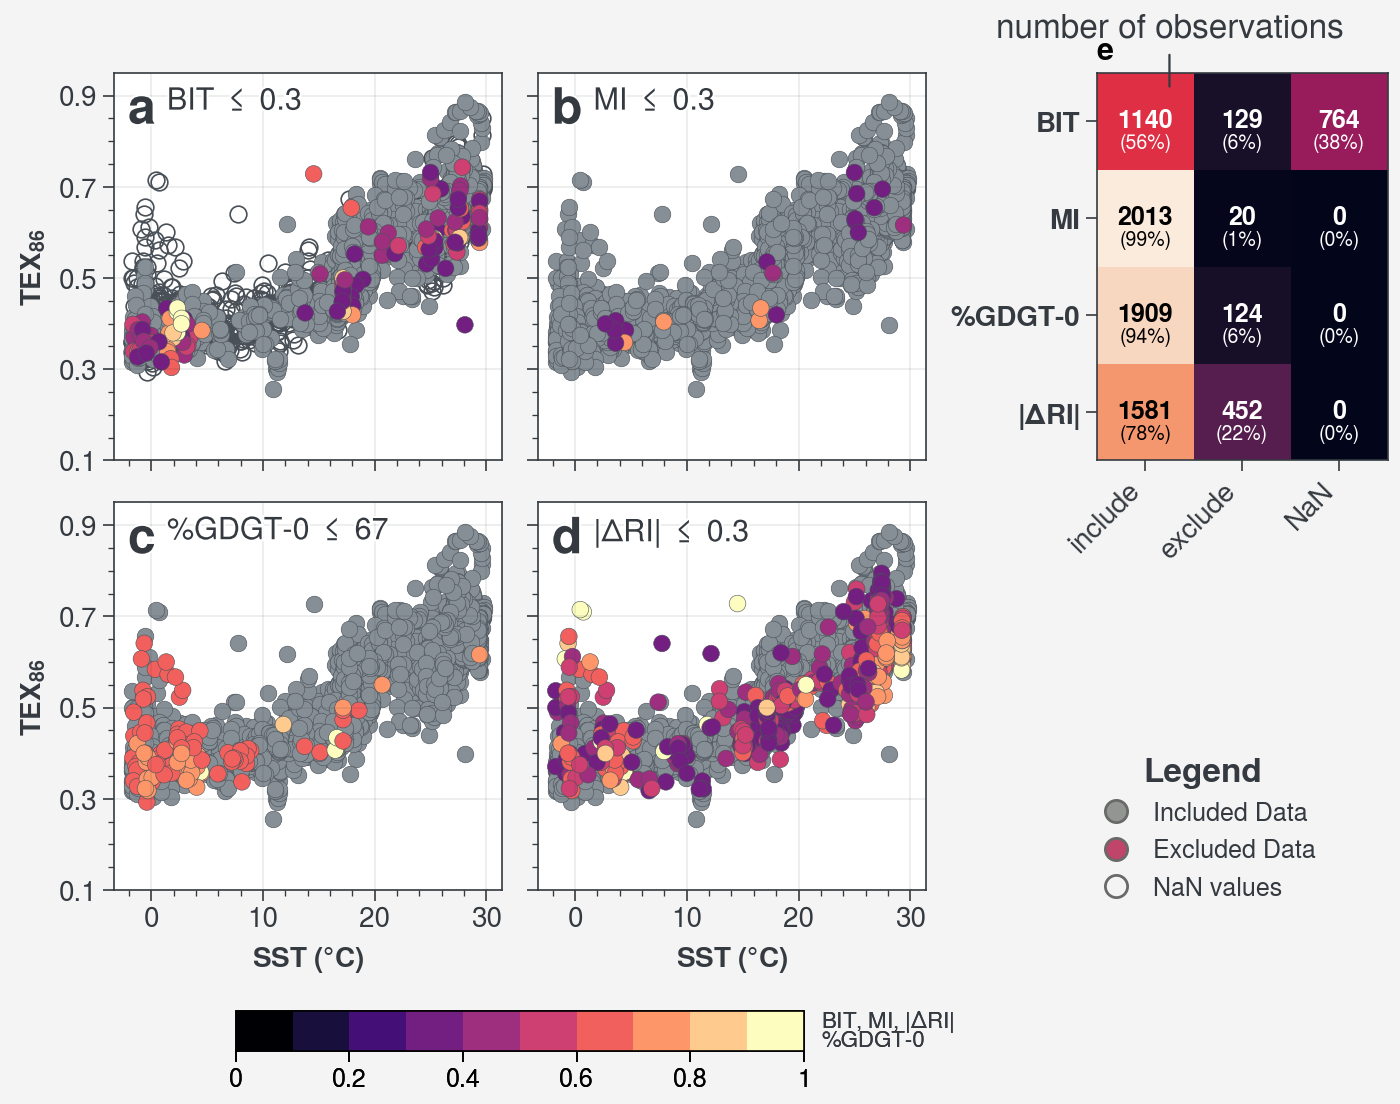

In [51]:
# ── Layout ────────────────────────────────────────────────────────────────────
array = [[1, 2, 5],
         [3, 4, 0]]

fig, axs = plot.subplots(array, width=7,
                         wratios=[1, 1, 0.75],
                         share=0)

# ── Data & QC config ──────────────────────────────────────────────────────────
plot_data = (combined_df_raw
             .loc[combined_df_raw['datatype'] == 'coretop']
             .loc[combined_df_raw['lowAbundanceFlag'] == False])

QC_indices    = ['BIT', 'methaneIndex', 'ZeroOverZeroCren', 'abs_deltaRI']
QC_thresholds = [0.3,    0.3,            0.6,                0.3]
panel_titles  = [r'BIT $\leq$ 0.3',
                 r'MI $\leq$ 0.3',
                 r'%GDGT-0 $\leq$ 67',
                 r'|$\Delta$RI| $\leq$ 0.3']
heatmap_ylabels = ['BIT', 'MI', '%GDGT-0', r'|$\Delta$RI|']

arrays = np.zeros((4, 3))

# ── Scatter panels (a–d) ──────────────────────────────────────────────────────
plot_x = plot_data['SST']
plot_y = plot_data['TEX86']

for i, (QC_index, qc_thr, title) in enumerate(
        zip(QC_indices, QC_thresholds, panel_titles)):

    # Boolean masks
    good_idx = plot_data[QC_index] <= qc_thr
    bad_idx  = plot_data[QC_index] >  qc_thr
    nan_idx  = plot_data[QC_index].isna()

    # Count table
    arrays[i] = [good_idx.sum(), bad_idx.sum(), nan_idx.sum()]

    ax = axs[i]

    # NaN → open circles
    ax.scatter(plot_x[nan_idx], plot_y[nan_idx],
               facecolor='none', m='o', mec='gray7', zorder=0)
    # Included → grey
    ax.scatter(plot_x[good_idx], plot_y[good_idx],
               m='o', c='gray6', mec='gray7', mew=0.2)
    # Excluded → coloured by QC value
    m = ax.scatter(plot_x[bad_idx], plot_y[bad_idx],
                   m='o', c=plot_data[QC_index][bad_idx],
                   levels=np.arange(0, 1.1, 0.1),
                   mec='gray7', mew=0.2, cmap='magma')

    ax.format(title=title,
              titleloc='ul',
              titlesize=10,
              titlecolor='gray8',
              titleweight='normal')

# ── Colorbar with right-side index labels ─────────────────────────────────────
cbar = fig.colorbar(m, loc='b', col=[1, 2], shrink=0.7,
                    label='')   # suppress default label

# Add two-line label to the right of colorbar
cbar.ax.text(1.03, 0.75, r'BIT, MI, |$\Delta$RI|',
             transform=cbar.ax.transAxes,
             fontsize=8, va='center', color='gray8', ha='left')
cbar.ax.text(1.03, 0.25, r'%GDGT-0',
             transform=cbar.ax.transAxes,
             fontsize=8, va='center', color='gray8', ha='left')

# ── Legend: manually placed in lower-right empty slot ─────────────────────────
import matplotlib.lines as mlines

included_h = mlines.Line2D([], [], marker='o', linewidth=0,
                            markerfacecolor='gray',    markeredgecolor='dimgray',
                            markersize=8, label='Included Data')
excluded_h = mlines.Line2D([], [], marker='o', linewidth=0,
                            markerfacecolor='#c0456a', markeredgecolor='dimgray',
                            markersize=8, label='Excluded Data')
nan_h      = mlines.Line2D([], [], marker='o', linewidth=0,
                            markerfacecolor='none',    markeredgecolor='dimgray',
                            markersize=8, label='NaN values')

# Add an invisible axes in the lower-right region (tweak coords to taste)
# [left, bottom, width, height] in figure coordinates
leg_ax = fig.add_axes([0.70, 0.15, 0.28, 0.35])
leg_ax.set_axis_off()

leg = leg_ax.legend(handles=[included_h, excluded_h, nan_h],
                    ncols=1,
                    loc='upper left',
                    bbox_to_anchor=(0.25, 0.5),
                    frameon=False,
                    fontsize=12,
                    title='Legend',
                    title_fontsize=12,
                    labelcolor='gray8')
leg.get_title().set_color('gray8')
leg.get_title().set_fontweight('bold')

# ── "number of observations" annotation on heatmap ────────────────────────────
axs[0, -1].annotate('number of observations',
                     xy=(0.25, -0.3),           # arrow tip — top-center of heatmap
                     xytext=(0.25, -0.8),       # text position above
                     xycoords='data',
                     fontsize=12,
                     color='gray8',
                     ha='center',va='bottom',
                     arrowprops=dict(arrowstyle='-', color='gray8', lw=0.8))

# ── Heatmap panel (e) ─────────────────────────────────────────────────────────
row_totals  = arrays.sum(axis=1, keepdims=True)
pct         = arrays / row_totals * 100

# Build string labels as a plain Python list (avoids numpy truth-value error)
label_list = [
    [f"{int(arrays[i, j])}\n({pct[i, j]:.0f}%)" for j in range(3)]
    for i in range(4)
]

coretop_qc_df = pd.DataFrame(arrays,
                              index=pd.Index(heatmap_ylabels))

axs[0, -1].heatmap(coretop_qc_df,
                   cmap='rocket',
                   label=False
                   )

# Manually annotate each cell
hax = axs[0, -1]
for i in range(4):
    for j in range(3):
        count = int(arrays[i, j])
        p     = pct[i, j]
        # pick white text for dark cells, dark for light cells
        txt_color = 'white' if (arrays[i, j] / arrays.max()) < 0.6 else 'k'

        # Count number — bold, larger
        hax.text(j, i, f"{count}",
                 ha='center', va='center',
                 transform=hax.transData,
                 fontsize=9, fontweight='bold',
                 color=txt_color,
                 transform_rotates_text=False)

        # Percentage — smaller, slightly below
        hax.text(j, i + 0.22, f"({p:.0f}%)",
                 ha='center', va='center',
                 transform=hax.transData,
                 fontsize=7, fontweight='normal',
                 color=txt_color)

axs[0, -1].format(yreverse=True,
                  xticklabels=['include', 'exclude', 'NaN'],
                  xrotation=45,
                  yticklabelweight='bold')

# ── Shared axis formatting ────────────────────────────────────────────────────
axs.format(gridcolor='gray8')

axs[:, :-1].format(xlabel=r'SST ($\degree$C)',
                   ylabel=r'TEX$_{86}$',
                   yticks=np.arange(0.1, 0.95, 0.2),
                   ylim=(0.1, 0.95))

# Right scatter column: suppress redundant ylabel/yticklabels
axs[:, 1].format(ylabel='', yticklabels=[])

# Top scatter row: suppress redundant xlabel/xticklabels
axs[0, :-1].format(xlabel='', xticklabels=[])

# Tick / label colours
for ax in axs:
    ax.format(tickcolor='gray8',
              ticklabelcolor='gray8',
              labelcolor='gray8',
              labelweight='bold',
              labelsize=10,
              fontsize=10)
    for spine in ax.spines.values():
        spine.set_color('gray8')

plot.rc['abc'] = False
# abc labels on scatter panels only
axs[:-1].format(abc=True, abcloc='ul',
                abcsize=18, abccolor='gray8')



# ── Save ──────────────────────────────────────────────────────────────────────
fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS4_Traditional_QC_indices.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300)

Median methaneIndex by organism_broadClass4:
organism_broadClass4
Coretop                 0.18
Group 1.1b              0.07
Marine Group 1.1a       0.39
Mesocosm                0.16
Non-marine Group 1.1a   0.40
Name: methaneIndex, dtype: float64
Median ZeroOverZeroCren by organism_broadClass4:
organism_broadClass4
Coretop                 0.43
Group 1.1b              0.03
Marine Group 1.1a       0.36
Mesocosm                0.23
Non-marine Group 1.1a   0.16
Name: ZeroOverZeroCren, dtype: float64
Median deltaRI by organism_broadClass4:
organism_broadClass4
Coretop                 -0.07
Group 1.1b               0.05
Marine Group 1.1a        0.19
Mesocosm                -0.62
Non-marine Group 1.1a   -0.44
Name: deltaRI, dtype: float64


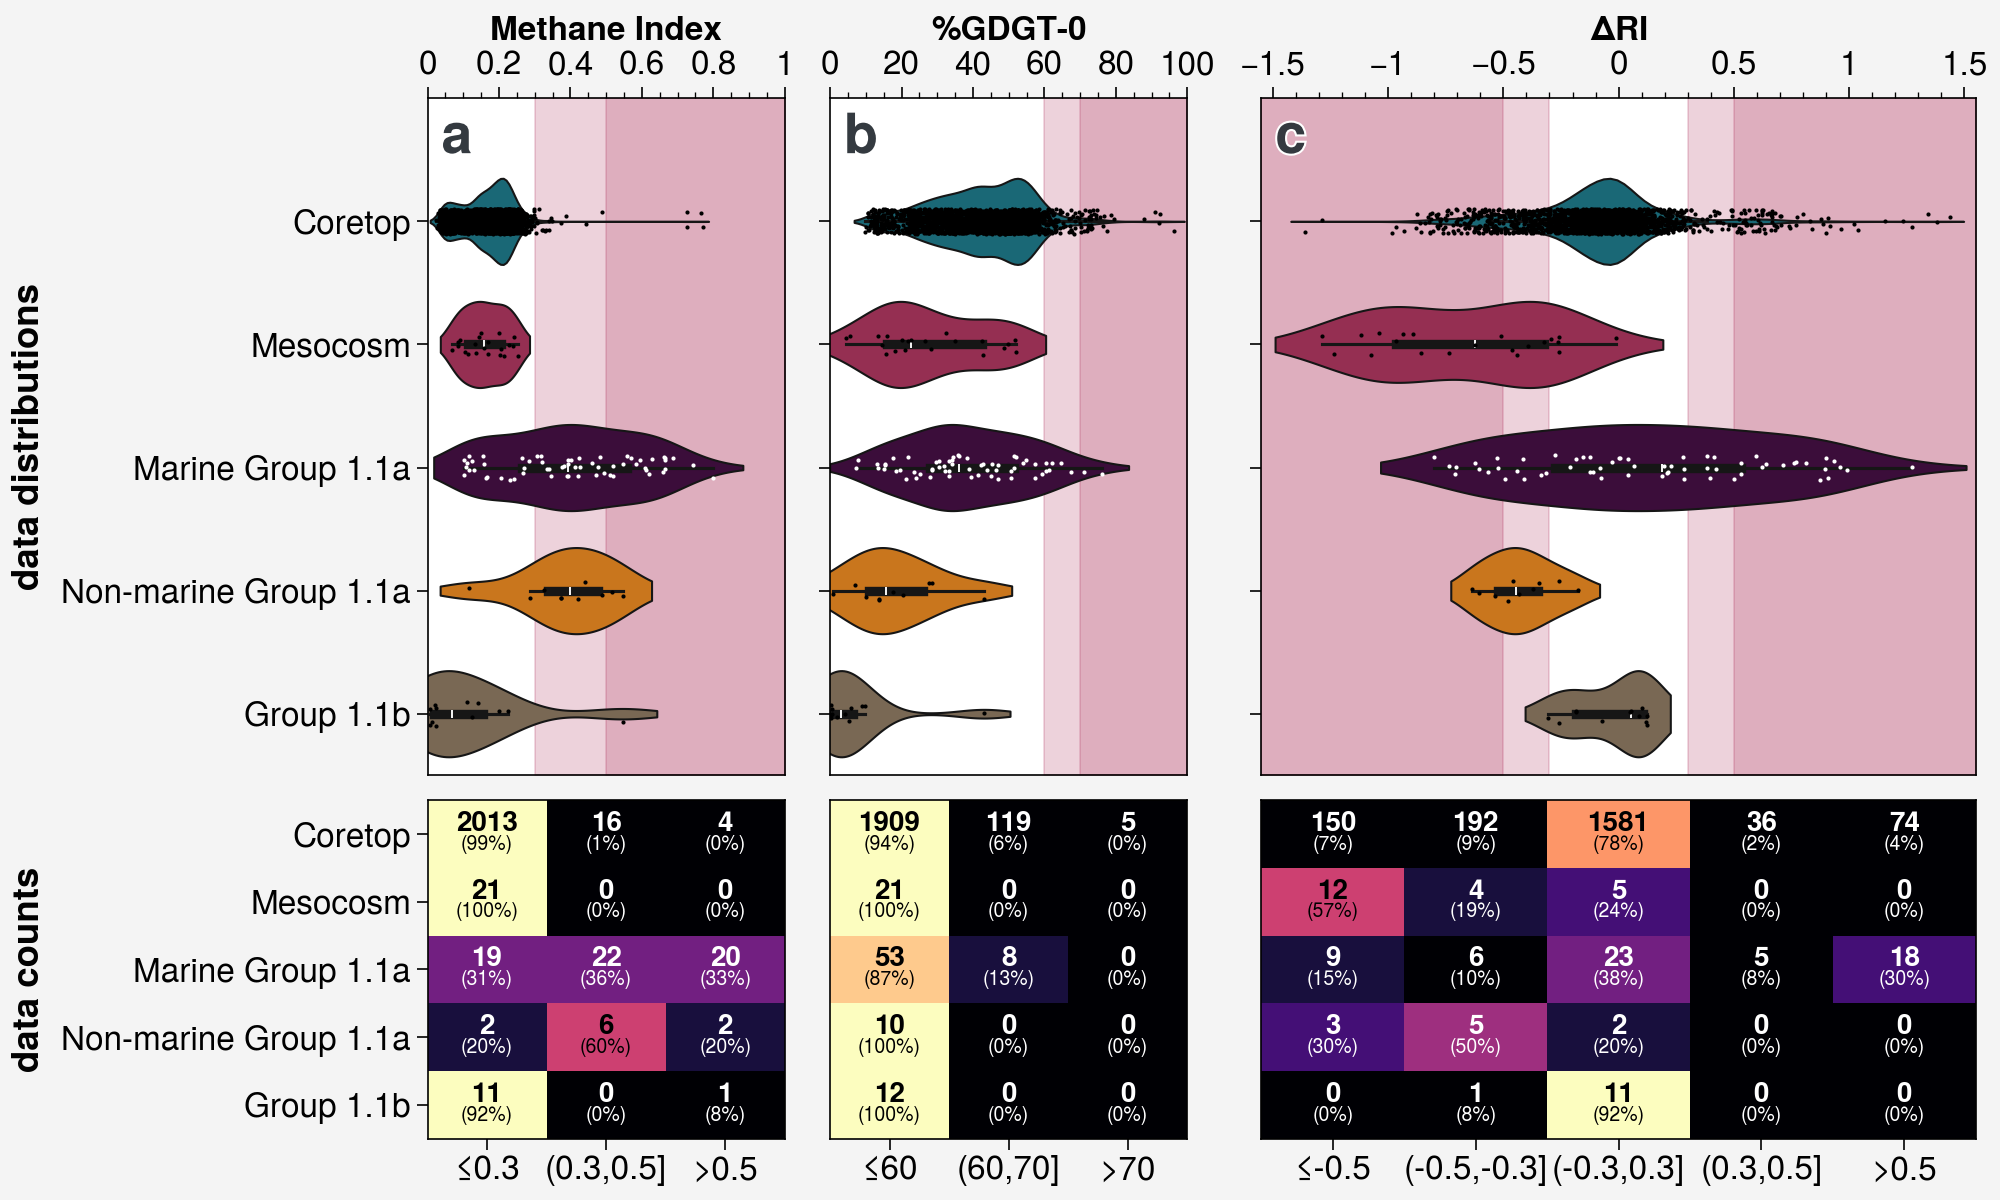

In [52]:
x_params = ['methaneIndex','ZeroOverZeroCren','deltaRI']
x_labels = ['Methane Index','%GDGT-0','$\Delta$RI']

fig, axs = plot.subplots(figsize=(10,6),
                         ncols=len(x_params),nrows=2,
                         share=0, 
                         wratios=[1,1,2],
                         hratios=[1,0.5])

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
# plot_data = plot_data[plot_data['TEXRI_mahalDist_outliers_manual']==False]

ordered_categories = ['Coretop','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['organism_broadClass4'], 
                                              categories=ordered_categories, ordered=True)
plot_data['binned_publicationYear'] = pd.cut(plot_data['publicationYear'], bins=[2000,2014,2030], labels=['pre2014','post2014'])
plot_data = plot_data.sort_values('sorted_datatype', ascending=False)

for i, x_param in enumerate(x_params):
    ax = axs[0,i]
    sns.violinplot(
        data=plot_data,
        y='organism_broadClass4',
        x=x_param,
        hue='organism_broadClass4',
        ax=ax,
        palette=broadClass4_color_dict,
        legend=False,
        density_norm='width',
        width=0.7,
        cut=1
    )
    
    
    
    print(f'Median {x_param} by organism_broadClass4:')
    print(plot_data.groupby('organism_broadClass4')[x_param].median())
    
    # All groups except Marine Group 1.1a → black
    sns.stripplot(
        data=plot_data[plot_data['organism_broadClass4'] != 'Marine Group 1.1a'],
        y='organism_broadClass4',
        x=x_param,
        ax=ax,
        order=ordered_categories[::-1],
        legend=False,
        color='k',
        size=1.5,
    )

    # Marine Group 1.1a → white
    sns.stripplot(
        data=plot_data[plot_data['organism_broadClass4'] == 'Marine Group 1.1a'],
        y='organism_broadClass4',
        x=x_param,
        ax=ax,
        order=ordered_categories[::-1],
        legend=False,
        color='white',
        size=1.5,
    )
    
    ax.format(
        xlabel=x_labels[i],
    )
    

#### cosmetics
axs[0].format(
    ytickminor=False,
    grid=True,
    xlim=(0,1),
    xticks=np.arange(0,1.1,0.2),
)
axs[0].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.3, x2=1, color='pink9', alpha=0.2, zorder=0)
axs[0].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.5, x2=1, color='pink9', alpha=0.2, zorder=0)

axs[1].format(
    ytickminor=False,
    grid=True,
    xlim=(0,1),
    xticks=np.arange(0,1.1,0.2),
    xticklabels=[f'{x*100:.0f}' for x in np.arange(0,1.1,0.2)]
)
axs[1].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.6, x2=1, color='pink9', alpha=0.2, zorder=0)
axs[1].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.7, x2=1, color='pink9', alpha=0.2, zorder=0)



axs[2].format(
    ytickminor=False,
    grid=True,
    xlim=(-1.55,1.55),
)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=axs[2].get_xlim()[0], x2=-0.5, color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=axs[2].get_xlim()[0], x2=-0.3, color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.3,x2=axs[2].get_xlim()[1], color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.5,x2=axs[2].get_xlim()[1], color='pink9', alpha=0.2, zorder=0)

axs[0,:].format(ylabel='',
           ylim=(-0.5, len(axs[0].get_yticks())),
           yticklabels=ordered_categories[::-1],)

### heatmap
for i, x_param in enumerate(x_params):
    plot_heatmap_data = plot_data
    plot_heatmap_data['x_bin'] = pd.cut(plot_heatmap_data[x_param], 
                                        bins=[-np.inf,0.3,0.5,np.inf] if x_param=='methaneIndex' else
                                        [-np.inf,0.6,0.8,np.inf] if x_param=='ZeroOverZeroCren' else
                                        [-np.inf,-0.5,-0.3,0.3,0.5,np.inf])
    heatmap_df = plot_heatmap_data.pivot_table(index='organism_broadClass4',
                                                columns='x_bin',
                                                values='TEX86',
                                                aggfunc='count',
                                                sort=False).reset_index()
    heatmap_df['organism_broadClass4'] = pd.Categorical(heatmap_df['organism_broadClass4'],
                                                       categories=ordered_categories,
                                                       ordered=True)

    sorted_heatmap_df = heatmap_df.sort_values('organism_broadClass4')[::-1]
    normalized_heatmap_df = sorted_heatmap_df.set_index('organism_broadClass4').div(
        sorted_heatmap_df.set_index('organism_broadClass4').sum(axis=1), axis=0
    )
    
    count_data = sorted_heatmap_df.set_index('organism_broadClass4')
    
    ax = axs[1,i]
    
    # Use pcolormesh instead of imshow - better PDF rendering
    im = ax.pcolormesh(
        np.arange(len(normalized_heatmap_df.columns) + 1),
        np.arange(len(normalized_heatmap_df) + 1),
        normalized_heatmap_df.values,
        cmap='magma',
        vmin=0,
        vmax=1,
        edgecolors='white',
        linewidth=0.,
        shading='flat'
    )
    
    # Add text annotations with counts and percentages
    for row in range(len(normalized_heatmap_df)):
        for col in range(len(normalized_heatmap_df.columns)):
            proportion = normalized_heatmap_df.values[row, col]
            count = count_data.values[row, col]
            
            text_color = 'black' if proportion > 0.5 else 'white'
            
            # Count text (larger)
            ax.text(col + 0.5, row + 0.65, f'{int(count)}',
                ha='center', va='center',
                fontsize=10,
                fontweight='bold',
                color=text_color)
            
            # Percentage text (smaller)
            ax.text(col + 0.5, row + 0.35, f'({proportion*100:.0f}%)',
                ha='center', va='center',
                fontsize=7,
                color=text_color)
    
    # Format axes
    if i == 0:  # Only first column gets y-labels
        ax.format(
            xlim=(0, len(normalized_heatmap_df.columns)),
            ylim=(0, len(normalized_heatmap_df)),
            xticks=np.arange(len(normalized_heatmap_df.columns)) + 0.5,
            yticks=np.arange(len(normalized_heatmap_df)) + 0.5,
            yticklabels=[str(x) for x in normalized_heatmap_df.index],
            xticklabels=['≤0.3','(0.3,0.5]','>0.5'] if x_param=='methaneIndex' else \
                           ['≤60','(60,70]','>70'] if x_param=='ZeroOverZeroCren' else \
                           ['≤-0.5','(-0.5,-0.3]','(-0.3,0.3]','(0.3,0.5]','>0.5'],
            yticklabelsize=8,
            xticklabelsize=8,
            xrotation=0,
        )
    else:  # Other columns: no y-labels
        ax.format(
            xlim=(0, len(normalized_heatmap_df.columns)),
            ylim=(0, len(normalized_heatmap_df)),
            xticks=np.arange(len(normalized_heatmap_df.columns)) + 0.5,
            yticks=[],
            xticklabels=['≤0.3','(0.3,0.5]','>0.5'] if x_param=='methaneIndex' else \
                           ['≤60','(60,70]','>70'] if x_param=='ZeroOverZeroCren' else \
                           ['≤-0.5','(-0.5,-0.3]','(-0.3,0.3]','(0.3,0.5]','>0.5'],
            xticklabelsize=8,
            xrotation=0,
            xlabel='',
            ylabel=''
        )
    
    # # Add colorbar only to last panel
    # if i == len(x_params) - 1:
    #     fig.colorbar(im, ax=ax, label='Proportion', loc='r', shrink=0.8)

# axs[1,:].axis('off')
axs.format(labelsize=12,fontsize=12,labelweight='bold',
           rowlabels=['data distributions','data counts'],
           grid=False)
axs[0,1:].format(ylabel='', yticklabels=[])

plot.rc['abc']=True
axs[0,:].format(abc=True, abcloc='ul', abcsize=20, abccolor='gray8',
                xtickloc='top')

plot.rc['abc']=False
axs[1,:].format(abc=False,xtickminor=False,ytickminor=False,grid=False)

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS5_culture_mesocosm_coretop_QC_violin_heatmap.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

### 3.3.3 Determining confidence level for the Mahalanobis ellipse

In [53]:
### Test confidence level effect on the TEXRI feature set
confidence_levels = np.arange(0.75, 0.991, 0.01)
thresholds = []
test_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]

x_param = 'TEX86'
y_param = 'scaledRI_cren3'
collect_stats_df = pd.DataFrame(np.zeros((len(confidence_levels)*4,7)),
                                columns=['confidence_level','datatype',
                                         'threshold','pval','rho',
                                         'include_len',
                                         'excluded_len'])
                                
for i, conf_level in enumerate(confidence_levels):
    detector = MahalanobisOutlierDetector([x_param, y_param], confidence=conf_level)
    detector.fit(test_data[test_data['datatype']=='coretop'][test_data['gdgt23ratio'] <= 5])
    threshold_ = detector.threshold
    
    ### collect stats for total data and each datatype
    outlier_flags = detector.detect_outliers(test_data)
    filtered_data = test_data[~outlier_flags]
    reg_x = filtered_data[x_param]
    reg_y = filtered_data[y_param]
    nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
    rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
    excluded_len = len(test_data) - len(filtered_data)  
    collect_stats_df.at[i*4 + 0, 'confidence_level'] = conf_level
    collect_stats_df.at[i*4 + 0, 'datatype'] = 'all'
    collect_stats_df.at[i*4 + 0, 'threshold'] = threshold_
    collect_stats_df.at[i*4 + 0, 'pval'] = pval
    collect_stats_df.at[i*4 + 0, 'rho'] = rho
    collect_stats_df.at[i*4 + 0, 'include_len'] = len(filtered_data)
    collect_stats_df.at[i*4 + 0, 'excluded_len'] = excluded_len
    
    
    grouped = test_data.groupby('datatype')
    for j, (name, group) in enumerate(grouped):
        outlier_flags = detector.detect_outliers(group)
        filtered_data = group[~outlier_flags]
        
        reg_x = filtered_data[x_param]
        reg_y = filtered_data[y_param]
        nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
        rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
        excluded_len = len(group) - len(filtered_data)
        
        collect_stats_df.at[i*4 + j+1, 'confidence_level'] = conf_level
        collect_stats_df.at[i*4 + j+1, 'datatype'] = name
        collect_stats_df.at[i*4 + j+1, 'threshold'] = threshold_
        collect_stats_df.at[i*4 + j+1, 'pval'] = pval
        collect_stats_df.at[i*4 + j+1, 'rho'] = rho
        collect_stats_df.at[i*4 + j+1, 'include_len'] = len(filtered_data)
        collect_stats_df.at[i*4 + j+1, 'excluded_len'] = excluded_len
    
        
collect_stats_df

,confidence_level,datatype,threshold,pval,rho,include_len,excluded_len
0,0.75,all,1.67,0.00,0.89,1617.00,520.00
1,0.75,coretop,1.67,0.00,0.89,1583.00,450.00
2,0.75,culture,1.67,0.00,0.80,31.00,52.00
3,0.75,mesocosm,1.67,0.67,0.50,3.00,18.00
4,0.76,all,1.69,0.00,0.89,1634.00,503.00
...,...,...,...,...,...,...,...
95,0.98,mesocosm,2.80,0.00,0.87,15.00,6.00
96,0.99,all,3.03,0.00,0.87,2079.00,58.00
97,0.99,coretop,3.03,0.00,0.88,2000.00,33.00
98,0.99,culture,3.03,0.00,0.77,62.00,21.00


In [54]:
### Test confidence level effect on the TEXRI feature set
confidence_levels = np.arange(0.75, 0.991, 0.01)
thresholds = []
test_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]

x_param = 'TEX86'
y_param = 'scaledRI_cren3'

collect_stats_df_manual = pd.DataFrame(np.zeros((len(confidence_levels)*4,7)),
                                columns=['confidence_level','datatype',
                                         'threshold','pval','rho',
                                         'include_len',
                                         'excluded_len'])
                                
for i, conf_level in enumerate(confidence_levels):
    detector = MahalanobisOutlierDetector([x_param, y_param], confidence=conf_level)
    detector.fit(test_data[test_data['datatype']=='coretop'][test_data['gdgt23ratio'] <= 5])
    threshold_ = detector.threshold
    
    ### collect stats for total data and each datatype
    outlier_flags = detector.detect_outliers_manual(test_data)
    filtered_data = test_data[~outlier_flags]
    reg_x = filtered_data[x_param]
    reg_y = filtered_data[y_param]
    nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
    rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
    excluded_len = len(test_data) - len(filtered_data)  
    collect_stats_df_manual.at[i*4 + 0, 'confidence_level'] = conf_level
    collect_stats_df_manual.at[i*4 + 0, 'datatype'] = 'all'
    collect_stats_df_manual.at[i*4 + 0, 'threshold'] = threshold_
    collect_stats_df_manual.at[i*4 + 0, 'pval'] = pval
    collect_stats_df_manual.at[i*4 + 0, 'rho'] = rho
    collect_stats_df_manual.at[i*4 + 0, 'include_len'] = len(filtered_data)
    collect_stats_df_manual.at[i*4 + 0, 'excluded_len'] = excluded_len
    
    
    grouped = test_data.groupby('datatype')
    for j, (name, group) in enumerate(grouped):
        outlier_flags = detector.detect_outliers_manual(group)
        filtered_data = group[~outlier_flags]
        
        reg_x = filtered_data[x_param]
        reg_y = filtered_data[y_param]
        nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
        rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
        excluded_len = len(group) - len(filtered_data)
        
        collect_stats_df_manual.at[i*4 + j+1, 'confidence_level'] = conf_level
        collect_stats_df_manual.at[i*4 + j+1, 'datatype'] = name
        collect_stats_df_manual.at[i*4 + j+1, 'threshold'] = threshold_
        collect_stats_df_manual.at[i*4 + j+1, 'pval'] = pval
        collect_stats_df_manual.at[i*4 + j+1, 'rho'] = rho
        collect_stats_df_manual.at[i*4 + j+1, 'include_len'] = len(filtered_data)
        collect_stats_df_manual.at[i*4 + j+1, 'excluded_len'] = excluded_len
    
        
collect_stats_df_manual

,confidence_level,datatype,threshold,pval,rho,include_len,excluded_len
0,0.75,all,1.67,0.00,0.90,1691.00,446.00
1,0.75,coretop,1.67,0.00,0.90,1637.00,396.00
2,0.75,culture,1.67,0.00,0.93,49.00,34.00
3,0.75,mesocosm,1.67,0.10,0.80,5.00,16.00
4,0.76,all,1.69,0.00,0.90,1708.00,429.00
...,...,...,...,...,...,...,...
95,0.98,mesocosm,2.80,0.00,0.87,15.00,6.00
96,0.99,all,3.03,0.00,0.87,2090.00,47.00
97,0.99,coretop,3.03,0.00,0.88,2002.00,31.00
98,0.99,culture,3.03,0.00,0.84,71.00,12.00


In [55]:
broadClass4_color_dict2 = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan4',
    'Marine Group 1.1a':'eggplant purple',
    'Non-marine Group 1.1a':'yellow9',
    'Group 1.1b':'dark taupe',
    'Mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

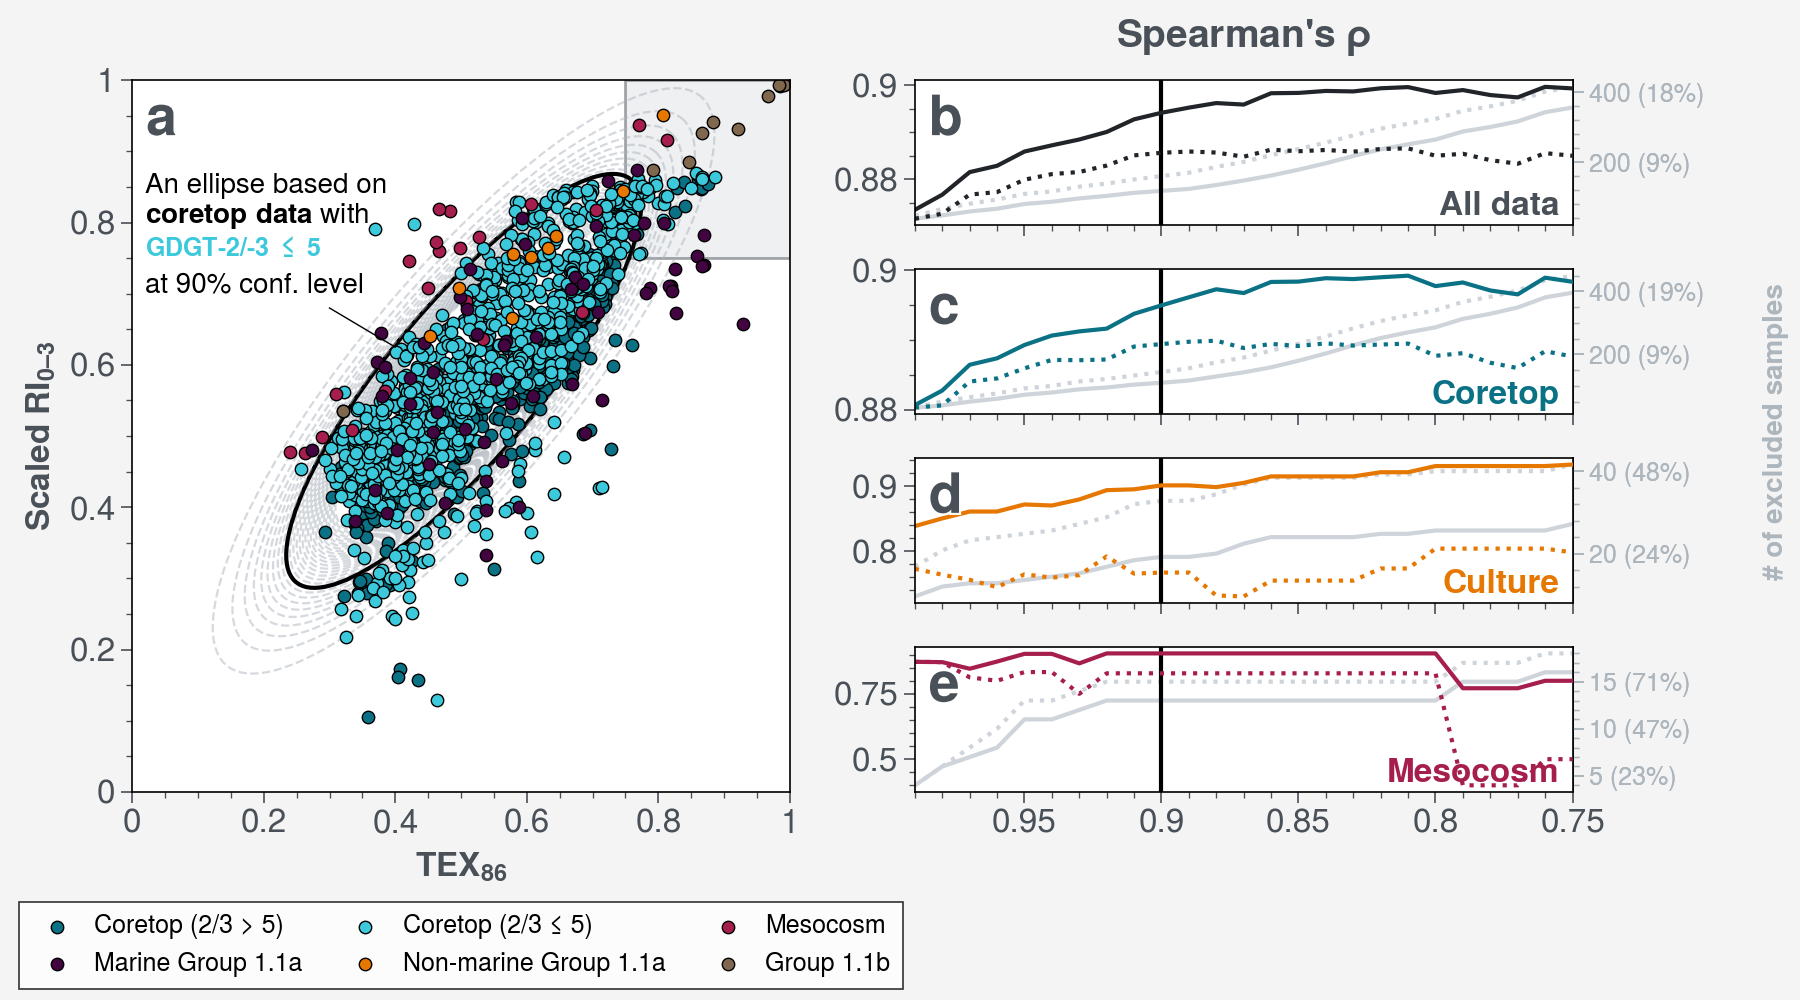

In [56]:
array =[[1,1,2,2],
        [1,1,3,3],
        [1,1,4,4],
        [1,1,5,5]]

fig, axs = plot.subplots(array,figsize=(9,5),share=0,hspace=1.75,wspace=5)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data['datatype2'] = plot_data['organism_broadClass4']
plot_data['datatype2'] = ['coretop_high23ratio' if (x=='Coretop' and y>5) else
                          'coretop_low23ratio' if (x=='Coretop' and y<=5) else
                          x for x,y in zip(plot_data['organism_broadClass4'], plot_data['gdgt23ratio'])]
ordered_categories = ['coretop_high23ratio','coretop_low23ratio','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['datatype2'], 
                                              categories=ordered_categories, ordered=True)
grouped = plot_data.groupby('sorted_datatype')

x_param = 'TEX86'
x_param_label = r'TEX$_{86}$'
y_param = 'scaledRI_cren3'
y_param_label = u'Scaled RI$_{0\u20133}$'
sel_color_dict = broadClass4_color_dict2
ax = axs[0,0]
for name, group in grouped:
    plot_x = group[x_param]
    plot_y = group[y_param]
    ax.scatter(plot_x, plot_y, 
                c=sel_color_dict.get(name,'gray'),
                s=20,
                mec='k',mew=0.5,
                label=name)

    
ax.format(
        xlim=(0,1), ylim=(0,1),
        xlabel=x_param_label,
        ylabel=y_param_label,
)   

rect = Rectangle((0.75, 0.75), 0.25, 0.25, transform=ax.transAxes,
                 facecolor='gray3', alpha=0.5, edgecolor='gray7', linewidth=1.0, zorder=0)
ax.add_patch(rect)

text = 'An ellipse based on'
ax.text(0.02, 0.74+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{coretop\ data}$ with"
ax.text(0.02, 0.7+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10,)

text = r'GDGT-2/-3 $\leq$ 5'
ax.text(0.02, 0.65+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='cyan4',
              fontsize=9,fontweight='bold',)

text = 'at 90% conf. level'
ax.text(0.02, 0.6+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10,)

ax.plot([0.3,0.4],[0.68,0.625], transform=ax.transAxes, color='k', linewidth=0.5,)
    
### Confidence level sensitivity test
confidence_levels = np.arange(0.7,0.991,0.01)
for conf_level in confidence_levels:
        conf_level = round(conf_level,2)
        detector_low23 = MahalanobisOutlierDetector([x_param,y_param],confidence=conf_level)
        fitted_coretop_low23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']<=5]
        detector_low23.fit(fitted_coretop_low23)
        detector_low23.plot_ellipse(ax, 
                                edgecolor='k' if conf_level==0.90  else 'gray5', 
                                linewidth=1.5 if conf_level==0.90 else 0.8, 
                                ls='-' if conf_level==0.90 else '--',
                                alpha=1 if conf_level==0.90 else 0.5,
                                zorder=0)

data_type_labels = {
        'all':'All data',
        'coretop':'Coretop',
        'mesocosm':'Mesocosm',
        'culture':'Culture'
}

sel_color_dict = datatype_color_dict
grouped_stats = collect_stats_df.groupby('datatype')
grouped_stats_manual = collect_stats_df_manual.groupby('datatype')
for i, (name, group) in enumerate(grouped_stats):
        
        ax = axs[i+1]
        ax.plot(group['confidence_level'].values[::-1], 
                group['rho'].values[::-1], 
                label=name, ls=':',m='',s=3,
                c=sel_color_dict.get(name,'gray9'))
        
        plot_group_manual = grouped_stats_manual.get_group(name)
        ax.plot(plot_group_manual['confidence_level'].values[::-1], 
                plot_group_manual['rho'].values[::-1], 
                label=name, ls='-',m='',s=5,
                c=sel_color_dict.get(name,'gray9'))
        
        ax2 = ax.twinx()
        ax2.set_zorder(ax.get_zorder()-1)
        ax2.patch.set_visible(False)
        
        ax2.plot(group['confidence_level'].values[::-1], 
                 group['excluded_len'].values[::-1], 
                 label=name,
                c='gray4', linestyle=':')
        
        ax2.plot(plot_group_manual['confidence_level'].values[::-1], 
                 plot_group_manual['excluded_len'].values[::-1], 
                 label=name,
                c='gray4', linestyle='-')
        
        total_samples = len(plot_data) if name=='all' else len(plot_data[plot_data['datatype']==name])
        
        ax2.format(
                yticklabels=[f'{int(x)} ({int(x/total_samples*100)}%)' for (x) in ax2.get_yticks()],
                ytickcolor='gray5',
                yticklabelcolor='gray5',
        )
        
        
        text = data_type_labels.get(name,name)
        ax.text(0.98, 0.02, text, transform=ax.transAxes,
                ha='right', va='bottom',c=sel_color_dict.get(name,'gray7'),
                fontsize=12, fontweight='bold',)

# axs_idx = [1,2,3,4]
# ylim_list = [(0.87,0.89),(0.88,0.89),(0.7,0.93),(0.6,0.95)]
# for i in axs_idx:
#         ax = axs[i]
#         ax.format(xlim=(1,0.7), xlabel='Confidence Level',
#                   ylim=ylim_list[i-1], ylabel=r'',
#                   )
axs[1:].axvline(0.9, color='k', linestyle='-', linewidth=1.5, label='90% Confidence Level',zorder=0)

text = r"# of excluded samples"
axs[2].text(1.29, 0.9, text, transform=axs[2].transAxes,
            rotation=90,ha='left', va='top',c='gray5',
            fontsize=10, fontweight='bold',)

#####
h, l = axs[0].get_legend_handles_labels()
new_list = [
    item.replace('coretop_high23ratio', 'Coretop (2/3 > 5)') 
        if item == 'coretop_high23ratio'
    else item.replace('coretop_low23ratio', r'Coretop (2/3 ≤ 5)')
        if item == 'coretop_low23ratio'
    else item
    for item in l
]
axs[0].legend(h, new_list, 
              loc='b', ncols=3, fontsize=10)

### upper right corner
axs_idx = [1,2,3]
for i in axs_idx:
        ax = axs[i]
        ax.format(xticklabels=[],
                  xlabel='')

axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

#####
text = r"Spearman's $\rho$"
axs[1].text(0.5, 1.15, text, transform=axs[1].transAxes,
            ha='center', va='bottom',c='gray7',
            fontsize=14, fontweight='bold',)

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = f'figS6_TEXRI_mahalanobis_distance_confidence_level_sensitivity.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

In [57]:
# Define all feature combinations
feature_sets = {
    'TEXRI': ['TEX86', 'scaledRI'],
    'TEXRI_cren3': ['TEX86', 'scaledRI_cren3'],
    'TEXfG0': ['TEX86', 'fGDGT_0'],
    'TEXfCren': ['TEX86', 'fGDGT_cren'],
    'RIfG0': ['scaledRI', 'fGDGT_0'],
    'RIfCren': ['scaledRI', 'fGDGT_cren'],
    'fG0Cren': ['fGDGT_0', 'fGDGT_cren'],
    'TEXRIfG0': ['TEX86', 'scaledRI', 'fGDGT_0'],
    'TEXRIfG0Cren': ['TEX86', 'scaledRI', 'fGDGT_0', 'fGDGT_cren'],
    'allGDGTs': ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
}

# Fit and apply all screening methods
fitted_detectors = {}
confidence_level = 0.9

for name, features in feature_sets.items():
    detector = MahalanobisOutlierDetector(features, confidence=confidence_level)
    
    # Fit on coretop data
    detector.fit(combined_df_raw[(combined_df_raw['datatype'] == 'coretop') & (combined_df_raw['lowAbundanceFlag'] == False)])
    print(f"{name}_mahalDist_thr: {detector.threshold:.4f}")
    
    # Apply to entire dataset
    combined_df_raw[f'{name}_mahalDist'] = detector.transform(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_outliers'] = detector.detect_outliers(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_outliers_manual'] = detector.detect_outliers_manual(combined_df_raw)
    
    fitted_detectors[name] = detector


TEXRI_mahalDist_thr: 2.1460
TEXRI_cren3_mahalDist_thr: 2.1460
TEXfG0_mahalDist_thr: 2.1460
TEXfCren_mahalDist_thr: 2.1460
RIfG0_mahalDist_thr: 2.1460
RIfCren_mahalDist_thr: 2.1460
fG0Cren_mahalDist_thr: 2.1460
TEXRIfG0_mahalDist_thr: 2.5003
TEXRIfG0Cren_mahalDist_thr: 2.7892
allGDGTs_mahalDist_thr: 3.2626


In [58]:
from TEXAS.data import MahalanobisOutlierDetector

# Define all feature combinations
feature_sets = {
    'TEXRI': ['TEX86', 'scaledRI'],
    'TEXRI_cren3': ['TEX86', 'scaledRI_cren3'],
    'TEXfG0': ['TEX86', 'fGDGT_0'],
    'TEXfCren': ['TEX86', 'fGDGT_cren'],
    'RIfG0': ['scaledRI', 'fGDGT_0'],
    'RIfCren': ['scaledRI', 'fGDGT_cren'],
    'fG0Cren': ['fGDGT_0', 'fGDGT_cren'],
    'TEXRIfG0': ['TEX86', 'scaledRI', 'fGDGT_0'],
    'TEXRIfG0Cren': ['TEX86', 'scaledRI', 'fGDGT_0', 'fGDGT_cren'],
    'allGDGTs': ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
}

# Fit and apply all screening methods
fitted_detectors = {}
confidence_level = 0.9

for name, features in feature_sets.items():
    detector = MahalanobisOutlierDetector(features, confidence=confidence_level)
    
    # Fit on coretop data
    detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
        (combined_df_raw['datatype'] == 'coretop') 
        & (combined_df_raw['gdgt23ratio'] <= 5)])

    
    print(f"{name}_mahalDist_low23ratio_thr: {detector.threshold:.4f}")
    
    # Apply to entire dataset
    combined_df_raw[f'{name}_mahalDist_low23ratio'] = detector.transform(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_low23ratio_outliers'] = detector.detect_outliers(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(combined_df_raw)
    
    fitted_detectors[name] = detector
    


TEXRI_mahalDist_low23ratio_thr: 2.1460
TEXRI_cren3_mahalDist_low23ratio_thr: 2.1460
TEXfG0_mahalDist_low23ratio_thr: 2.1460


TEXfCren_mahalDist_low23ratio_thr: 2.1460
RIfG0_mahalDist_low23ratio_thr: 2.1460
RIfCren_mahalDist_low23ratio_thr: 2.1460
fG0Cren_mahalDist_low23ratio_thr: 2.1460
TEXRIfG0_mahalDist_low23ratio_thr: 2.5003
TEXRIfG0Cren_mahalDist_low23ratio_thr: 2.7892
allGDGTs_mahalDist_low23ratio_thr: 3.2626


### 3.3.4 Comparison between deltaRI and Mahalanobis ellipse

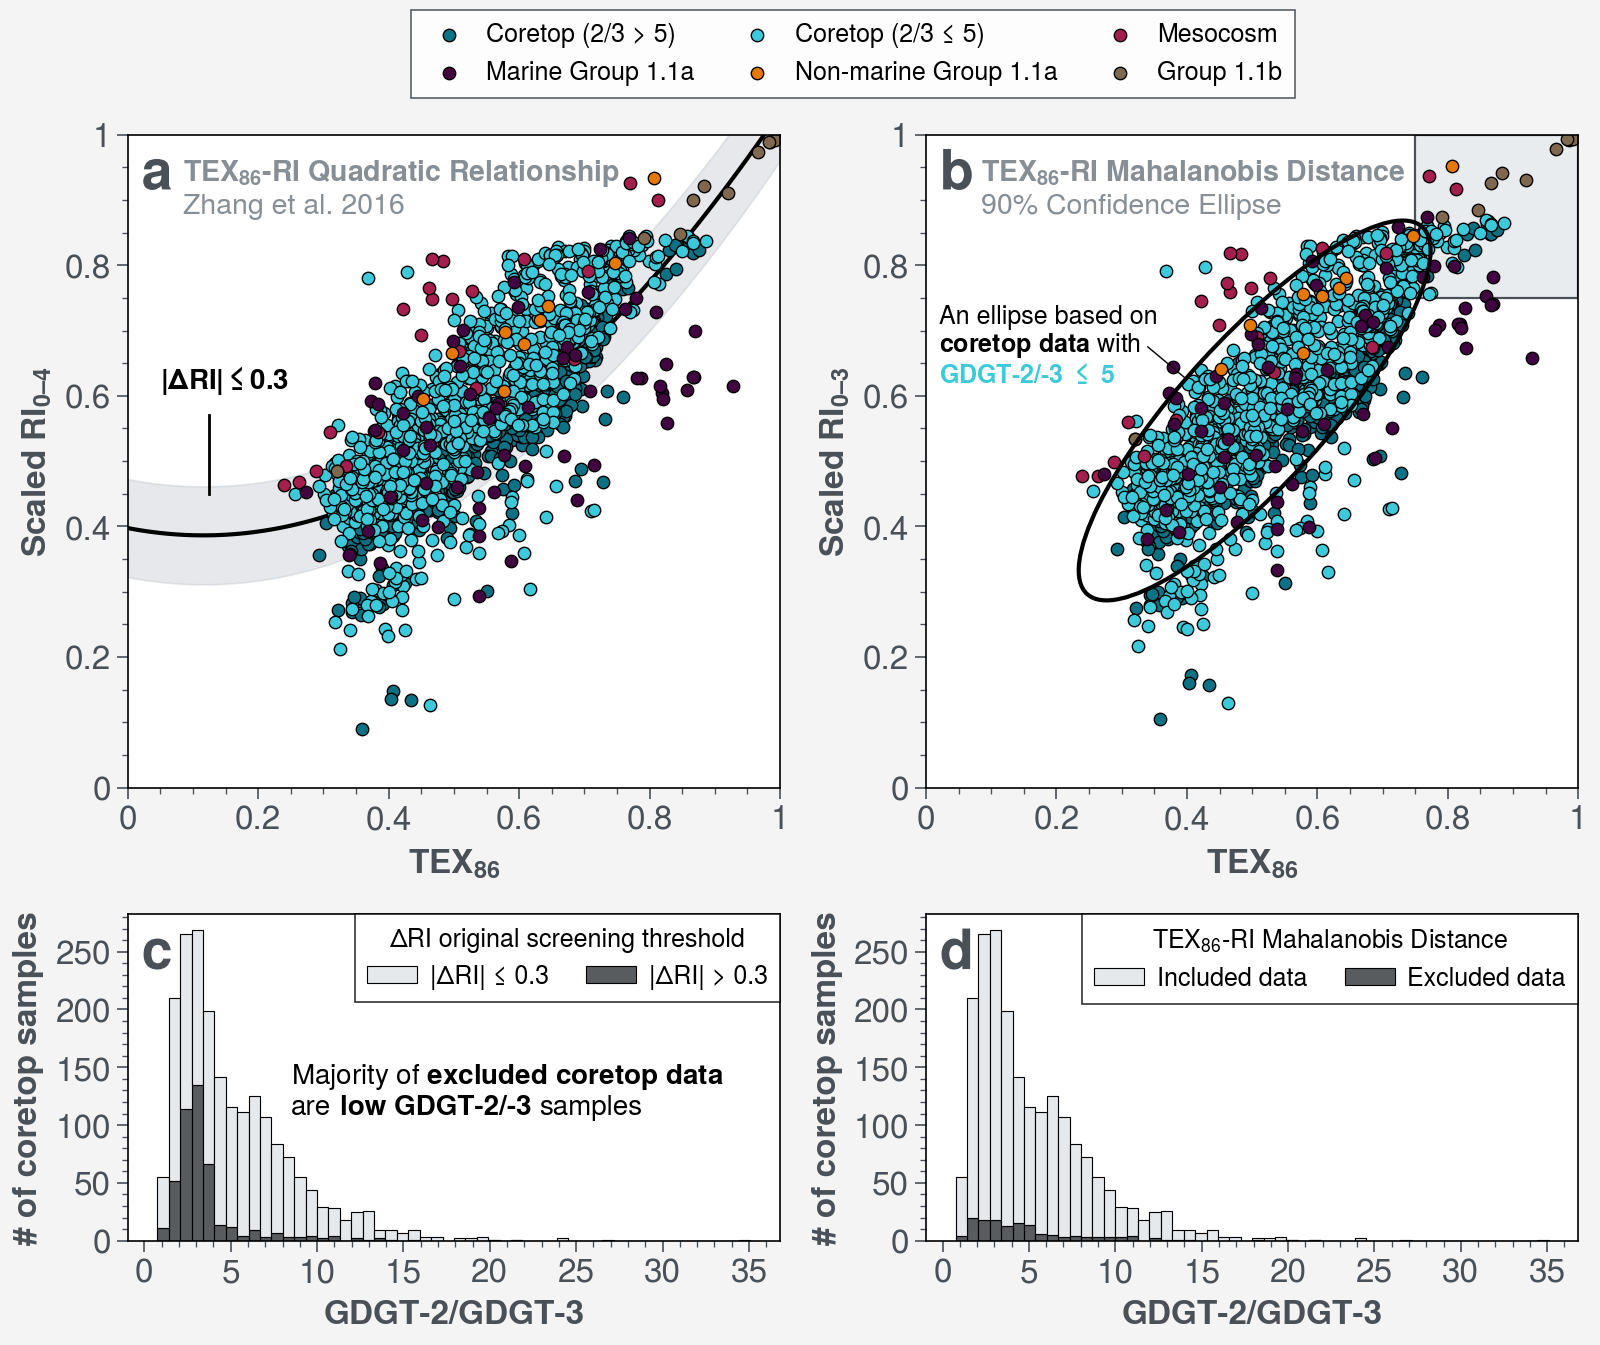

In [59]:
fig, axs = plot.subplots(ncols=2,nrows=2, width=8, hratios=[1,0.5],share=0)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data['datatype2'] = plot_data['organism_broadClass4']
plot_data['datatype2'] = ['coretop_high23ratio' if (x=='Coretop' and y>5) else
                          'coretop_low23ratio' if (x=='Coretop' and y<=5) else
                          x for x,y in zip(plot_data['organism_broadClass4'], plot_data['gdgt23ratio'])]
ordered_categories = ['coretop_high23ratio','coretop_low23ratio','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['datatype2'], 
                                              categories=ordered_categories, ordered=True)
grouped = plot_data.groupby('sorted_datatype')

sel_color_dict = broadClass4_color_dict2

for name, group in grouped:
    plot_x = group['TEX86']
    plot_y = group['scaledRI']
    axs[0,0].scatter(plot_x, plot_y, 
                c=sel_color_dict.get(name,'gray'),
                s=20,
                mec='k',mew=0.5,
                label=name)
    plot_y2 = group['scaledRI_cren3']
    axs[0,1].scatter(plot_x, plot_y2, 
                c=sel_color_dict.get(name,'gray'),
                s=20,
                mec='k',mew=0.5,
                label=name)


ax = axs[0,0]
### Zhang16 TEX-RI curve
tex_range = np.arange(0,1.01,0.01)
ri_zhang16 = -0.77*tex_range + 3.32*(tex_range**2) + 1.59
ax.plot(tex_range, ri_zhang16/4, color='k', label='Zhang et al. (2016)', zorder=0)
ri_zhang16_upper = ri_zhang16 + 0.3
ri_zhang16_lower = ri_zhang16 - 0.3
ax.fill_between(tex_range, ri_zhang16_lower/4, ri_zhang16_upper/4, color='gray5', alpha=0.3, label='±0.3 RI', zorder=0)

text = r'TEX$_{86}$-RI Quadratic Relationship'
ax.text(0.085, 0.965, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25, fontweight='bold',)
text = 'Zhang et al. 2016'
ax.text(0.085, 0.91, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25,)

text = r'|$\Delta$RI|$\leq$0.3'
ax.text(0.05, 0.65, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10, fontweight='bold',)
ax.plot([0.125,0.125],[0.57,0.45], transform=ax.transAxes, color='k', linewidth=1,)

##################################################
ax = axs[0,1]

fitted_coretop_low23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']<=5]
detector_low23 = MahalanobisOutlierDetector(['TEX86','scaledRI_cren3'],confidence=0.9)
detector_low23.fit(fitted_coretop_low23)
detector_low23.plot_ellipse(ax, edgecolor='k', linewidth=1.5, label='90% Confidence Ellipse',ls='-',alpha=1)

rect = Rectangle((0.75,0.75),0.25,0.25, transform=ax.transAxes,
                 facecolor='gray2', edgecolor='gray7', linewidth=0.8, zorder=0)
ax.add_artist(rect)


######

text = r'TEX$_{86}$-RI Mahalanobis Distance'
ax.text(0.085, 0.965, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25, fontweight='bold',)
text = r'90% Confidence Ellipse'
ax.text(0.085, 0.91, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25,)

############################
text = 'An ellipse based on'
ax.text(0.02, 0.74, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{coretop\ data}$ with"
ax.text(0.02, 0.7, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)

text = r'GDGT-2/-3 $\leq$ 5'
ax.text(0.02, 0.65, text, transform=ax.transAxes,
              ha='left', va='top',c='cyan4',
              fontsize=9,fontweight='bold',)

ax.plot([0.34,0.4],[0.675,0.625], transform=ax.transAxes, color='k', linewidth=0.5,)


## plot stacked histrograms
ax = axs[1,0]
plot_coretop = plot_data[plot_data['datatype']=='coretop']
plot_coretop["bin_absDeltaRI"] = pd.cut(abs(plot_coretop['deltaRI']), bins=[0,0.3,2])
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='bin_absDeltaRI',
             palette={pd.Interval(0,0.3):'gray3', pd.Interval(0.3,2):'gray9'},
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['|ΔRI| ≤ 0.3','|ΔRI| > 0.3'], title='ΔRI original screening threshold')

text = r'Majority of $\bf{excluded\ coretop\ data}$'
ax.text(0.25, 0.55, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10,)

text = r'are'
ax.text(0.25, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10 )
text = r'low GDGT-2/-3'
ax.text(0.325, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10, fontweight='bold',)
text = 'samples'
ax.text(0.63, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10, )

## plot stacked histrograms for mahalanobis distance
ax = axs[1,1]
plot_coretop['TEXRI_cren3_mahal_outliers'] = detector_low23.detect_outliers(plot_coretop)
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='TEXRI_cren3_mahal_outliers',
             palette={False:'gray3', True:'gray9'},
             multiple='stack',
                legend=False)

h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['Included data','Excluded data'], title=r'$TEX_{86}$-RI Mahalanobis Distance')

##################################################

axs[0,0].format(
    xlim=(0,1), ylim=(0,1),
    xlabel=r'TEX$_{86}$',
    ylabel=u'Scaled RI$_{0\u20134}$'
)
axs[0,1].format(
    xlim=(0,1), ylim=(0,1),
    xlabel=r'TEX$_{86}$',
    ylabel=u'Scaled RI$_{0\u20133}$'
)

axs[1,:].format(
    xlabel='GDGT-2/GDGT-3',
    ylabel='# of coretop samples'
)
axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

h, l = axs[0,0].get_legend_handles_labels()
new_list = [
    item.replace('coretop_high23ratio', 'Coretop (2/3 > 5)') 
        if item == 'coretop_high23ratio'
    else item.replace('coretop_low23ratio', r'Coretop (2/3 ≤ 5)')
        if item == 'coretop_low23ratio'
    else item
    for item in l
]
fig.legend(h[1:7],new_list[1:7],
           loc='t', fontsize=8, framealpha=0.9, edgecolor='gray7', ncols=3,)

fpath = fr'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig4_TEXRI_mahalanobis_distance_gdgt23ratio.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

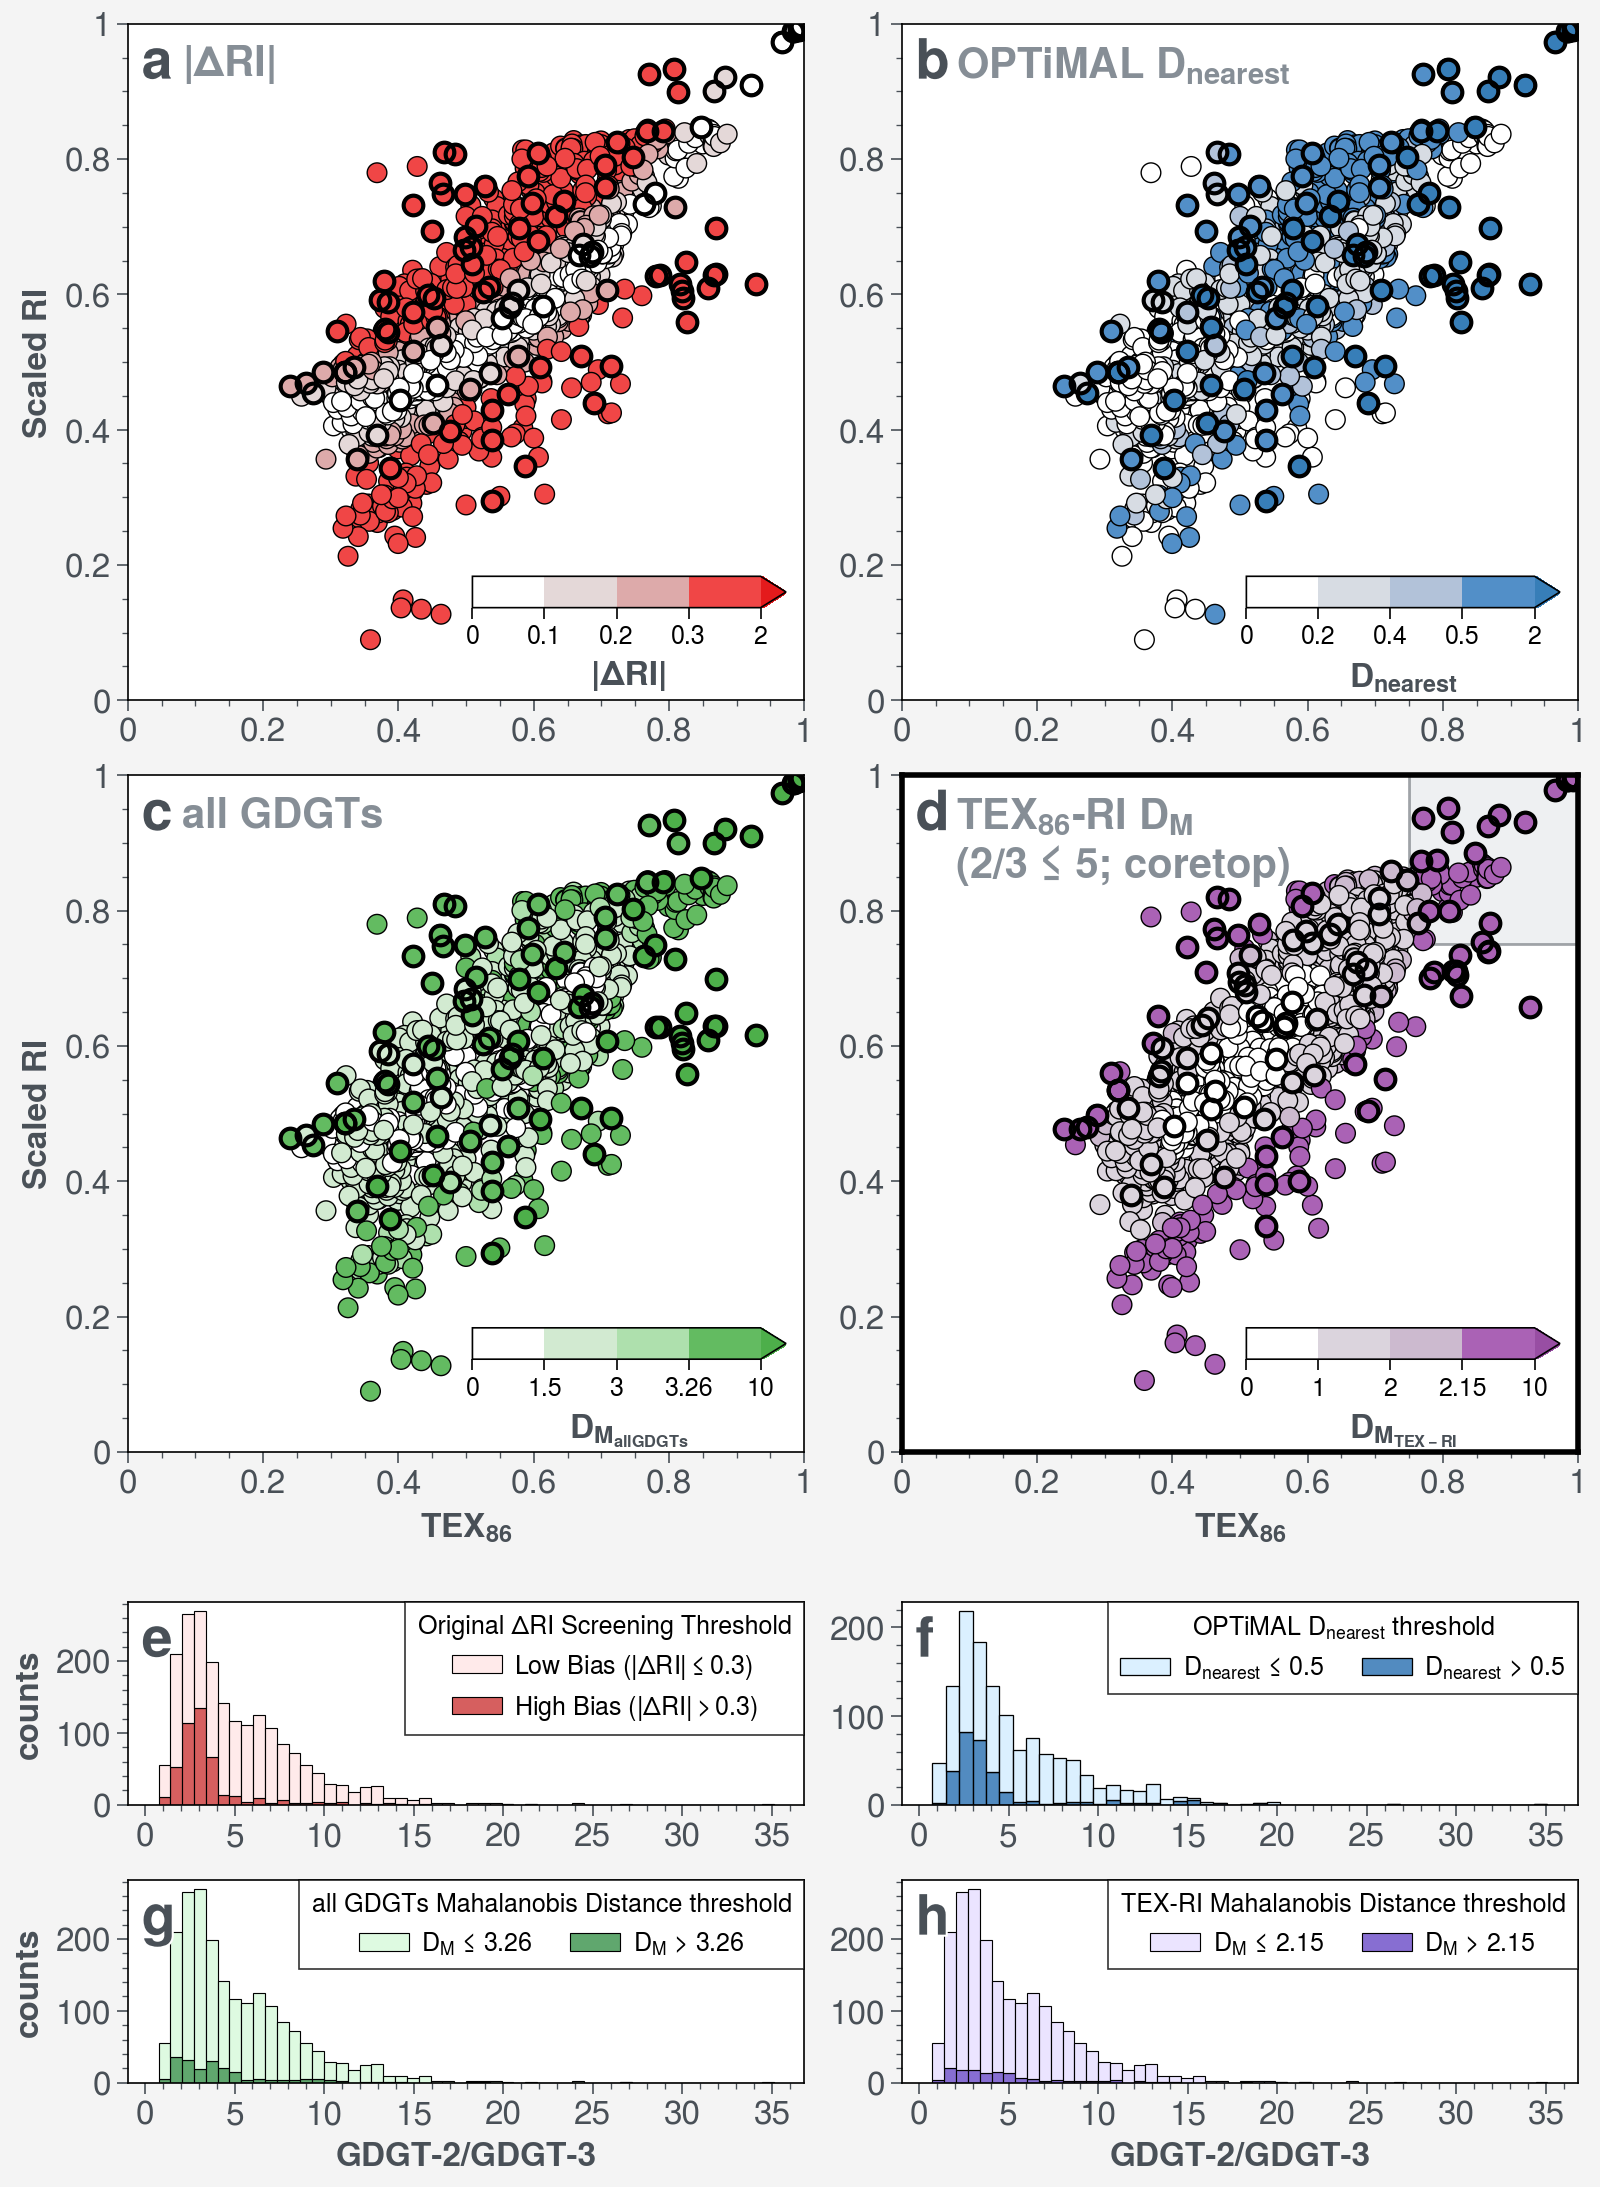

In [60]:
fig, axs = plot.subplots(ncols=2,nrows=4, width=8, 
                         hratios=[1,1,0.3,0.3],
                         hspace=[3,6,3],
                         share=0)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]


color_params = ['abs_deltaRI','OPTiMAL_Dnearest','allGDGTs_mahalDist', 'TEXRI_cren3_mahalDist_low23ratio',]
labels=['|ΔRI|',r'OPTiMAL D$_{nearest}$','all GDGTs',r'TEX$_{86}$-RI D$_{M}$'+f'\n(2/3 ≤ 5; coretop)']
cbar_labels=['|ΔRI|',r'D$_{nearest}$',r'D$_{M_{allGDGTs}}$',r'D$_{M_{TEX-RI}}$']
tab10_colors = plot.get_colors('Set1',N=len(color_params))
color_levels = [
    [0,0.1,0.2,0.3,2],
    [0,0.2,0.4,0.5,2],
    [0,1.5,3,3.2626,10],
    [0,1,2,2.1460,10]
]

for i, c_param in enumerate(color_params):
    ax = axs[i]
    
    plot_x = plot_data['TEX86']
    plot_y = plot_data['scaledRI_cren3'] if i==3 else plot_data['scaledRI']
    plot_c = plot_data[c_param]
    m = ax.scatter(plot_x, plot_y,
               c=plot_c,
               cmap=['w',tab10_colors[i]],
               levels=color_levels[i],
               extend='max',
               m='o',mec='k', mew=0.5,
               s=50, label=labels[i])
    
    cbar = ax.colorbar(m, label=cbar_labels[i],
                loc='lr',shrink=12,
                labelsize=12, labelweight='bold',
                labelcolor='gray7',
                frame=False)
    cbar.set_ticks(color_levels[i])
    
    text = labels[i]
    ax.text(0.08, 0.97, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=15, fontweight='bold',)
    
    grouped = plot_data.groupby('datatype')
    for name, group in grouped:
        if name != 'coretop':
            ax.scatter(
                group['TEX86'], 
                group['scaledRI_cren3'] if i==3 else group['scaledRI'],
                facecolor='none', 
                mec='k', mew=1.5, 
                m='o', s=50, label=name)
    

ax=axs[3]
ax.spines[:].set_linewidth(2.0)
rect = Rectangle((0.75, 0.75), 0.25, 0.25, transform=ax.transAxes,
                 facecolor='gray3', alpha=0.5, edgecolor='gray7', linewidth=1.0, zorder=0)
ax.add_patch(rect)


######## Plot histograms of the color parameters for coretop samples with GDGT-2/3 ratio ≤ 5, colored by whether they are excluded by the TEXRI Mahalanobis distance method or not
ax = axs[2,0]
max_val = plot_coretop['deltaRI'].abs().max()
plot_coretop["bin_absDeltaRI"] = pd.cut(
    plot_coretop['deltaRI'].abs(), 
    bins=[0, 0.3, max_val],
    labels=['Low Bias ($|\Delta RI| \leq 0.3$)', 'High Bias ($|\Delta RI| > 0.3$)']
)

m = sns.histplot(ax=ax, data=plot_coretop,
             x='gdgt23ratio', 
             hue='bin_absDeltaRI',
             palette={'Low Bias ($|\Delta RI| \leq 0.3$)': 'red1', # Light blue
                      'High Bias ($|\Delta RI| > 0.3$)': 'red9'}, # Strong red
             multiple='stack',
             legend=False)

h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['Low Bias ($|\Delta RI| \leq 0.3$)', 'High Bias ($|\Delta RI| > 0.3$)'], loc='ur',
          title='Original ΔRI Screening Threshold', ncols=1)

#OPTiMAL Dnearest histogram
ax = axs[2,1]
max_val = plot_coretop['OPTiMAL_Dnearest'].max()
plot_coretop['OPTiMAL_Dnearest_bin'] = pd.cut(
    plot_coretop['OPTiMAL_Dnearest'], 
    bins=[0, 0.5, max_val],
    labels=['D$_{nearest}$ ≤ 0.5', 'D$_{nearest}$ > 0.5']
)

m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='OPTiMAL_Dnearest_bin',
             palette={
                 'D$_{nearest}$ ≤ 0.5':'blue1',
                 'D$_{nearest}$ > 0.5':'blue9'
             },
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['D$_{nearest}$ ≤ 0.5','D$_{nearest}$ > 0.5'], title='OPTiMAL D$_{nearest}$ threshold')

#### All GDGTs Mahalanobis distance histogram
ax = axs[3,0]
max_val = plot_coretop['allGDGTs_mahalDist'].max()
plot_coretop['allGDGTs_mahalDist_bin'] = pd.cut(
    plot_coretop['allGDGTs_mahalDist'], 
    bins=[0, 3.2626, max_val],
    labels=['D$_{M}$ ≤ 3.26', 'D$_{M}$ > 3.26']
)
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='allGDGTs_mahalDist_bin',
             palette={
                 'D$_{M}$ ≤ 3.26':'green1',
                 'D$_{M}$ > 3.26':'green9'
             },
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['D$_{M}$ ≤ 3.26','D$_{M}$ > 3.26'], title='all GDGTs Mahalanobis Distance threshold')

#### TEXRI Mahalanobis distance histogram
ax = axs[3,1]
max_val = plot_coretop['TEXRI_cren3_mahalDist_low23ratio'].max()
plot_coretop['TEXRI_cren3_mahalDist_low23ratio_bin'] = pd.cut(
    plot_coretop['TEXRI_cren3_mahalDist_low23ratio'], 
    bins=[0, 2.1460, max_val],
    labels=['D$_{M}$ ≤ 2.15', 'D$_{M}$ > 2.15']
)
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='TEXRI_cren3_mahalDist_low23ratio_bin',
             palette={
                 'D$_{M}$ ≤ 2.15':'violet1',
                 'D$_{M}$ > 2.15':'violet9'
             },
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['D$_{M}$ ≤ 2.15', 'D$_{M}$ > 2.15'], title='TEX-RI Mahalanobis Distance threshold')

axs[0:2,:].format(xlabel=r'$TEX_{86}$', ylabel='Scaled RI')
axs[:2,:].format(xlim=(0,1), ylim=(0,1))
axs[2,:].format(xlabel='', ylabel='counts')
axs[3,:].format(xlabel='GDGT-2/GDGT-3', ylabel='counts')
axs[0,:].format(xlabel='')
axs[:,1].format(ylabel='')


axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold'
)

fpath = fr'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = f'figS7_TEXRI_mahalanobis_distance_comparison_different_methods.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)


## 3.3 Gridded coretop dataset

In [61]:
clean_coretop_df = combined_df_raw[(combined_df_raw['datatype']=='coretop') &
                                   (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False) & 
                                   (combined_df_raw['lowAbundanceFlag']==False)]

display(clean_coretop_df)

clean_culmeso_df = combined_df_raw[(combined_df_raw['datatype']!='coretop') &
                                   (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False) & 
                                   (combined_df_raw['lowAbundanceFlag']==False)]

display(clean_culmeso_df)

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,fG0Cren_mahalDist_low23ratio_outliers_manual,TEXRIfG0_mahalDist_low23ratio,TEXRIfG0_mahalDist_low23ratio_outliers,TEXRIfG0_mahalDist_low23ratio_outliers_manual,TEXRIfG0Cren_mahalDist_low23ratio,TEXRIfG0Cren_mahalDist_low23ratio_outliers,TEXRIfG0Cren_mahalDist_low23ratio_outliers_manual,allGDGTs_mahalDist_low23ratio,allGDGTs_mahalDist_low23ratio_outliers,allGDGTs_mahalDist_low23ratio_outliers_manual
0,-1.53,-86.79,-1.62,-86.88,2288.00,22.52,23.41,5.32,10.87,0.08,...,False,1.40,False,False,1.45,False,False,4.11,True,True
1,-3.97,-81.31,-3.88,-81.38,1024.00,21.32,22.39,4.97,9.03,0.08,...,False,0.82,False,False,0.89,False,False,1.86,False,False
2,-3.58,-81.17,-3.62,-81.12,381.00,22.09,23.42,4.21,9.03,0.09,...,False,1.14,False,False,1.25,False,False,1.59,False,False
3,-3.22,-82.91,-3.12,-82.88,2949.00,20.62,22.13,6.49,12.16,0.08,...,False,1.23,False,False,1.24,False,False,2.81,False,False
4,-3.60,-83.96,-3.62,-83.88,3224.00,21.17,22.48,6.71,12.27,0.05,...,False,1.84,False,False,1.85,False,False,3.68,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,-27.26,112.04,-27.38,112.12,1182.70,19.28,22.76,1.47,5.94,0.03,...,False,1.38,False,False,1.39,False,False,1.52,False,False
2057,-28.14,112.63,-28.12,112.62,1014.60,18.86,22.58,1.63,5.87,0.03,...,False,1.25,False,False,1.28,False,False,1.17,False,False
2058,-28.13,112.94,-28.12,112.88,797.80,19.09,22.67,1.46,5.87,0.03,...,False,1.49,False,False,1.65,False,False,1.94,False,False
2059,-28.38,113.02,-28.38,113.12,810.20,19.13,22.57,1.36,5.33,0.03,...,False,1.14,False,False,1.28,False,False,1.29,False,False


,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,no3_sf2tc_woa23,thermoNO3_se,...,fG0Cren_mahalDist_low23ratio_outliers_manual,TEXRIfG0_mahalDist_low23ratio,TEXRIfG0_mahalDist_low23ratio_outliers,TEXRIfG0_mahalDist_low23ratio_outliers_manual,TEXRIfG0Cren_mahalDist_low23ratio,TEXRIfG0Cren_mahalDist_low23ratio_outliers,TEXRIfG0Cren_mahalDist_low23ratio_outliers_manual,allGDGTs_mahalDist_low23ratio,allGDGTs_mahalDist_low23ratio_outliers,allGDGTs_mahalDist_low23ratio_outliers_manual
2061,NaN,NaN,NaN,NaN,NaN,37.00,37.00,NaN,NaN,NaN,...,True,7.21,True,True,13.26,True,True,39.61,True,True
2062,NaN,NaN,NaN,NaN,NaN,46.00,46.00,NaN,NaN,NaN,...,True,3.77,True,False,13.81,True,False,24.95,True,True
2067,NaN,NaN,NaN,NaN,NaN,18.00,18.00,NaN,NaN,NaN,...,True,8.92,True,True,8.97,True,True,9.80,True,True
2078,NaN,NaN,NaN,NaN,NaN,15.00,15.00,NaN,NaN,NaN,...,True,6.34,True,True,6.34,True,True,8.13,True,True
2079,NaN,NaN,NaN,NaN,NaN,20.00,20.00,NaN,NaN,NaN,...,True,5.70,True,True,5.73,True,True,6.76,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,NaN,NaN,NaN,NaN,NaN,22.00,22.00,NaN,NaN,NaN,...,False,2.41,False,False,2.72,False,False,3.72,True,True
2162,NaN,NaN,NaN,NaN,NaN,25.00,25.00,NaN,NaN,NaN,...,False,2.45,False,False,2.50,False,False,3.69,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.00,32.00,NaN,NaN,NaN,...,False,1.81,False,False,1.84,False,False,1.34,False,False
2166,NaN,NaN,NaN,NaN,NaN,36.00,36.00,NaN,NaN,NaN,...,True,4.00,True,False,5.22,True,False,4.53,True,True


#### 04deg gridded

In [62]:
nonnumeric_cols = ['regionName','reference_name','datatype', 'Strains',
       'organism_commonName', 'organism_broadClass', 'organism_broadClass2',
       'organism_broadClass3','organism_broadClass4', 'publicationYear']

gridded_coretop_04deg_df = pd.pivot_table(
    clean_coretop_df,
    index=['match_lat_04deg','match_lon_04deg'],
    values=nonnumeric_cols,
    aggfunc='first',
    sort=False,
).reset_index()

display(gridded_coretop_04deg_df)

numeric_cols = ['Latitude','Longitude','modernWaterDepth', 
       'TEX86','BIT','methaneIndex', 
       'weighted_tex','weighted_tex_cren2','weighted_tex_cren3','weighted_tex_cren5',
       'ringIndex','ringIndex_cren2','ringIndex_cren3',
       'ringIndex_cren5','ringIndex_noCrens','ringIndex_noCren',
       'scaledRI','scaledRI_cren2','scaledRI_cren3','scaledRI_cren5',
       'scaledRI_noCren','scaledRI_noCren_cren2','scaledRI_noCren_cren3','scaledRI_noCren_cren5',
       'scaledRI_noCrens',
       'gdgt23ratio','gdgt23ratio_se','ZeroOverZeroCren', 
       'SST','t_sf2tc_avg',
       'no3_sf2tc_avg','no3_sf2tc_woa23','thermoNO3_se',
       'OPTiMAL_Dnearest','OPTiMAL_SST']

temp_numeric_gridded = pd.pivot_table(
       clean_coretop_df, 
       values=numeric_cols, index=['match_lat_04deg','match_lon_04deg'],
       aggfunc='median').reset_index()

display(temp_numeric_gridded)

gridded_combined_df = pd.merge(gridded_coretop_04deg_df,temp_numeric_gridded,how='right')

sel_columns = gridded_combined_df.columns

gridded_combined_df = pd.concat([gridded_combined_df, clean_culmeso_df[sel_columns]], axis=0)
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,organism_broadClass4,publicationYear
0,-1.62,-86.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
1,-3.88,-81.38,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
2,-3.62,-81.12,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
3,-3.12,-82.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
4,-3.62,-83.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2025.00
...,...,...,...,...,...,...,...,...,...,...,...,...
1508,-27.38,112.12,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00
1509,-28.12,112.62,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00
1510,-28.12,112.88,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00
1511,-28.38,113.12,Eastern Indian Ocean (Offshore NW Australia),Tran2026,coretop,coretop,coretop,coretop,coretop,coretop,Coretop,2026.00


,match_lat_04deg,match_lon_04deg,BIT,Latitude,Longitude,OPTiMAL_Dnearest,OPTiMAL_SST,SST,TEX86,ZeroOverZeroCren,...,scaledRI_noCren_cren2,scaledRI_noCren_cren3,scaledRI_noCren_cren5,scaledRI_noCrens,t_sf2tc_avg,thermoNO3_se,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5
0,-77.88,-40.38,0.00,-77.80,-40.45,0.19,0.52,-1.65,0.41,0.49,...,0.03,0.02,0.01,0.01,-1.64,0.16,1.76,1.53,1.65,1.87
1,-77.38,-158.38,NaN,-77.47,-158.27,0.00,1.77,-1.51,0.35,0.56,...,0.04,0.03,0.02,0.02,-1.59,0.00,1.58,1.42,1.50,1.65
2,-77.12,-45.38,0.01,-77.02,-45.41,0.12,1.80,-1.70,0.37,0.59,...,0.03,0.02,0.01,0.02,-1.69,0.13,1.65,1.46,1.56,1.74
3,-76.62,-35.38,0.01,-76.64,-35.43,0.25,0.54,-1.43,0.34,0.57,...,0.02,0.02,0.01,0.01,-1.50,0.16,1.55,1.43,1.49,1.61
4,-76.38,-33.88,0.01,-76.38,-33.93,0.23,-0.12,-1.75,0.34,0.55,...,0.02,0.02,0.01,0.01,-1.65,0.04,1.60,1.43,1.52,1.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,84.12,46.62,NaN,84.01,46.72,0.00,2.15,-1.49,0.37,0.55,...,0.05,0.03,0.02,0.03,-1.24,0.01,1.68,1.45,1.56,1.80
1509,84.88,40.62,0.58,84.88,40.60,0.07,4.01,-1.64,0.37,0.56,...,0.07,0.05,0.03,0.04,-1.37,0.26,1.64,1.42,1.53,1.74
1510,86.88,-146.12,NaN,87.00,-146.00,0.00,-2.90,-1.57,0.44,0.61,...,0.12,0.10,0.08,0.05,-1.47,0.02,1.99,1.45,1.72,2.25
1511,87.12,104.62,NaN,87.07,104.66,0.00,4.03,-1.73,0.50,0.58,...,0.11,0.09,0.07,0.05,-1.38,0.04,2.09,1.56,1.83,2.35


,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,scaledRI_noCren_cren2,scaledRI_noCren_cren3,scaledRI_noCren_cren5,scaledRI_noCrens,t_sf2tc_avg,thermoNO3_se,weighted_tex,weighted_tex_cren2,weighted_tex_cren3,weighted_tex_cren5
0,-77.88,-40.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.03,0.02,0.01,0.01,-1.64,0.16,1.76,1.53,1.65,1.87
1,-77.38,-158.38,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,0.04,0.03,0.02,0.02,-1.59,0.00,1.58,1.42,1.50,1.65
2,-77.12,-45.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.03,0.02,0.01,0.02,-1.69,0.13,1.65,1.46,1.56,1.74
3,-76.62,-35.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.02,0.02,0.01,0.01,-1.50,0.16,1.55,1.43,1.49,1.61
4,-76.38,-33.88,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,0.02,0.02,0.01,0.01,-1.65,0.04,1.60,1.43,1.52,1.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,0.32,0.22,0.14,0.21,22.00,NaN,1.67,1.59,1.63,1.71
2162,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.34,0.24,0.15,0.22,25.00,NaN,1.79,1.68,1.74,1.85
2164,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.33,0.25,0.19,0.18,32.00,NaN,2.27,1.78,2.02,2.51
2166,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,0.72,0.53,0.38,0.44,36.00,NaN,2.41,1.99,2.20,2.63


In [63]:
gridded_combined_df.columns

Index(['match_lat_04deg', 'match_lon_04deg', 'regionName', 'reference_name',
       'datatype', 'Strains', 'organism_commonName', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'organism_broadClass4',
       'publicationYear', 'BIT', 'Latitude', 'Longitude', 'OPTiMAL_Dnearest',
       'OPTiMAL_SST', 'SST', 'TEX86', 'ZeroOverZeroCren', 'gdgt23ratio',
       'gdgt23ratio_se', 'methaneIndex', 'modernWaterDepth', 'no3_sf2tc_avg',
       'no3_sf2tc_woa23', 'ringIndex', 'ringIndex_cren2', 'ringIndex_cren3',
       'ringIndex_cren5', 'ringIndex_noCren', 'ringIndex_noCrens', 'scaledRI',
       'scaledRI_cren2', 'scaledRI_cren3', 'scaledRI_cren5', 'scaledRI_noCren',
       'scaledRI_noCren_cren2', 'scaledRI_noCren_cren3',
       'scaledRI_noCren_cren5', 'scaledRI_noCrens', 't_sf2tc_avg',
       'thermoNO3_se', 'weighted_tex', 'weighted_tex_cren2',
       'weighted_tex_cren3', 'weighted_tex_cren5'],
      dtype='object')

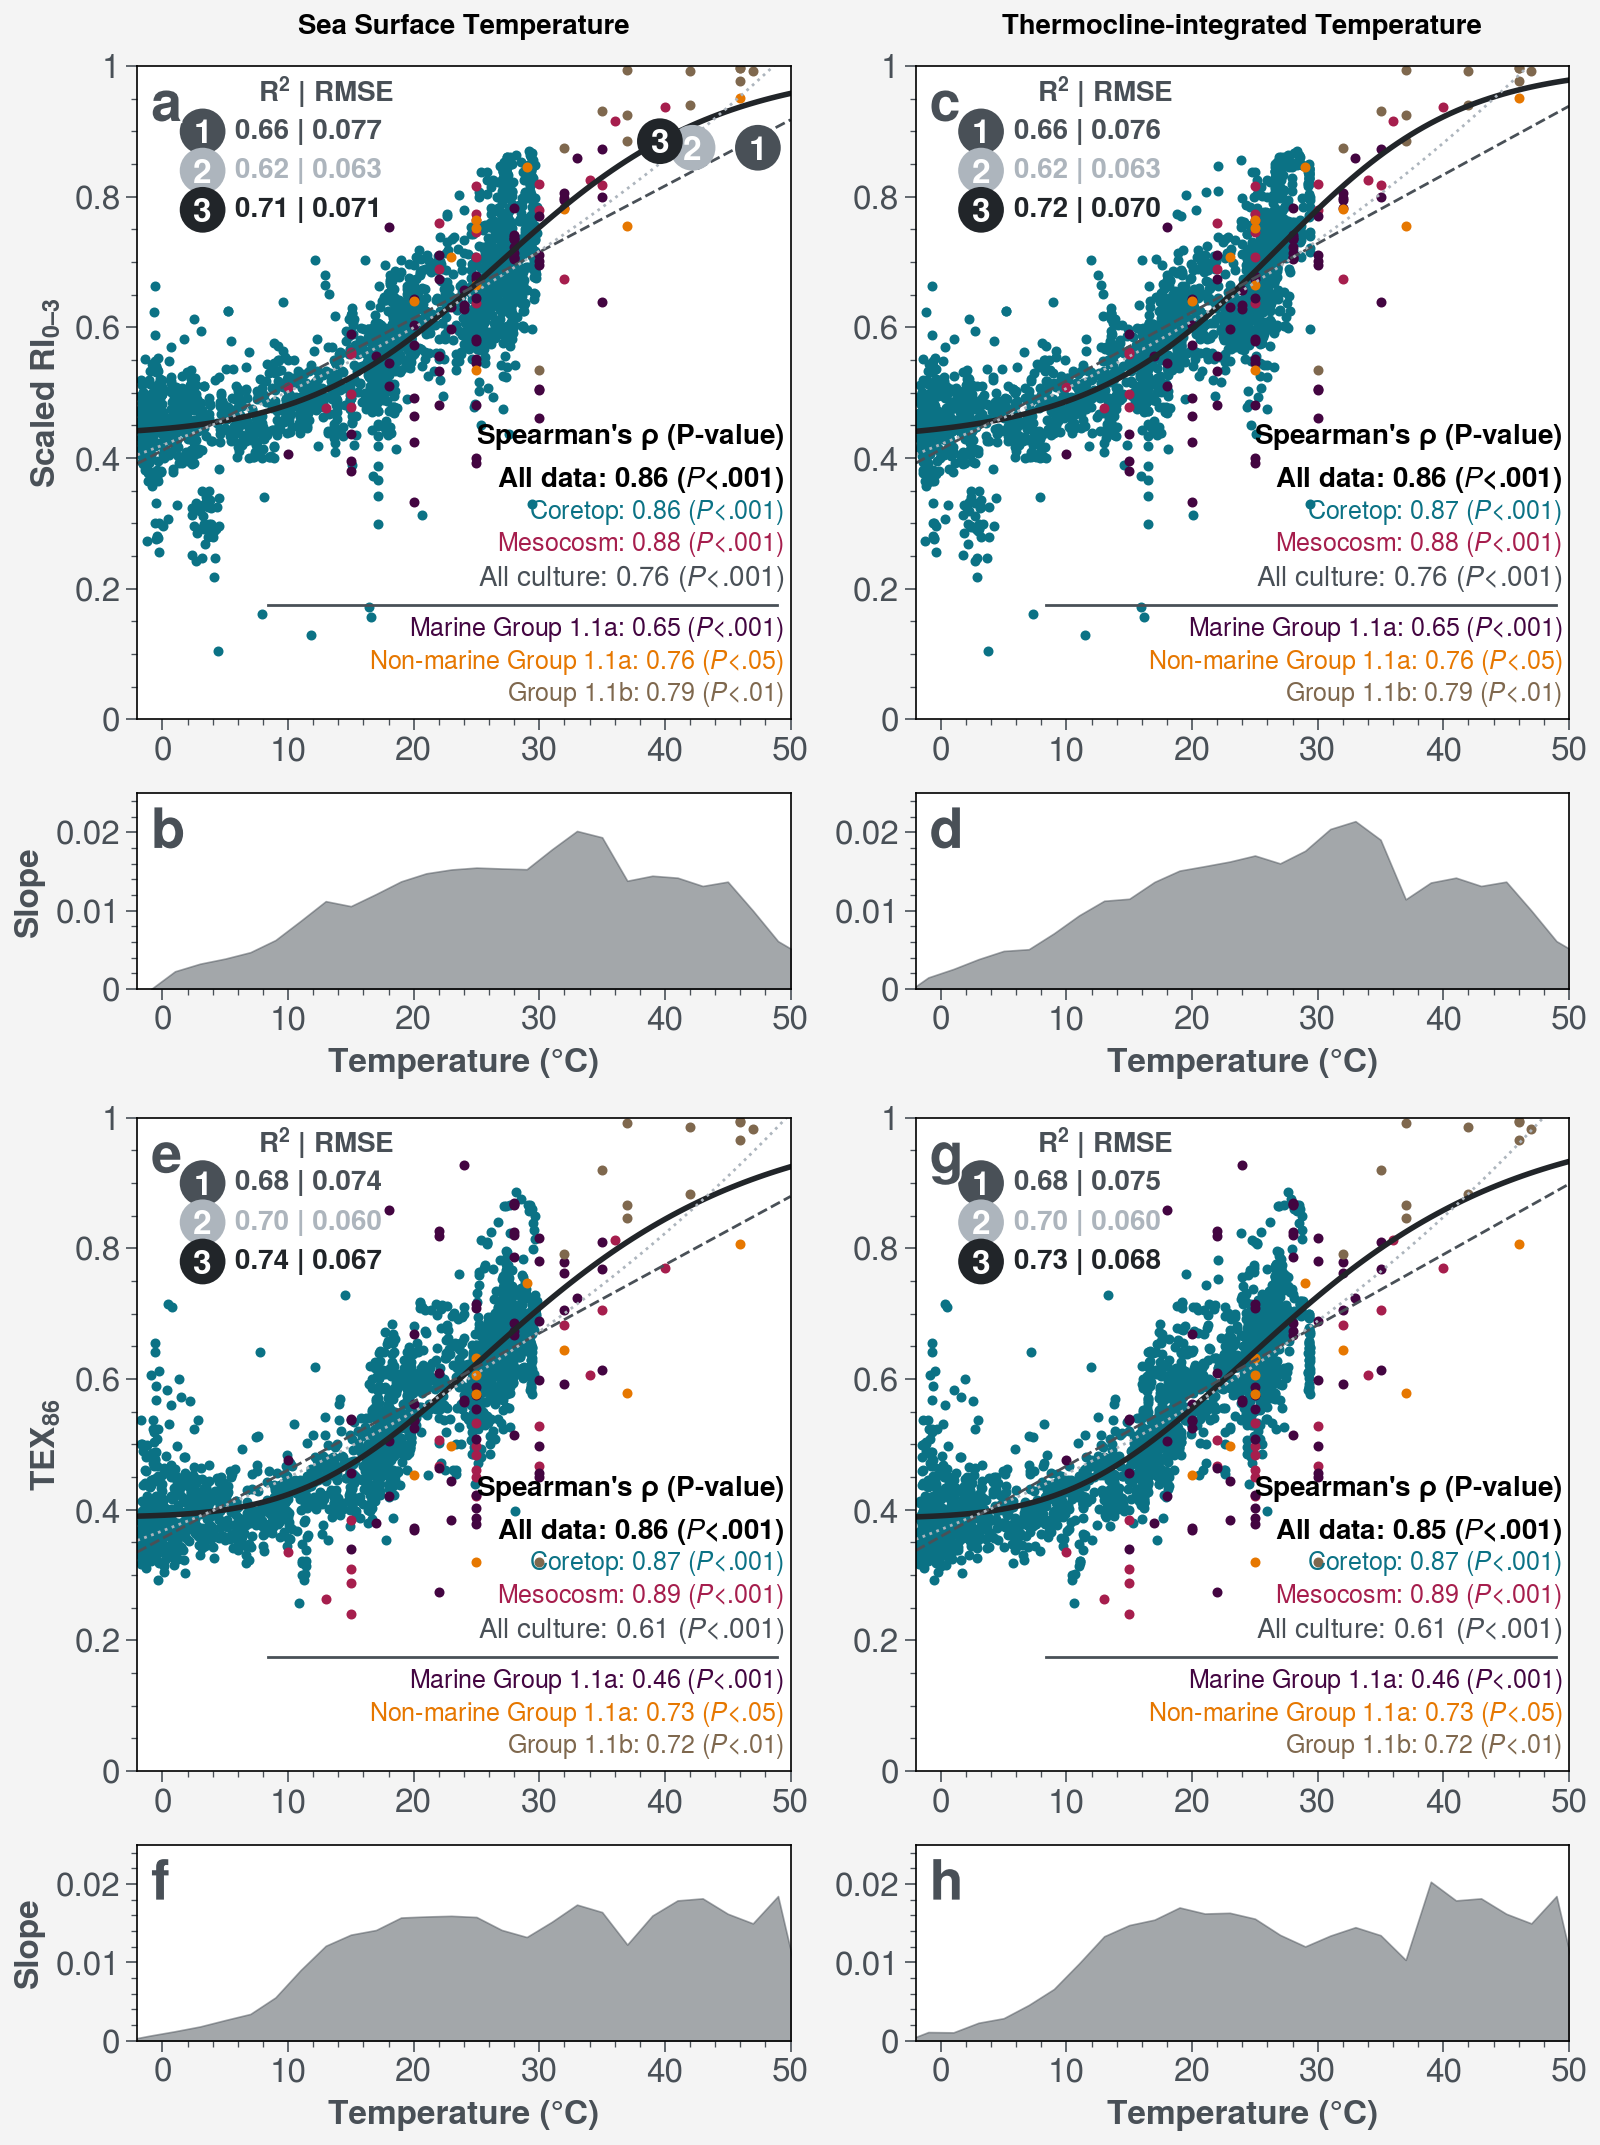

In [65]:
array = [
    [1,3],
    [2,4],
    [5,7],
    [6,8]
]
fig, axs = plot.subplots(array, width=8, share=False,
                         hratios=[1, 0.3, 1, 0.3])

axs.format(collabels=['Sea Surface Temperature', 'Thermocline-integrated Temperature'])

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag'] == False]
plot_data = plot_data.sort_values(
    'datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})
).reset_index(drop=True)

ordered_categories = ['Coretop', 'Mesocosm', 'Marine Group 1.1a', 'Non-marine Group 1.1a', 'Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(
    plot_data['organism_broadClass4'], categories=ordered_categories, ordered=True
)

ypos_below = [0.4-0.01, 0.35-0.01, 0.3-0.01, 0.25-0.01,
              0.2-0.03-0.01,0.15-0.03-0.01,0.1-0.03-0.01]

temp_params = ['SST', 't_sf2tc_avg']
y_params    = ['scaledRI_cren3', 'TEX86']
sel_color_dict = broadClass4_color_dict

for j, y_param in enumerate(y_params):                          # ← added colon; j=0→RI3, j=1→TEX
    scatter_row = j * 2                                          # 0 or 2
    slope_row   = j * 2 + 1                                     # 1 or 3

    for i, temp_param in enumerate(temp_params):
        grouped = plot_data.groupby('sorted_datatype')

        # ── Scatter + per-group stats ──────────────────────────────────────────
        for ii, (name, group) in enumerate(grouped):
            plot_x = group[temp_param]
            plot_y = group[y_param]
            axs[scatter_row, i].scatter(plot_x, plot_y, marker='.', label=name,
                                        c=sel_color_dict.get(name, 'gray7'))

            reg_data = group[[temp_param, y_param]].dropna(how='any')
            rho, pval = spearmanr(reg_data[temp_param], reg_data[y_param])
            pval_label = label_pvalues(pval)
            label_text = fr'{name}: {rho:.2f} ({pval_label})'
            ypos_ = ypos_below[ii+2] if ('1.1' in name) else ypos_below[ii+1]
            axs[scatter_row, i].text(0.99, ypos_, label_text,
                                   transform=axs[scatter_row, i].transAxes, clip_on=False,
                                   ha='right', va='top', fontsize=9,
                                   color=sel_color_dict.get(name, 'gray7'))

        # ── All-data stats (bold black) ────────────────────────────────────────
        reg_data_all = plot_data[[temp_param, y_param]].dropna(how='any')
        rho_all, pval_all = spearmanr(reg_data_all[temp_param], reg_data_all[y_param])
        pval_label_all = label_pvalues(pval_all)
        label_text_all = fr'All data: {rho_all:.2f} ({pval_label_all})'
        axs[scatter_row, i].text(0.99, ypos_below[0], label_text_all,
                               transform=axs[scatter_row, i].transAxes, clip_on=False,
                               ha='right', va='top', fontsize=10,
                               fontweight='bold', color='black')
        axs[scatter_row, i].text(0.99, ypos_below[0]+0.065, fr"Spearman's $\rho$ ($P$-value)",
                               transform=axs[scatter_row, i].transAxes, clip_on=False,
                               ha='right', va='top', fontsize=10,
                               fontweight='bold', color='black')

        # ── All-culture stats ──────────────────────────────────────────────────
        reg_data_cul_all = plot_data[plot_data['datatype']=='culture'][[temp_param, y_param]].dropna(how='any')
        rho_cul_all, pval_cul_all = spearmanr(reg_data_cul_all[temp_param], reg_data_cul_all[y_param])
        pval_label_cul_all = label_pvalues(pval_cul_all)
        label_text_cul_all = fr'All culture: {rho_cul_all:.2f} ({pval_label_cul_all})'
        axs[scatter_row, i].text(0.99, ypos_below[3], label_text_cul_all,
                               transform=axs[scatter_row, i].transAxes, clip_on=False,
                               ha='right', va='top', fontsize=10, color='gray7')
        axs[scatter_row, i].plot([0.2,0.98],[ypos_below[3]-0.065,ypos_below[3]-0.065], 
                                 color='gray7',lw=1,
                               transform=axs[scatter_row, i].transAxes)
        reg_data = plot_data[[temp_param, y_param]].dropna(how='any')

        # ── Sigmoid fit ────────────────────────────────────────────────────────
        popt, _ = curve_fit(generalized_logistic_model_fixed_upper,
                            reg_data[temp_param], reg_data[y_param],
                            p0=[20, 0.1, 0.1, 1],
                            bounds=([0,0,0,0.1],[50,0.5,0.5,5]))
        x_fit = np.linspace(-2, 50, 100)
        axs[scatter_row, i].plot(x_fit, generalized_logistic_model_fixed_upper(x_fit, *popt),
                                 color='gray9', linewidth=2, ls='-', label='Generalized Logistic Fit')
        y_resid = reg_data[y_param] - generalized_logistic_model_fixed_upper(reg_data[temp_param], *popt)
        r2   = 1 - np.sum(y_resid**2) / np.sum((reg_data[y_param] - reg_data[y_param].mean())**2)
        rmse = np.sqrt(np.mean(y_resid**2))
        axs[scatter_row, i].text(0.15, 0.78, fr'{r2:.2f} | {rmse:.3f}',
                                 transform=axs[scatter_row, i].transAxes,
                                 ha='left', va='center', c='gray9', fontsize=10, fontweight='bold')

        # ── Linear fit ────────────────────────────────────────────────────────
        popt_lin, _ = curve_fit(linear_model, reg_data[temp_param], reg_data[y_param], p0=[0.01, 0.1])
        axs[scatter_row, i].plot(x_fit, linear_model(x_fit, *popt_lin),
                                 color='gray7', linewidth=1, ls='--', label='Linear Fit')
        y_resid_lin = reg_data[y_param] - linear_model(reg_data[temp_param], *popt_lin)
        r2_lin   = 1 - np.sum(y_resid_lin**2) / np.sum((reg_data[y_param] - reg_data[y_param].mean())**2)
        rmse_lin = np.sqrt(np.mean(y_resid_lin**2))
        axs[scatter_row, i].text(0.15, 0.9, fr'{r2_lin:.2f} | {rmse_lin:.3f}',
                                 transform=axs[scatter_row, i].transAxes,
                                 ha='left', va='center', c='gray7', fontsize=10, fontweight='bold')

        # ── Log-linear fit ────────────────────────────────────────────────────
        popt_log, _ = curve_fit(linear_model, reg_data[temp_param],
                                np.log10(reg_data[y_param]), p0=[0.01, 0.1])
        axs[scatter_row, i].plot(x_fit, np.power(10, linear_model(x_fit, *popt_log)),
                                 color='gray5', linewidth=1, ls=':', label='Ln-Linear Fit')
        y_resid_log = np.log10(reg_data[y_param]) - linear_model(reg_data[temp_param], *popt_log)
        r2_log   = 1 - np.sum(y_resid_log**2) / np.sum((np.log10(reg_data[y_param]) - np.log10(reg_data[y_param]).mean())**2)
        rmse_log = np.sqrt(np.mean(y_resid_log**2))
        axs[scatter_row, i].text(0.15, 0.84, fr'{r2_log:.2f} | {rmse_log:.3f}',
                                 transform=axs[scatter_row, i].transAxes,
                                 ha='left', va='center', c='gray5', fontsize=10, fontweight='bold')
        
        axs[scatter_row, i].text(0.185,0.96, fr'R$^{2}$ | RMSE',
                transform=axs[scatter_row, i].transAxes,
                ha='left', va='center', c='gray7', fontsize=10, fontweight='bold')

    # ── Numbered legend circles (left column only, inside scatter panel) ──────
    for ax in axs[scatter_row, :]:
        for k in range(3):
            circle = plt.Circle((0.1, 0.90-(k*0.06)), 0.035,
                                 color=['gray7','gray5','gray9'][k], fill=True, lw=0,
                                 transform=ax.transAxes)
            ax.add_artist(circle)
            ax.text(0.1, 0.895-(k*0.06), k+1, transform=ax.transAxes,
                    ha='center', va='center', c='w', fontsize=12, fontweight='bold')
    
    if scatter_row == 0:
        circle_centers = [(0.95,0.87), (0.85,0.87), (0.8,0.88)]
        for k, (x, y) in enumerate(circle_centers):
            axs[scatter_row, 0].add_artist(
                plt.Circle((x, y+0.005), 0.035,
                        color=['gray7','gray5','gray9'][k], fill=True, lw=0,
                        transform=axs[scatter_row, 0].transAxes, zorder=3))
            axs[scatter_row, 0].text(x, y, k+1, transform=axs[scatter_row, 0].transAxes,
                                    ha='center', va='center', c='w',
                                    fontsize=12, fontweight='bold', zorder=4)

    # ── Sliding-window slopes ─────────────────────────────────────────────────
    temp_bin_centers = np.arange(-3, 53, 2)
    temp_bin_width   = 20
    slope_results = []
    for i, temp_param in enumerate(temp_params):
        for center in temp_bin_centers:
            bin_data = plot_data[
                (plot_data[temp_param] >= center - temp_bin_width/2) &
                (plot_data[temp_param] <  center + temp_bin_width/2)
            ][[temp_param, y_param]].dropna(how='any')
            if len(bin_data) >= 5:
                popt_bin, _ = curve_fit(linear_model, bin_data[temp_param], bin_data[y_param], p0=[0.01, 0.1])
                slope_results.append({'temp_param': temp_param,
                                      'temp_bin_center': center,
                                      'slope': popt_bin[0]})

    slope_results_df = pd.DataFrame(slope_results)
    for i, (name, group) in enumerate(slope_results_df.groupby('temp_param')):
        plot_x = group['temp_bin_center'].values
        plot_y = group['slope'].values
        axs[slope_row, i].fill_between(plot_x, plot_y, 0, where=plot_y >= 0,
                                       interpolate=True, color='gray7', alpha=0.5)



# ── Axis formatting ───────────────────────────────────────────────────────────
for j in range(len(y_params)):
    scatter_row = j * 2
    slope_row   = j * 2 + 1
    axs[scatter_row, :].format(grid=False, ylim=(0,1), xlim=(-2,50),
                               ylabel=u'TEX$_{86}$' if y_params[j]=='TEX86' else u'Scaled RI$_{0\u20133}$',
                               xlabel='')
    axs[slope_row,   :].format(xlabel='Temperature (°C)', ylabel='Slope',
                               xlim=(-2,50), ylim=(0., 0.025), grid=False)
    axs[scatter_row, 1].format(ylabel='')
    axs[slope_row,   1].format(ylabel='')

axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

fig.subplots_adjust(bottom=0.25)

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = f'figS8_functional_from_sst_thermoT_RI3_TEX86.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

SST: x0=27.960, b=0.440, k=0.120, v=0.972, n=1576
R² Sigmoid SST = 0.752; RMSE = 0.060


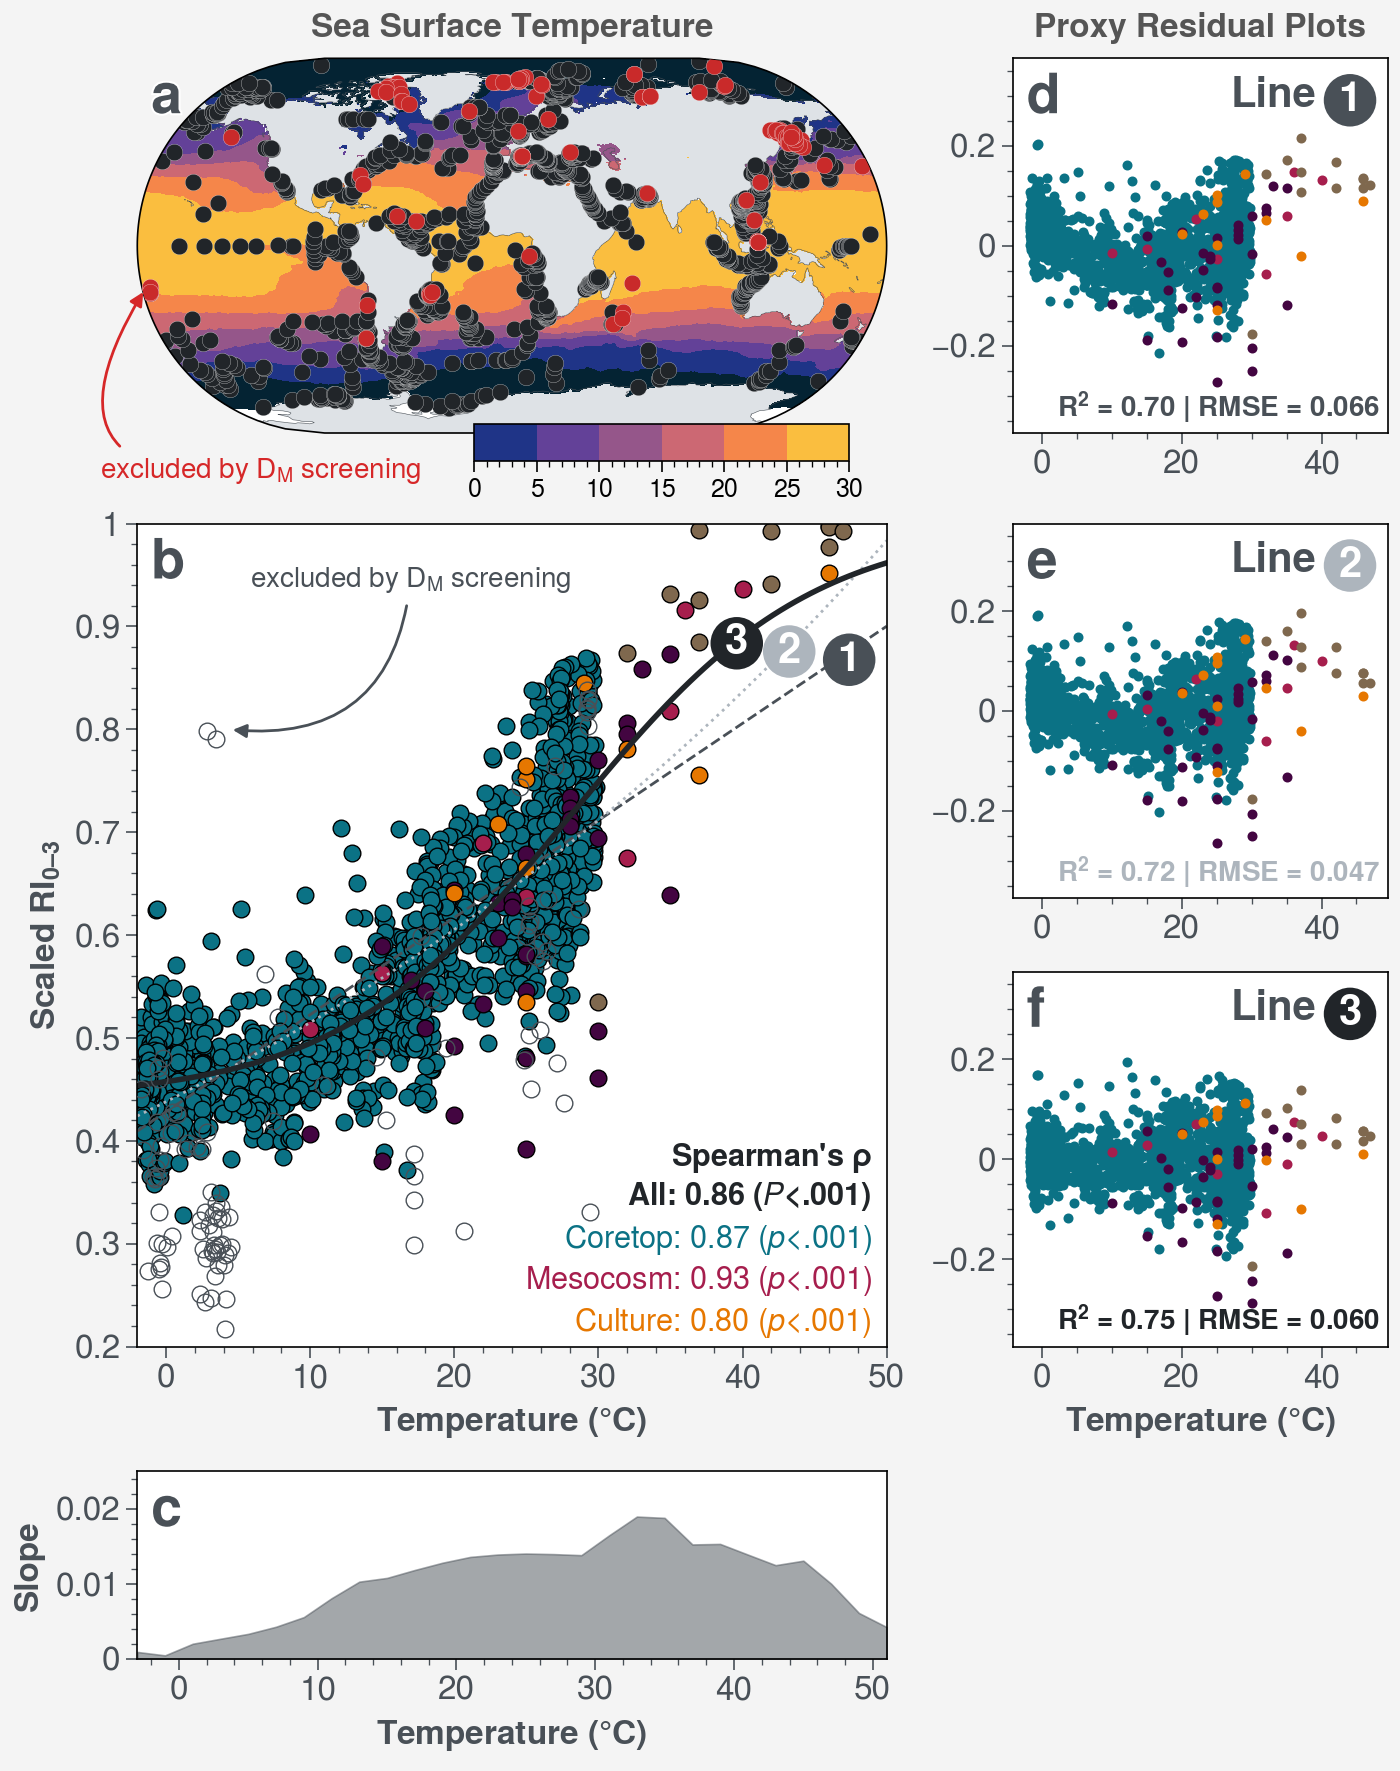

In [66]:
# 2) Build your data dict exactly as before
plot_data = gridded_combined_df
plot_data['no3_sf2tc_avg'] = [10 if n!='coretop' and np.isnan(x) else x 
                               for x,n in zip(plot_data['no3_sf2tc_avg'], plot_data['datatype'])]
plot_data = plot_data.dropna(subset=['TEX86','scaledRI_cren3','SST','t_sf2tc_avg','no3_sf2tc_avg'])
ordered_categories = ['Coretop','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['organism_broadClass4'], 
                                              categories=ordered_categories, ordered=True)
ordered_categories2 = ['coretop','mesocosm','culture']
plot_data['sorted_datatype2'] = pd.Categorical(plot_data['datatype'], 
                                              categories=ordered_categories2, ordered=True)
array = [
    [1,1,4],
    [2,2,5],
    [2,2,6],
    [3,3,0]
]
fig, axs = plot.subplots(
    array,
    width=7, share=False,
    proj={1:'eck3'},
    hratios=[1,1,1,0.5]
    )


axs[0].format(coast=True, land=True,
            landcolor='gray3', coastcolor='gray7',
            landzorder=0, coastzorder=1,
            coastlinewidth=0.2)

ax = axs[0]
m = T_da.isel(depth=0).plot(ax=ax, cmap='thermal',
                            add_colorbar=False,
                             levels=np.arange(0,31,5),
                            #  vmin=-2,vmax=30,
                            rasterized=True,
                            robust=True)
ax.format(title='')

cax = inset_axes(ax,
                 width="50%",  # width = 30% of parent axes
                 height="10%",  # height = 5% of parent axes
                 loc='lower center',
                 bbox_to_anchor=(0.2, -0.075, 1, 1), # (x, y, width, height)
                 bbox_transform=ax.transAxes,
                 borderpad=0)

cb = fig.colorbar(m, cax=cax, orientation='horizontal', 
            ticklocation='bottom', label='')

excluded_coretop = combined_df_raw[
    (combined_df_raw['datatype']=='coretop') &
    (combined_df_raw['TEXRI_cren3_mahalDist_low23ratio_outliers_manual']==True) &
    (combined_df_raw['lowAbundanceFlag']==False)
]

axs[0].scatter(plot_data['Longitude'], plot_data['Latitude'],
            c='gray9', marker='o', edgecolor='white', linewidth=0.1, zorder=2)
axs[0].scatter(excluded_coretop['Longitude'], excluded_coretop['Latitude'],
            c='red9', marker='o', edgecolor='white', linewidth=0.1, label='Excluded', zorder=3)

# --- y-positions below axs[2,i] ---
# Order: [0]=All data, [1]=coretop, [2]=mesocosm, [3]=culture,
#        [4]=Group 1.1a-marine (extra gap)
ypos_below = [-0.21, -0.28, -0.35, -0.42, 
              -0.84,-0.98,-1.12]

temp_param = 'SST'
y_param = 'scaledRI_cren3'
sel_color_dict = broadClass4_color_dict

grouped = plot_data.groupby('sorted_datatype')

reg_data = plot_data[[temp_param, y_param]].dropna(how='any')

# Linear
popt_lin, _ = curve_fit(linear_model, reg_data[temp_param], reg_data[y_param], p0=[0.01, 0.1])
axs[1].plot(x_fit, linear_model(x_fit, *popt_lin),
                color='gray7', linewidth=1, ls='--', label='Linear Fit')
y_resid_lin = reg_data[y_param] - linear_model(reg_data[temp_param], *popt_lin)
r2_lin = 1 - np.sum(y_resid_lin**2) / np.sum((reg_data[y_param] - reg_data[y_param].mean())**2)
rmse_lin = np.sqrt(np.mean(y_resid_lin**2))
axs[0,2].text(0.98, 0.02, fr'R$^2$ = {r2_lin:.2f} | RMSE = {rmse_lin:.3f}', 
            transform=axs[0,2].transAxes,
            ha='right', va='bottom', c='gray7', fontsize=10, fontweight='bold')

# Ln-Linear
popt_log, _ = curve_fit(linear_model, reg_data[temp_param],
                            np.log10(reg_data[y_param]), p0=[0.01, 0.1])
axs[1].plot(x_fit, np.power(10, linear_model(x_fit, *popt_log)),
                color='gray5', linewidth=1, ls=':', label='Ln-Linear Fit')
y_resid_log = np.log10(reg_data[y_param]) - linear_model(reg_data[temp_param], *popt_log)
r2_log = 1 - np.sum(y_resid_log**2) / np.sum((np.log10(reg_data[y_param]) - np.log10(reg_data[y_param]).mean())**2)
rmse_log = np.sqrt(np.mean(y_resid_log**2))
axs[1,2].text(0.98, 0.02, fr'R$^2$ = {r2_log:.2f} | RMSE = {rmse_log:.3f}', 
            transform=axs[1,2].transAxes,
            ha='right', va='bottom', c='gray5', fontsize=10, fontweight='bold')

# Sigmoid
popt, _ = curve_fit(generalized_logistic_model_fixed_upper,
                    reg_data[temp_param], reg_data[y_param],
                    p0=[20, 0.1, 0.1, 1],
                    bounds=([0,0,0,0.1],[50,0.5,0.5,5]))
print(f"{temp_param}: x0={popt[0]:.3f}, b={popt[1]:.3f}, k={popt[2]:.3f}, "
        f"v={popt[3]:.3f}, n={len(reg_data)}")
x_fit = np.linspace(-2, 50, 100)
axs[1].plot(x_fit, generalized_logistic_model_fixed_upper(x_fit, *popt),
            color='gray9', linewidth=2, ls='-', label='Generalized Logistic Fit')
y_resid = reg_data[y_param] - generalized_logistic_model_fixed_upper(reg_data[temp_param], *popt)
r2 = 1 - np.sum(y_resid**2) / np.sum((reg_data[y_param] - reg_data[y_param].mean())**2)
rmse = np.sqrt(np.mean(y_resid**2))
print(f"R² Sigmoid {temp_param} = {r2:.3f}; RMSE = {rmse:.3f}")
axs[2,2].text(0.98, 0.02, fr'R$^2$ = {r2:.2f} | RMSE = {rmse:.3f}', 
            transform=axs[2,2].transAxes,
            ha='right', va='bottom', c='gray9', fontsize=10, fontweight='bold')

# --- Scatter + per-group stats (annotations go below axs[2,i]) ---
axs[1].scatter(excluded_coretop[temp_param], excluded_coretop[y_param],
            facecolor='none',mec='gray7', marker='o', 
            linewidth=0.5, label='Excluded', zorder=3)
for ii, (name, group) in enumerate(grouped):
    plot_x = group[temp_param]
    plot_y = group[y_param]
    axs[1].scatter(plot_x, plot_y, marker='o', label=name,
                c=sel_color_dict.get(name, 'gray7'),
                    mec='k',mew=0.5)
            
    

    pred_y_lin = linear_model(plot_x,*popt_lin)
    y_res_lin = plot_y - pred_y_lin
    axs[0,2].scatter(plot_x, y_res_lin, marker='.', label=name,
                    c=sel_color_dict.get(name, 'gray7'))
    
    pred_y_log = linear_model(plot_x,*popt_log)
    y_res_log = plot_y - 10**pred_y_log
    axs[1,2].scatter(plot_x, y_res_log, marker='.', label=name,
                c=sel_color_dict.get(name, 'gray7'))
    
    pred_y_sigmoid = generalized_logistic_model_fixed_upper(plot_x,*popt)
    y_res_sigmoid = plot_y - pred_y_sigmoid
    axs[2,2].scatter(plot_x, y_res_sigmoid, marker='.', label=name,
                c=sel_color_dict.get(name, 'gray7'))

grouped2 = plot_data.groupby('sorted_datatype2')
for name, group in grouped2:
    spearmanrho, spearman_pval = spearmanr(group[temp_param], group[f'{y_param}'])
    pval_label = label_pvalues(spearman_pval)
    text = f'{name}: {spearmanrho:.2f} ({pval_label})'
    axs[1].text(0.98, 0.15-(0.05*list(grouped2.groups.keys()).index(name)), 
                text.capitalize(), transform=axs[1].transAxes,
                ha='right', va='top',c=datatype_color_dict.get(name,'gray7'),
                fontsize=11)
    
spearman_rho, spearman_pval = spearmanr(reg_data[temp_param], reg_data[f'{y_param}'])
pval_label = label_pvalues(spearman_pval)
text = r"Spearman's $\rho$"+f'\nAll: {spearman_rho:.2f} ({pval_label})'
axs[1].text(0.98, 0.25, text, transform=axs[1].transAxes,
    ha='right', va='top',c='gray9',
    fontsize=11,fontweight='bold',)
axs[1].format(xlim=(-2,50),ylim=(0.2,1))


# --- Numbered circles (stay inside axs[1,:]) ---
for k in range(3):
    
    circle = plt.Circle((0.4, 0.25-(k*0.1)), 0.035,
                            color=['gray7','gray5','gray9'][k], fill=True, lw=0,
                            transform=ax.transAxes)
    axs[1,0].add_artist(circle)
    axs[1,0].text(0.4, 0.245-(k*0.1), k+1, transform=axs[1,0].transAxes,
            ha='center', va='center', c='w', fontsize=14, fontweight='bold')

circle_centers = [(0.95,0.84), (0.87,0.85), (0.8,0.86)]
for k, (x, y) in enumerate(circle_centers):
    
    axs[1].text(x, y, k+1,
            fontweight='bold', fontsize=15,
            ha='center', va='center_baseline', color='white',
            transform=axs[1].transAxes,
            bbox=dict(facecolor=['gray7','gray5','gray9'][k], boxstyle='circle,pad=0.15',
                        edgecolor='none')
            )
    
    axs[k,2].text(0.90,0.90, k+1,
            fontweight='bold', fontsize=15,
            ha='center', va='center_baseline', color='white',
            transform=axs[k,2].transAxes,
            bbox=dict(facecolor=['gray7','gray5','gray9'][k], boxstyle='circle,pad=0.15',
                        edgecolor='none')
            )
    axs[k,2].text(0.81,0.90, 'Line',
            fontweight='bold', fontsize=15,
            ha='right',va='center',c='gray7',
            transform=axs[k,2].transAxes,)
    
# --- Sliding window slopes in axs[2,:] ---
temp_bin_centers = np.arange(-3, 53, 2)
temp_bin_width = 20
slope_results = []
for center in temp_bin_centers:
    bin_data = plot_data[
        (plot_data[temp_param] >= center - temp_bin_width/2) &
        (plot_data[temp_param] <  center + temp_bin_width/2)
    ][[temp_param, y_param]].dropna(how='any')
    if len(bin_data) >= 5:
        popt_bin, _ = curve_fit(linear_model, bin_data[temp_param], bin_data[y_param], p0=[0.01, 0.1])
        slope_results.append({'temp_param': temp_param, 'temp_bin_center': center, 'slope': popt_bin[0]})

slope_results_df = pd.DataFrame(slope_results)

plot_x = slope_results_df['temp_bin_center'].values
plot_y = slope_results_df['slope'].values
axs[3,0].fill_between(plot_x, np.full(len(plot_y),0), plot_y,
                    #   where=plot_y>=0,
                    #   interpolate=True, 
                      color='gray7', alpha=0.5)

# --- Formatting ---
fig.format(collabels=['Sea Surface Temperature', 'Proxy Residual Plots'])

# Manually style the collabel Text objects
for text in fig.texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
    text.set_color('#555555')  # equivalent to gray7
axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

axs[2,0].format(ylabel=u'Scaled RI$_{0\u20133}$',
                xlabel=r'Temperature ($\degree$C)')
axs[3,0].format(ylim=(0,0.025),
                ylabel=r'Slope',
                xlabel=r'Temperature ($\degree$C)')
axs[:,2].format(ylim=(-0.375,0.375),xlabel='')
axs[-2,2].format(xlabel=r'Temperature ($\degree$C)')

# Choose one of your excluded points coordinates [longitude, latitude]
target_point = [-178, -20]  # or pick a more prominent red dot
axs[0].annotate(
    r'excluded by $D_M$ screening',
    xy=target_point,
    xycoords=ccrs.PlateCarree()._as_mpl_transform(axs[0]),
    xytext=(-0.05, -0.1),        # inside the map panel, bottom-left area
    textcoords='axes fraction',
    ha='left', va='center',
    fontsize=10,
    color='#d62728',            # matplotlib red (replaces proplot 'red9')
    arrowprops=dict(
        arrowstyle='-|>',       # line with arrowhead pointing to the dot
        color='#d62728',
        linewidth=1,
        mutation_scale=10,       # smaller arrowhead
        connectionstyle='arc3,rad=-1',
    ),
    annotation_clip=False,      # prevents clipping at axes boundary
    zorder=10,
)

###### for main scatter plot
target_point = [0.12,0.75]  # or pick a more prominent red dot
axs[1].annotate(
    r'excluded by $D_M$ screening',
    xy=target_point,
    xycoords='axes fraction',
    xytext=(0.15,0.95),        # inside the map panel, bottom-left area
    textcoords='axes fraction',
    ha='left', va='top',
    fontsize=10,
    color='gray7',            # matplotlib red (replaces proplot 'red9')
    arrowprops=dict(
        arrowstyle='-|>',       # line with arrowhead pointing to the dot
        color='gray7',
        linewidth=1,
        mutation_scale=10,       # smaller arrowhead
        connectionstyle='arc3,rad=-0.5',
    ),
    annotation_clip=False,      # prevents clipping at axes boundary
    zorder=10,
)


fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig5_functional_from_sst_thermoT_{y_param}.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

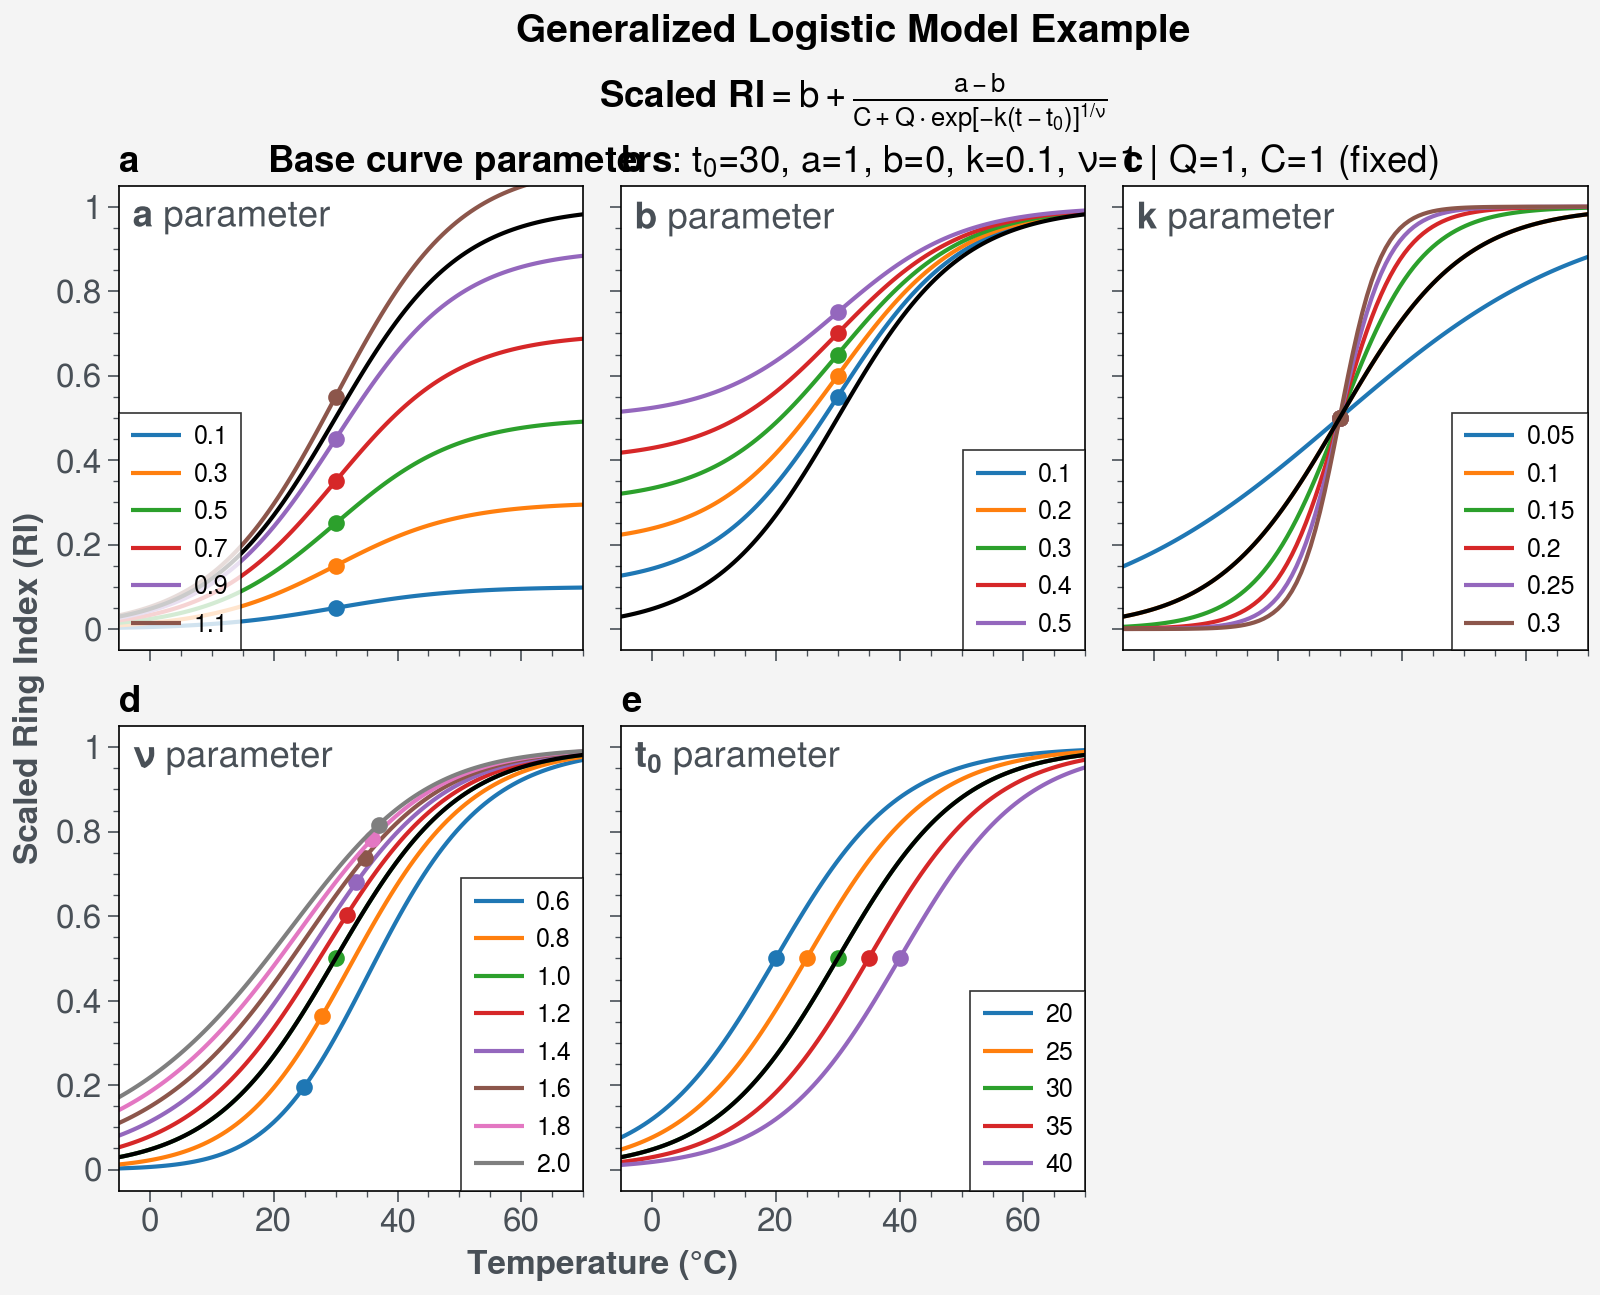

In [67]:
xx = np.linspace(-5,70,100)
sel_b = 0
sel_a = 1
sel_k = 0.1
sel_v = 1
sel_q = 1
sel_x0 = 30


fig, axs = plot.subplots(width=8,nrows=2,ncols=3,wspace=1.5)

### varying a --- upper asymptote
aa = np.arange(0.1, 1.2, 0.2)
for i, a in enumerate(aa):
    sel_c = plot.get_colors('tab10', len(aa))
    pred_y = generalized_logistic_model(
        b=sel_b,a=a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[0].plot(xx, pred_y, label=f'{a:.1f}', color=sel_c[i])
    axs[0].format(ultitle=r'$\bf{a}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[0].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='lower left', fontsize=10, ncols=1)

### varying b --- lower asymptote
bb = np.arange(0.1, 0.51, 0.1)
for i, b in enumerate(bb):
    sel_c = plot.get_colors('tab10', len(bb))
    pred_y = generalized_logistic_model(
        b=b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[1].plot(xx, pred_y, label=f'{b:.1f}', color=sel_c[i])
    axs[1].format(ultitle=r'$\bf{b}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[1].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)

axs.format(
    ylim=(-0.05, 1.05),
)

### varying k --- growth rate/slope
kk = np.arange(0.05, 0.31, 0.05)
for i, k in enumerate(kk):
    sel_c = plot.get_colors('tab10', len(kk))
    pred_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[2].plot(xx, pred_y, label=f'{k:.2g}', color=sel_c[i])
    axs[2].format(ultitle=r'$\bf{k}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[2].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)

### varying nu --- shape/asymmetry parameter
VV = np.arange(0.6,2.2,0.2)
VV_sorted = np.array(sorted(VV))

for i, v in enumerate(VV_sorted):
    sel_c = plot.get_colors('tab10', len(VV))
    pred_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[3].plot(xx, pred_y, label=f'{v:.1f}', color=sel_c[i])
    axs[3].format(ultitle=r'$\bf{\nu}$ parameter',titlesize=16,titlecolor='gray7',)
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_k, v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[3].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)

### Varying x0
X0 = np.arange(20, 41, 5)
for i, x0 in enumerate(X0):
    sel_c = plot.get_colors('tab10', len(X0))
    pred_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=x0
    )
    axs[4].plot(xx, pred_y, label=f'{x0}', color=sel_c[i])
    axs[4].format(ultitle=r'$\bf{t_{0}}$ parameter',titlesize=16,titlecolor='gray7',)

    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(x0, sel_k, sel_v)
    inflection_y = generalized_logistic_model(
        b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=x0
    )
    axs[4].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[4].get_legend_handles_labels()
axs[4].legend(handles=h, labels=l, loc='lower right', fontsize=10, ncols=1)


##############################################################

sel_b = 0
sel_a = 1
sel_k = 0.1
sel_v = 1
sel_q = 1
sel_x0 = 30
pred_y = generalized_logistic_model(
    b=sel_b,a=sel_a,k=sel_k,v=sel_v,Q=sel_q,C=1,
    x=xx,x0=sel_x0
)

axs.plot(xx, pred_y, label='Generalized Logistic Model', color='k')
eq_str = r'$\bf{Scaled\ RI}$'+r'$ = b + \frac{a - b}{C + Q \cdot \exp[-k(t - t_{0})]^{1/\nu}}$'
text_str = r'$\bf{Base\ curve\ parameters}$: t$_{0}$='+f'{sel_x0}, a={sel_a}, b={sel_b}, k={sel_k}, '+r"$\nu$"+f'={sel_v} | Q=1, C=1 (fixed)'



axs[1].set_title(f'{eq_str}\n{text_str}', fontsize=10)

plot.rc['abc']=False
axs.format(
    abc=False,
    fontsize=12,labelsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    suptitle=f'Generalized Logistic Model Example',
    # ylim=(0, 1),
    grid=False,
    suptitlesize=14,
    xlabel='Temperature (°C)',
    ylabel='Scaled Ring Index (RI)',
    
)
axs[-1].set_visible(False)
fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS8_generalized_logistic_model_example.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

Fitted parameters: [2.67787097e-07 4.56129087e-01 8.07077438e-02 1.33371787e-01]
1513 coretop samples used in regression
GDGT-2/3 ratio vs RI residuals:
Slope: -0.01, Intercept: 0.03, Spearman rho: -0.36, p-value: 2.953e-46, R²: 0.12
Optimal low_no3_threshold (RI-res): 10
Nitrate vs RI residuals (for no3 < optimal threshold):
Slope: -0.03, Intercept: 0.02, Spearman rho: -0.20, p-value: 1.221e-11, R²: 0.04

GDGT-2/3 vs NO3 correlation (NO3 < 10.00):
Spearman rho: -0.00, p-value: 9.002e-01, n=1121


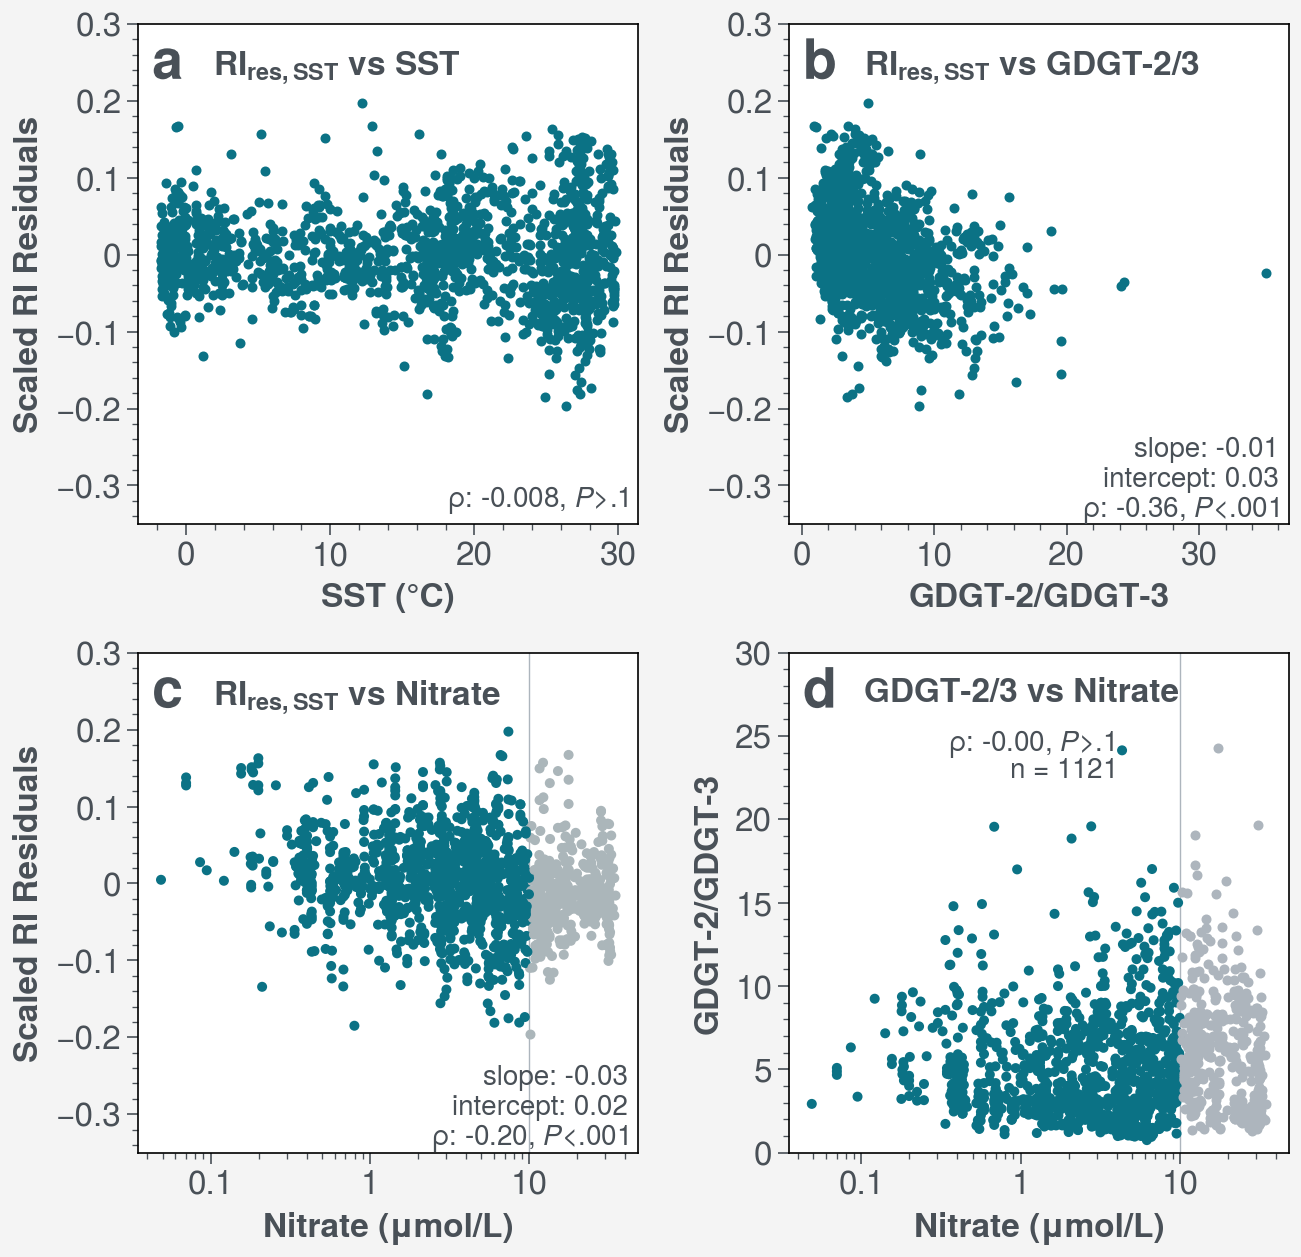

In [68]:
fig, axs = plot.subplots(ncols=2,nrows=2, share=0, )

x_param = 'SST'
y_param = 'scaledRI_cren3'
sel_no3_param = 'no3_sf2tc_woa23'
plot_data = gridded_combined_df.dropna(subset=[x_param, y_param, 'gdgt23ratio', sel_no3_param])
nonnan_idx = (~plot_data[y_param].isna()) & (~plot_data[x_param].isna())
XX = plot_data[x_param][nonnan_idx]
YY = plot_data[y_param][nonnan_idx]

popt, pcov = curve_fit(
    generalized_logistic_model_fixed_upper,
    XX, YY, 
    p0=[20, 0.1, 0.2, 1], 
    bounds=([0, 0, 0, 0.1], [50, 0.5, 5, 5])
)

print(f'Fitted parameters: {popt}')

plot_data['pred_'+y_param] = generalized_logistic_model_fixed_upper(plot_data[x_param], *popt)
plot_data[y_param+'_res'] = plot_data[y_param] - plot_data['pred_'+y_param]

####### plot RI_res vs t_sf2tc_avg ##########
ax = axs[0]
plot_x = plot_data[plot_data['datatype']=='coretop'][x_param]
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')
nonnan_idx = (~plot_data[plot_data['datatype']=='coretop'][x_param].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop'][x_param][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)
xx1 = np.linspace(-2,30,100).reshape(-1,1)
yy1 = reg_model.predict(xx1)
# ax.plot(xx1, yy1, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)
text_lists = [
    # f'slope: {slope:.2f}',
    # f'intercept: {intercept:.2f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.05-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)
    
text = 'RI$_{res, SST}$ vs SST'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='SST (°C)')
          
print(f'{len(reg_X)} coretop samples used in regression')

##############################
ax = axs[1]
plot_x = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio']
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')

nonnan_idx = (~plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)

xx2 = np.linspace(0,30,100).reshape(-1,1)
yy2 = reg_model.predict(xx2)
# ax.plot(xx2, yy2, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)
r2_score = reg_model.score(reg_X, reg_y)

print('GDGT-2/3 ratio vs RI residuals:')
print(f'Slope: {slope:.2f}, Intercept: {intercept:.2f}, Spearman rho: {spearman_rho:.2f}, p-value: {spearman_pval:.3e}, R²: {r2_score:.2f}')

text_lists = [
    f'slope: {slope:.2f}',
    f'intercept: {intercept:.2f}',
    r'$\rho$: '+f'{spearman_rho:.2f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, SST}$ vs GDGT-2/3'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='GDGT-2/GDGT-3',)
##########################

ax = axs[2]
plot_x = plot_data[plot_data['datatype']=='coretop'][sel_no3_param]
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']

from TEXAS import find_optimal_no3_threshold
optimal_no3_threshold, threshold_results = find_optimal_no3_threshold(
    plot_x.values, 
    plot_y.values,
    threshold_range=np.arange(0.01, 100, 0.01)
)

low_no3_threshold = 10 # np.round(optimal_no3_threshold,1)
print(f'Optimal low_no3_threshold (RI-res): {low_no3_threshold}')

m = ax.scatter(plot_x, plot_y, 
               c=plot_x, 
               marker='.',
               levels=[0,low_no3_threshold,20],
               cmap=[datatype_color_dict.get('coretop','gray7'),'gray5'],
               )
ax.format(xscale='log',xticks=[0.0001,0.001,0.01,0.1,1,10,100],xtickminor=True)

### regression between no3 and scaledRI_res for data with no3 < low_no3_threshold
reg_data_idx = plot_data[plot_data['datatype']=='coretop'][sel_no3_param].between(0,low_no3_threshold)
reg_X = plot_data[plot_data['datatype']=='coretop'][sel_no3_param][reg_data_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][reg_data_idx].values
reg_log10X = np.log10(reg_X)
nonnan_noninf_idx = ~np.isnan(reg_log10X).flatten() & ~np.isinf(reg_log10X).flatten() & ~np.isnan(reg_y).flatten() & ~np.isinf(reg_y).flatten()

reg_X = reg_X[nonnan_noninf_idx]
reg_y = reg_y[nonnan_noninf_idx]
reg_model_no3_orig = LinearRegression().fit(np.log10(reg_X), reg_y)
reg_y_pred = reg_model_no3_orig.predict(np.log10(reg_X))
xx4 = np.linspace(0.0001,low_no3_threshold,100).reshape(-1,1)
yy4 = reg_model_no3_orig.predict(np.log10(xx4))
# ax.plot(xx4, yy4, c='k', label=f'linear fit for no3 < {low_no3_threshold}')
ax.axvline(x=low_no3_threshold, color='gray5', ls='-', lw=0.5, zorder=0)

slope = reg_model_no3_orig.coef_[0]
intercept = reg_model_no3_orig.intercept_
spearman_rho, spearman_pval = spearmanr(np.log10(reg_X), reg_y)
pval_label = label_pvalues(spearman_pval)
r2_score = reg_model_no3_orig.score(np.log10(reg_X), reg_y)
print('Nitrate vs RI residuals (for no3 < optimal threshold):')
print(f'Slope: {slope:.2f}, Intercept: {intercept:.2f}, Spearman rho: {spearman_rho:.2f}, p-value: {spearman_pval:.3e}, R²: {r2_score:.2f}')

text_lists = [
    f'slope: {slope:.2f}',
    f'intercept: {intercept:.2f}',
    r'$\rho$: '+f'{spearman_rho:.2f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, SST}$ vs Nitrate'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='Nitrate (μmol/L)',
          xticks=[0.0001,0.001,0.01,0.1,1,10,100],
          xticklabels=['','0.001','0.01','0.1','1','10','100'],)

####### NEW PANEL: GDGT-2/3 vs NO3 correlation ##########
ax = axs[3]

# Get data for samples with NO3 < low_no3_threshold
corr_data_idx = plot_data[plot_data['datatype']=='coretop'][sel_no3_param].between(0, low_no3_threshold)
plot_x_corr = plot_data[plot_data['datatype']=='coretop'][sel_no3_param][corr_data_idx]
plot_y_corr = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][corr_data_idx]

# Color by nitrate threshold
m = ax.scatter(plot_x_corr, plot_y_corr, 
               c=plot_x_corr, 
               marker='.',
               levels=[0, low_no3_threshold, 20],
               cmap=[datatype_color_dict.get('coretop','gray7'), 'gray5'],
               )

# Also show excluded high-nitrate samples in gray
high_no3_idx = plot_data[plot_data['datatype']=='coretop'][sel_no3_param] > low_no3_threshold
plot_x_high = plot_data[plot_data['datatype']=='coretop'][sel_no3_param][high_no3_idx]
plot_y_high = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][high_no3_idx]
ax.scatter(plot_x_high, plot_y_high, c='gray5', marker='.')

ax.format(xscale='log', xticks=[0.0001,0.001,0.01,0.1,1,10,100], xtickminor=True)
ax.axvline(x=low_no3_threshold, color='gray5', ls='-', lw=0.5, zorder=0)

# Calculate correlation for low-nitrate samples only
nonnan_idx_corr = (~plot_x_corr.isna()) & (~plot_y_corr.isna())
corr_X = plot_x_corr[nonnan_idx_corr].values
corr_Y = plot_y_corr[nonnan_idx_corr].values

# Remove any inf values from log transformation
valid_idx = ~np.isinf(np.log10(corr_X))
corr_X = corr_X[valid_idx]
corr_Y = corr_Y[valid_idx]

# Compute correlation
spearman_rho_corr, spearman_pval_corr = spearmanr(np.log10(corr_X), corr_Y)
pval_label_corr = label_pvalues(spearman_pval_corr)

print(f'\nGDGT-2/3 vs NO3 correlation (NO3 < {low_no3_threshold:.2f}):')
print(f'Spearman rho: {spearman_rho_corr:.2f}, p-value: {spearman_pval_corr:.3e}, n={len(corr_X)}')

# Optional: fit regression line for visualization
reg_model_corr = LinearRegression().fit(np.log10(corr_X).reshape(-1,1), corr_Y)
xx_corr = np.linspace(corr_X.min(), low_no3_threshold, 100).reshape(-1,1)
yy_corr = reg_model_corr.predict(np.log10(xx_corr))
# ax.plot(xx_corr, yy_corr, c='k', lw=1.5, alpha=0.5)

text_lists_corr = [
    r'$\rho$: '+f'{spearman_rho_corr:.2f}, {pval_label_corr}',
    f'$n$ = {len(corr_X)}'
]
for i, text in enumerate(text_lists_corr):
    ax.text(0.65, 0.85-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='top', c='gray7', fontsize=10)

text = 'GDGT-2/3 vs Nitrate'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top', c='gray7', fontsize=12, fontweight='bold')
ax.format(xlabel='Nitrate (μmol/L)',
          ylabel='GDGT-2/GDGT-3',
          xticks=[0.0001,0.001,0.01,0.1,1,10,100],
          xticklabels=['','0.001','0.01','0.1','1','10','100'])

axs.format(
    abc=True, abcstyle='a', abcloc='ul', abcsize=20, abcweight='bold', abccolor='gray7',
    fontsize=12, labelsize=12,
    labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    xtickminor=True,
    grid=False,
)

# Different ylim for panels a-c vs panel d
axs[:3].format(ylim=(-0.35, 0.3), ylabel='Scaled RI Residuals')
axs[3].format(ylim=(0, 30))


fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS10_residuals_vs_covariates_coretop_only_SST.pdf'

fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [69]:
def find_optimal_no3_threshold(no3_values, residuals, threshold_range=np.arange(0.5, 5, 0.01), 
                                min_points=5):
    """
    Find NO3 threshold that maximizes negative correlation with residuals.
    
    Parameters:
    -----------
    no3_values : array
        Nitrate concentrations
    residuals : array  
        Residuals from temperature-only model
    threshold_range : array
        Range of thresholds to test
    min_points : int
        Minimum number of points required for correlation
        
    Returns:
    --------
    optimal_threshold : float
        Threshold that gives most negative Spearman rho
    results_df : DataFrame
        Full results for all tested thresholds
    """
    results = []
    
    for threshold in threshold_range:
        # Select data below threshold
        below_threshold = no3_values <= threshold
        no3_subset = no3_values[below_threshold]
        resid_subset = residuals[below_threshold]
        
        # Remove NaN/Inf
        valid_idx = (np.isfinite(no3_subset) & 
                     np.isfinite(resid_subset) & 
                     (no3_subset > 0))  # Ensure positive for log
        
        no3_valid = no3_subset[valid_idx]
        resid_valid = resid_subset[valid_idx]
        
        if len(no3_valid) >= min_points:
            rho, pval = spearmanr(np.log10(no3_valid), resid_valid)
            results.append({
                'threshold': threshold,
                'spearman_rho': rho,
                'spearman_pval': pval,
                'n_points': len(no3_valid)
            })
    
    results_df = pd.DataFrame(results)
    optimal_threshold = results_df.loc[results_df['spearman_rho'].idxmin(), 'threshold']
    
    return optimal_threshold, results_df

In [70]:
from TEXAS.models.multivariate import find_optimal_no3_threshold

In [71]:
basins = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50
crtp_idx = gridded_combined_df['datatype']=='coretop'
lon = gridded_combined_df.loc[crtp_idx, 'Longitude'].values
lat = gridded_combined_df.loc[crtp_idx, 'Latitude'].values

# Convert to [-180, 180] if needed
lon = np.where(lon > 180, lon - 360, lon)

# Wrap as xarray with a shared 'points' dimension — critical for unstructured data
lon_xr = xr.DataArray(lon, dims='points')
lat_xr = xr.DataArray(lat, dims='points')

# Now mask correctly treats each (lon, lat) pair as one point
region_ids = basins.mask(lon_xr, lat_xr).values  # shape: (n_points,)

# Correct API — parallel arrays, not region objects
id_to_name   = dict(zip(basins.numbers, basins.names))
id_to_abbrev = dict(zip(basins.numbers, basins.abbrevs))

# Then map as before
id_series = pd.Series(region_ids.astype(int), index=gridded_combined_df.loc[crtp_idx].index)

gridded_combined_df.loc[crtp_idx, 'ocean_region_id']     = id_series.values
gridded_combined_df.loc[crtp_idx, 'ocean_region']        = id_series.map(id_to_name)
gridded_combined_df.loc[crtp_idx, 'ocean_region_abbrev'] = id_series.map(id_to_abbrev)

# Sanity check
print(f"Unassigned (-1): {(id_series == -1).sum()} / {len(id_series)}")
print(gridded_combined_df.loc[crtp_idx, ['Longitude','Latitude','ocean_region']].head(10))

Unassigned (-1): 0 / 1513
   Longitude  Latitude ocean_region
0     -40.45    -77.80  Weddell Sea
1    -158.27    -77.47     Ross Sea
2     -45.41    -77.02  Weddell Sea
3     -35.43    -76.64  Weddell Sea
4     -33.93    -76.38  Weddell Sea
5     -54.18    -76.01  Weddell Sea
6     -33.65    -76.11  Weddell Sea
7     -29.08    -75.95  Weddell Sea
8     -27.68    -75.97  Weddell Sea
9     -60.00    -74.98  Weddell Sea


In [72]:
def ols_fit(x, y):                                                                                                                              
    """Linear OLS. Returns slope, intercept, 1σ SE of slope, 68% CI, R²."""                                                                     
    from scipy.stats import linregress                                                                                                          
    res     = linregress(x, y)                                                                                                                  
    slope   = float(res.slope)                                                                                                                  
    inter   = float(res.intercept)                                                                                                              
    se      = float(res.stderr)          # 1σ SE of slope
    r2      = float(res.rvalue ** 2)                                                                                                            
    return dict(
        slope=slope, inter=inter, se=se,                                                                                                        
        ci68_lo=slope - se, ci68_hi=slope + se,
        r2=r2,                                                                                                                                  
    )           
                                                                                                                                                

def odr_fit_cal(x, y, slope0, inter0, sx, sy):                                                                                                  
    """ODR linear regression with per-point x/y uncertainties.
    sx: SE of x  (log10-scale for NO3/log predictors)
    sy: SE of y  (RI residuals — typically ~0.03)                                                                                               
    Returns slope, intercept, 1σ SE of slope, 68% CI.                                                                                           
    """                                                                                                                                         
    from scipy.odr import ODR, Model, RealData                                                                                                  
    def _linear(b, x_): return b[0] * x_ + b[1]                                                                                                 
    result  = ODR(                                                                                                                              
        RealData(x, y, sx=sx, sy=sy),
        Model(_linear),                                                                                                                         
        beta0=[slope0, inter0],
    ).run()
    slope   = float(result.beta[0])
    inter   = float(result.beta[1])                                                                                                             
    se      = float(result.sd_beta[0])   # 1σ SE of slope
    return dict(                                                                                                                                
        slope=slope, inter=inter, se=se,
        ci68_lo=slope - se, ci68_hi=slope + se,                                                                                                 
    )
    
def round_to_n_sf(x, n):
    """Round x to n significant figures."""
    if x == 0:                              
        return 0                        
    import math
    magnitude = math.floor(math.log10(abs(x)))                                                                                                  
    return round(x, -int(magnitude) + (n - 1))

# ─── Joint ODR — matches Bayesian framework ───────────────────────────────────                                                                                                   
# Fits T-curve (t0, k, b, v) + β_NO3 simultaneously on ALL coretop sites.                                                                                                          
# CV-gating: sites with SE/NO3 > cv_max are treated as exact (sx=1e6),                                                                                                             
# matching build_fwd_data(no3_eiv_cv_max=0.3). T is fixed (sx_T≈0).                                                                                                                
def joint_odr_fit(T, RI, NO3, NO3_se_lin, p0_curve, beta_init,                                                                                                                     
                no3_threshold=1.0, cv_max=0.3, sy=0.05):                                                                                                                         
    from scipy.odr import ODR, Model, RealData                                                                                                                                     
                                                                                                                                                                                    
    in_range = (NO3 > 0) & (NO3 < no3_threshold) & np.isfinite(NO3)                                                                                                                
    cv       = np.where(NO3 > 0, NO3_se_lin / NO3, np.inf)                                                                                                                         
    eiv_mask = in_range & (cv <= cv_max)                                                                                                                                           
                                                                                                                                                                                    
    log10_no3 = np.where(in_range, np.log10(np.clip(NO3, 1e-9, None)), 0.0)                                                                                                        
    sx_no3    = np.where(eiv_mask, NO3_se_lin / (NO3 * np.log(10)), 1e6)                                                                                                           
    sx_no3    = np.clip(sx_no3, 1e-9, 1e6)                                                                                                                                         
                                                                                                                                                                                    
    def _model(p, x):                                                                                                                                                              
        t0, k, b, v, beta = p                                                                                                                                                      
        return b + (1-b) / (1 + np.exp(-k*(x[0]-t0)))**(1/v) + beta*x[1]                                                                                                           
                                                                                                                                                                                    
    result = ODR(                                                                                                                                                                  
        RealData(np.vstack([T, log10_no3]), RI,                                                                                                                                    
                sx=np.vstack([np.full(len(T), 1e-6), sx_no3]),                                                                                                                    
                sy=np.full(len(T), sy)),                                                                                                                                          
        Model(_model),                                                                                                                                                             
        beta0=list(p0_curve) + [beta_init],                                                                                                                                        
    ).run()                                                                                                                                                                        
                
    t0, k, b, v, beta = result.beta                                                                                                                                                
    _, _, _, _, se_beta = result.sd_beta
                                                                                                                                                                                    
    # residuals from jointly-estimated T-curve (for plotting)                                                                                                                      
    ri_pred = b + (1-b) / (1 + np.exp(-k*(T-t0)))**(1/v)                                                                                                                           
    ri_res  = RI - ri_pred                                                                                                                                                         
                
    # effective intercept for the NO3 line on the residual plot                                                                                                                    
    sub = in_range
    ic  = np.mean(ri_res[sub] - beta * log10_no3[sub]) if sub.sum() > 0 else 0.0                                                                                                   
                                                                                                                                                                                    
    return dict(                                                                                                                                                                   
        beta=beta, se=se_beta,                                                                                                                                                     
        ci68_lo=beta-se_beta, ci68_hi=beta+se_beta,
        intercept=ic, ri_res=ri_res,                                                                                                                                               
        n_eiv=int(eiv_mask.sum()), n_exact=int((in_range & ~eiv_mask).sum()),                                                                                                      
    )       
    
def propagate_se(
    se_values: np.ndarray,
    param_values: np.ndarray,
    se_is_log10: bool,
    se_floor: float = 1e-6,
) -> np.ndarray:
    """
    Propagate standard error, optionally converting from linear to log₁₀ scale.

    Parameters
    ----------
    se_values    : array of SE on the LINEAR scale (e.g. µmol/L for NO₃).
    param_values : array of the corresponding parameter values (linear scale).
    se_is_log10  : if True, apply delta-method propagation:
                       SE_log10 = SE_linear / (x · ln(10))
                   if False, return se_values unchanged.
    se_floor     : minimum SE returned (prevents division-by-zero artefacts).

    Returns
    -------
    se_out : array of SE in the requested scale, clipped to [se_floor, ∞).

    Notes
    -----
    Delta-method derivation:
        y = log₁₀(x)  →  dy/dx = 1 / (x · ln 10)
        SE_y ≈ SE_x · |dy/dx| = SE_x / (x · ln 10)

    Parallel to Stan EIV block where sd_no3_crtp (linear) enters a normal
    measurement model and the forward model applies log₁₀(true_no3).
    """
    se_values   = np.asarray(se_values,   dtype=float)
    param_values = np.asarray(param_values, dtype=float)

    if not se_is_log10:
        return np.clip(se_values, se_floor, None)

    # Delta method: SE_log10 = SE_linear / (x · ln 10)
    with np.errstate(divide="ignore", invalid="ignore"):
        se_out = se_values / (np.abs(param_values) * np.log(10))

    # Replace non-finite results (x ≈ 0, NaN SE) with a large fallback SE
    # so those sites exert minimal leverage in ODR rather than crashing it.
    bad = ~np.isfinite(se_out) | (se_out <= 0)
    se_out[bad] = 1.0        # large → near-zero weight in ODR

    return np.clip(se_out, se_floor, None)       

                     

In [73]:
# # ═════════════════════════════════════════════════════════════════════════════
# # CONFIG
# # ═════════════════════════════════════════════════════════════════════════════
# x_param          = 'SST'
# y_param          = 'scaledRI_cren3'
# scaledRI_se      = 0.03
# show_xerr        = True
# show_sig_regions = False
# NO3_SE_FLOOR     = 0.0001
# NO3_SE_CAP       = 1.0

# MODES = {
#     'G23': dict(
#         sel_nonthermal_param    = 'gdgt23ratio',
#         sel_nonthermal_param_se = 'gdgt23ratio_se',  # SE in log10 space
#         param_threshold         = None,
#         threshold_direction     = 'lower',
#         param_label             = r'GDGT-2/3 ratio',
#         se_is_log10             = False,   # SE column is in log10 units
#         log_x                   = False,  # fit & plot in LINEAR G23 space
#         stan_param_name         = 'beta_G23_crtp',
#         pt_color                = 'orange7',
#     ),
#     'NO3': dict(
#         sel_nonthermal_param    = 'no3_sf2tc_avg',
#         sel_nonthermal_param_se = 'thermoNO3_se',    # SE in linear µmol/L
#         param_threshold         = 1,
#         threshold_direction     = 'upper',
#         param_label             = r'NO$_3^-$ (μmol/L)',
#         se_is_log10             = False,  # SE column is in linear units → delta method
#         log_x                   = True,   # fit in log10(NO3) space, log x-axis
#         stan_param_name         = 'beta_NO3_crtp',
#         pt_color                = 'cyan9',
#     ),
# }

# # ─── helpers ─────────────────────────────────────────────────────────────────
# def _threshold_label(param, threshold, direction):
#     if threshold is None:
#         return f'{param} > 0'
#     return f'{param} ≥ {threshold}' if direction == 'lower' else f'{param} ≤ {threshold}'

# def compute_xerr(x_vals, se_raw, se_is_log10, log_x):
#     if log_x:
#         # log x-axis: asymmetric bars in linear space from log10-space SE
#         se_log10 = se_raw if se_is_log10 else se_raw / (x_vals * np.log(10))
#         se_log10 = np.clip(se_log10, NO3_SE_FLOOR, NO3_SE_CAP)
#         xerr_lo  = x_vals - 10 ** (np.log10(x_vals) - se_log10)
#         xerr_hi  = 10 ** (np.log10(x_vals) + se_log10) - x_vals
#     else:
#         # linear x-axis: symmetric bars in linear space
#         se_lin  = se_raw * x_vals * np.log(10) if se_is_log10 else se_raw
#         se_lin  = np.clip(se_lin, 0, None)
#         xerr_lo = se_lin
#         xerr_hi = se_lin
#     return xerr_lo, xerr_hi

# def _odr_sx(raw_se, x_lin, se_is_log10, log_x):
#     """
#     Return SE in the same space as the ODR x-variable.
#       log_x=True  → ODR x = log10(param) → need log10-space SE
#       log_x=False → ODR x = param        → need linear-space SE

#     se_is_log10 describes the SE *column*:
#       True  → column is already log10-space SE
#       False → column is linear-space SE
#     """
#     if log_x:
#         # need log10-space SE
#         if se_is_log10:
#             return raw_se                          # already log10
#         else:
#             return raw_se / (x_lin * np.log(10))  # delta method → log10
#     else:
#         # need linear-space SE
#         if se_is_log10:
#             return raw_se * x_lin * np.log(10)    # inverse delta method → linear
#         else:
#             return raw_se                          # already linear

# # ═════════════════════════════════════════════════════════════════════════════
# # Step 0: sigmoid fit + residuals — computed ONCE, shared by both modes
# # ═════════════════════════════════════════════════════════════════════════════
# plot_data  = gridded_combined_df.copy()
# ct_mask    = plot_data['datatype'] == 'coretop'
# valid_mask = plot_data[y_param].notna() & plot_data[x_param].notna()

# XX = plot_data.loc[valid_mask & ct_mask, x_param].values
# YY = plot_data.loc[valid_mask & ct_mask, y_param].values

# popt     = res_hier['popt_T']           # coretop re-optimized T parameters
# r2_therm = res_hier['r2']['base']       # R²_thermal from the same fit
# sy_resid = scaledRI_se * np.sqrt(max(0.0, 1.0 - r2_therm))
# print(f'Using res_hier popt_T: {popt}')
# print(f'Thermal R² (coretop) = {r2_therm:.3f}  →  ODR sy = {sy_resid:.4f}')
# plot_data['pred_' + y_param] = generalized_logistic_model_fixed_upper(
#     plot_data[x_param], *popt)


# plot_data[y_param + '_res']  = plot_data[y_param] - plot_data['pred_' + y_param]
# coretop_data = plot_data[ct_mask].copy()

# # ═════════════════════════════════════════════════════════════════════════════
# # Steps 1–7: per-mode computation → store in `results`
# # ═════════════════════════════════════════════════════════════════════════════
# results = {}

# for mode, cfg in MODES.items():
#     sel_param    = cfg['sel_nonthermal_param']
#     sel_param_se = cfg['sel_nonthermal_param_se']
#     threshold    = cfg['param_threshold']
#     direction    = cfg['threshold_direction']
#     se_is_log10  = cfg['se_is_log10']
#     log_x        = cfg['log_x']
#     thr_label    = _threshold_label(sel_param, threshold, direction)

#     # Step 1: threshold filter
#     tmask = coretop_data[sel_param] > 0
#     if threshold is not None:
#         tmask &= (coretop_data[sel_param] <= threshold
#                   if direction == 'upper'
#                   else coretop_data[sel_param] >= threshold)
#     sub_global = coretop_data[tmask]
#     print(f'\n[{mode}] {thr_label} → n = {len(sub_global)}')

#     # Step 2: per-region Spearman (always in log10 — monotonic so ranks identical)
#     region_stats = []
#     for region, grp in sub_global.groupby('ocean_region'):
#         sub = grp[[sel_param, y_param + '_res']].dropna()
#         if len(sub) < 10:
#             continue
#         rho, pval = spearmanr(np.log10(sub[sel_param]), sub[y_param + '_res'])
#         region_stats.append(dict(region=region, rho=rho, pval=pval, n=len(sub),
#                                  max_param=sub[sel_param].max()))
#     region_stats_df = pd.DataFrame(region_stats).sort_values('rho')
#     print('  Per-region Spearman:\n' +
#           region_stats_df[['region','rho','pval','n']].to_string(index=False))

#     # Step 3: region selection
#     if show_sig_regions:
#         sig_neg_regions  = region_stats_df[
#             (region_stats_df['rho'] < 0) & (region_stats_df['pval'] < 0.1)
#         ]['region'].tolist()
#         region_color_map = dict(zip(sig_neg_regions,
#                                     plot.get_colors('tab10', N=len(sig_neg_regions))))
#         region_label     = r'$\rho$ < 0, $p$ < 0.1'
#     else:
#         sig_neg_regions  = []
#         region_color_map = {}
#         region_label     = 'all data'

#     # Step 6b: global OLS + ODR
#     global_data = sub_global.dropna(subset=[sel_param, y_param + '_res'])
#     if sel_param_se in sub_global.columns:
#         global_data = global_data.dropna(subset=[sel_param_se])

#     x_lin_all = global_data[sel_param].values           # always linear
#     ri_g      = global_data[y_param + '_res'].values

#     # nt_g: the x-variable actually passed to OLS/ODR
#     #   G23 (log_x=False): raw ratio  — slope units: RI / G23
#     #   NO3 (log_x=True ): log10(NO3) — slope units: RI / log10(µmol/L)
#     nt_g = np.log10(x_lin_all) if log_x else x_lin_all

#     # se_g: SE in the same space as nt_g, for ODR sx
#     if sel_param_se in global_data.columns:
#         raw_se = global_data[sel_param_se].values.astype(float)
#         se_g   = _odr_sx(raw_se, x_lin_all, se_is_log10, log_x)
#     else:
#         se_g = np.full(len(global_data), 0.1)
#     se_g = np.clip(se_g, NO3_SE_FLOOR, NO3_SE_CAP)

#     # ri_g is already Scaled RI residuals w.r.t. res_hier popt_T (Step 0)
#     # nt_g is the predictor in the correct space (linear G23 or log10 NO3)
#     # Both OLS and ODR operate on the same (nt_g, ri_g) — fully consistent
#     ols_g = ols_fit(nt_g, ri_g)

#     _odr_key = 'odr_g23' if mode == 'G23' else 'odr_no3'
#     _odr_dict = res_hier[_odr_key]   # two-step ODR already computed in run_variance_partitioning
#     if _odr_dict is not None:
#         _odr_slope = _odr_dict['slope']
#         _odr_se    = _odr_dict['se']
#         _odr_inter = float(np.mean(ri_g) - _odr_slope * np.mean(nt_g))
#         odr_g = dict(slope=_odr_slope, inter=_odr_inter, se=_odr_se,
#                      ci68_lo=_odr_slope - _odr_se, ci68_hi=_odr_slope + _odr_se)
#     else:
#         odr_g = dict(slope=ols_g['slope'], inter=ols_g['inter'], se=ols_g['se'],
#                      ci68_lo=ols_g['ci68_lo'], ci68_hi=ols_g['ci68_hi'])

#     print(f'  [two-step OLS] slope={ols_g["slope"]:.4f} ± {ols_g["se"]:.4f}  '
#           f'R²={ols_g["r2"]:.3f}')
#     print(f'  [two-step ODR] slope={odr_g["slope"]:.4f} ± {odr_g["se"]:.4f}')

#     prior_mu    = round_to_n_sf(ols_g['slope'],   2)
#     prior_sigma = round_to_n_sf(ols_g['se'],      2)
#     prior_cons  = round_to_n_sf(ols_g['se'] * 2, 2)

#     rho_g, pval_g = spearmanr(np.log10(x_lin_all), ri_g)
#     pval_lbl_g    = label_pvalues(pval_g)
#     print(f'  [from res_hier] OLS slope={_ols_slope:.4f} ± {_ols_se:.4f}')
#     print(f'  [from res_hier] ODR slope={_odr_slope:.4f} ± {_odr_se:.4f}')

#     prior_mu    = round_to_n_sf(_ols_slope,       2)
#     prior_sigma = round_to_n_sf(_ols_se,          2)
#     prior_cons  = round_to_n_sf(_ols_se * 2,      2)

#     # Regression line arrays:
#     #   G23 (log_x=False): xx_lin_g spans linear G23; yy = slope*x_lin + inter
#     #   NO3 (log_x=True ): xx_lin_g spans linear NO3; yy = slope*log10(x) + inter
#     #   In both cases ax.plot(xx_lin_g, yy) is correct — G23 on linear axis,
#     #   NO3 on log axis (matplotlib handles the log scaling).
#     if log_x:
#         xx_log_g = np.linspace(nt_g.min(), nt_g.max(), 200)
#         xx_lin_g = 10 ** xx_log_g
#         yy_ols_g = ols_g['slope'] * xx_log_g + ols_g['inter']
#         yy_odr_g = odr_g['slope'] * xx_log_g + odr_g['inter']
#     else:
#         xx_lin_g = np.linspace(nt_g.min(), nt_g.max(), 200)
#         yy_ols_g = ols_g['slope'] * xx_lin_g + ols_g['inter']
#         yy_odr_g = odr_g['slope'] * xx_lin_g + odr_g['inter']

#     results[mode] = dict(
#         cfg=cfg, thr_label=thr_label, region_label=region_label,
#         sub_global=sub_global, global_data=global_data,
#         sig_neg_regions=sig_neg_regions, region_color_map=region_color_map,
#         region_stats_df=region_stats_df,
#         ols_g=ols_g, odr_g=odr_g,
#         rho_g=rho_g, pval_g=pval_g, pval_lbl_g=pval_lbl_g,
#         nt_g=nt_g, ri_g=ri_g,
#         xx_lin_g=xx_lin_g, yy_ols_g=yy_ols_g, yy_odr_g=yy_odr_g,
#         prior_mu=prior_mu, prior_sigma=prior_sigma, n_global=len(global_data),
#     )

# # ═════════════════════════════════════════════════════════════════════════════
# # Step 9: figure  [[G23 map, G23 scatter], [NO3 map, NO3 scatter]]
# # ═════════════════════════════════════════════════════════════════════════════
# array = [[1, 2],
#          [0, 2],
#          [3, 4],
#          [0, 4]]
# fig, axs = plot.subplots(array, width=8,
#                          wratios=[0.5,0.5],
#                          proj={1: 'eck3', 3: 'eck3'},
#                          share=0)

# for row_idx, mode in enumerate(['G23', 'NO3']):
#     r            = results[mode]
#     cfg          = r['cfg']
#     ax_map       = axs[row_idx * 2]
#     ax_scat      = axs[row_idx * 2 + 1]
#     sel_param    = cfg['sel_nonthermal_param']
#     sel_param_se = cfg['sel_nonthermal_param_se']
#     se_is_log10  = cfg['se_is_log10']
#     log_x        = cfg['log_x']
#     param_label  = cfg['param_label']
#     pt_color     = cfg['pt_color']
#     threshold    = cfg['param_threshold']

#     # ── map ──────────────────────────────────────────────────────────────────
#     ax_map.add_feature(cfeature.LAND,    facecolor='gray9', zorder=2)
#     ax_map.add_feature(cfeature.OCEAN,   facecolor='gray8', zorder=1)
#     ax_map.coastlines(lw=0.3, color='gray5', zorder=3)
#     ax_map.add_feature(cfeature.BORDERS, lw=0.2, edgecolor='gray6', zorder=3)

#     basins_gdf = basins.to_geodataframe()
#     name_col   = next(c for c in ['names', 'name', 'long_name', 'region']
#                       if c in basins_gdf.columns)
#     for _, brow in basins_gdf.iterrows():
#         color = r['region_color_map'].get(brow[name_col], 'gray3')
#         ax_map.add_geometries([brow['geometry']], crs=ccrs.PlateCarree(),
#                               facecolor=color, edgecolor='white',
#                               linewidth=0.4, alpha=0.6, zorder=4)

#     other = coretop_data[
#         ~coretop_data['ocean_region'].isin(r['sig_neg_regions'])
#     ].dropna(subset=['Longitude', 'Latitude'])
#     ax_map.scatter(other['Longitude'].values, other['Latitude'].values,
#                    c='w', s=12, marker='o', mec='k',
#                    transform=ccrs.PlateCarree(), zorder=4)
#     ax_map.scatter(r['global_data']['Longitude'].values,
#                    r['global_data']['Latitude'].values,
#                    c=pt_color, s=12, marker='o', mec='k',
#                    transform=ccrs.PlateCarree(), zorder=5)
#     ax_map.format(coast=False)

#     # ── scatter ───────────────────────────────────────────────────────────────
#     ax_scat.scatter(coretop_data[sel_param], coretop_data[y_param + '_res'],
#                     c='gray6', marker='.', alpha=0.3, zorder=1, mew=0,
#                     label='All coretop')

#     if threshold is not None:
#         ax_scat.axvline(x=threshold, color='gray4', ls='-', lw=0.8, zorder=3)

#     if show_xerr and sel_param_se in r['global_data'].columns:
#         gd_se  = r['global_data'].dropna(subset=[sel_param_se])
#         x_vals = gd_se[sel_param].values
#         xerr_lo, xerr_hi = compute_xerr(
#             x_vals, gd_se[sel_param_se].values, se_is_log10, log_x)
#         ax_scat.errorbar(x_vals, gd_se[y_param + '_res'].values,
#                          xerr=[xerr_lo, xerr_hi],
#                          yerr=sy_resid,
#                          fmt='none', ecolor=pt_color,
#                          elinewidth=0.4, alpha=0.35, zorder=2)

#     ax_scat.scatter(r['global_data'][sel_param], r['global_data'][y_param + '_res'],
#                     c=pt_color, marker='.', zorder=3, mew=0,
#                     label=(rf"All ({r['thr_label']}, $\rho$={r['rho_g']:.2f}, "
#                            rf"{r['pval_lbl_g']}, n={r['n_global']})"))

#     ols_g, odr_g = r['ols_g'], r['odr_g']
#     # decimal places driven by the CI half-width so small SEs are never rounded away
#     _ols_hw  = abs(ols_g['ci68_hi'] - ols_g['slope'])   # 1σ half-width
#     _odr_hw  = abs(odr_g['ci68_hi'] - odr_g['slope'])
#     _ols_dec = max(_n_decimals(_ols_hw), 3)
#     _odr_dec = max(_n_decimals(_odr_hw), 3)

#     ax_scat.plot(r['xx_lin_g'], r['yy_ols_g'], color='k',      lw=1, ls='-', zorder=4,
#                  label=rf"OLS $\beta$ = {ols_g['slope']:.{_ols_dec}f}")
#     ax_scat.plot(r['xx_lin_g'], r['yy_odr_g'], color='grape9', lw=1, ls='-', zorder=4,
#                  label=rf"ODR $\beta$ = {odr_g['slope']:.{_odr_dec}f}")
#     for i, txt in enumerate([
#         rf"$\rho$ = {r['rho_g']:.3f}, {r['pval_lbl_g']}",
#         rf"$n$ = {r['n_global']}",
#     ]):
#         ax_scat.text(0.98, 0.10 - i*0.055, txt, transform=ax_scat.transAxes,
#                      ha='right', va='center', c='gray7', fontsize=9)


#     h, l = ax_scat.get_legend_handles_labels()
#     ax_map.legend(h, l, loc='b', ncol=1, fontsize=7.5)

#     ax_scat.format(
#         xscale='log' if log_x else 'linear',
#         xtickminor=log_x,
#         xlabel=param_label,
#         ylabel='Scaled RI Residuals',
#         ylim=(-0.25, 0.25), grid=False,
#         fontsize=11, labelsize=11,
#         labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
#         xticklabelcolor='gray7', yticklabelcolor='gray7',
#         xlabelweight='bold', ylabelweight='bold',
#     )

# plot.rc['abc'] = True
# axs.format(
#     labelsize=12, fontsize=12, labelweight='bold',
#     grid=False,
#     abc=True, abcstyle='a', abcsize=20, abcweight='bold', 
#     abccolor='gray7', labelcolor='gray7', textcolor='gray7',
#     tickcolor='gray7', ticklabelcolor='gray7',
#     xreverse=False,
# )

# axs[:,0].format(abcloc='ul')
# axs[:,1].format(abcloc='ul')

# fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
# fname = 'fig6_ODR_regression_dilution.pdf'
# fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

True slope : -2.0000
OLS slope  : -0.8373 ± 0.0992  (bias = +1.1627)
ODR slope  : -1.4731 ± 0.1408  (bias = +0.5269)


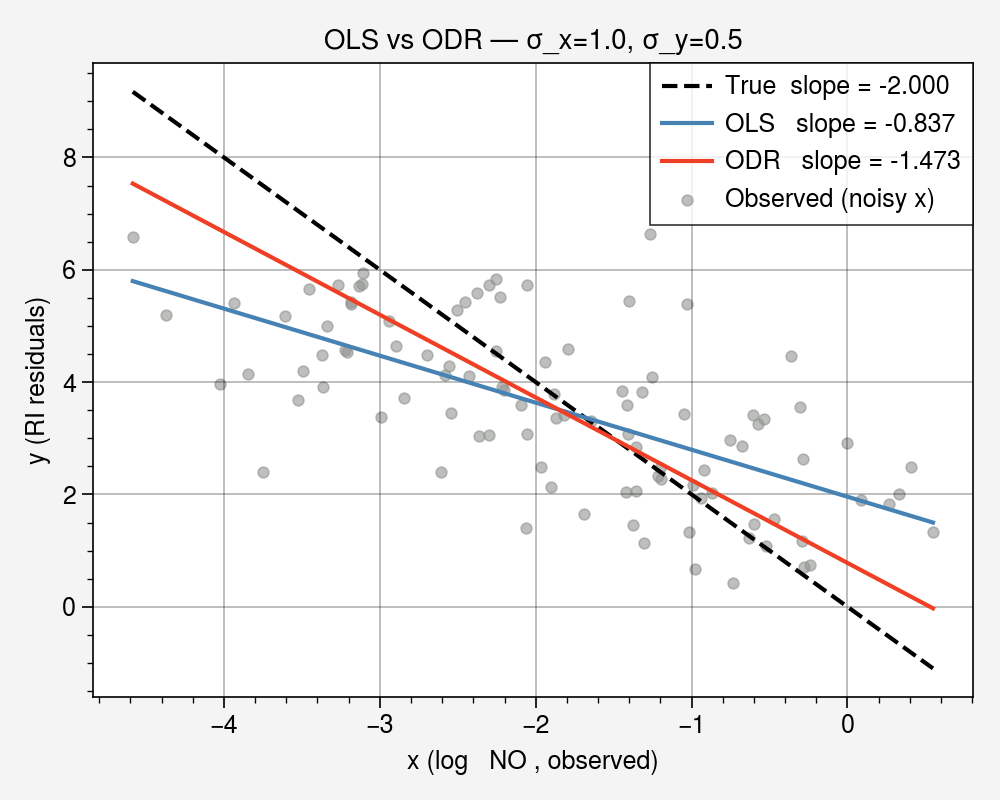

In [74]:
# ═════════════════════════════════════════════════════════════════════════════
# OLS vs ODR comparison with toy data
# (ODR matters when x has measurement error)
# ═════════════════════════════════════════════════════════════════════════════
np.random.seed(42)

n_toy       = 100    # Bumped up for a clearer cloud
true_slope  = -2.0    # STEEP SLOPE!
true_inter  = 0.0
sigma_x_toy = 1.0    # High x noise
sigma_y_toy = 0.5    # Bumped up y noise slightly so it's not a perfect line

x_true = np.linspace(-3, -0.5, n_toy)
y_true = true_slope * x_true + true_inter

x_obs  = x_true + np.random.normal(0, sigma_x_toy, n_toy)
y_obs  = y_true + np.random.normal(0, sigma_y_toy, n_toy)

ols_toy = ols_fit(x_obs, y_obs)
odr_toy = odr_fit_cal(x_obs, y_obs,
                      slope0=ols_toy['slope'], inter0=ols_toy['inter'],
                      sx=np.full(n_toy, sigma_x_toy),
                      sy=None)

print(f"True slope : {true_slope:.4f}")
print(f"OLS slope  : {ols_toy['slope']:.4f} ± {ols_toy['se']:.4f}  "
      f"(bias = {ols_toy['slope'] - true_slope:+.4f})")
print(f"ODR slope  : {odr_toy['slope']:.4f} ± {odr_toy['se']:.4f}  "
      f"(bias = {odr_toy['slope'] - true_slope:+.4f})")

xx_toy = np.linspace(x_obs.min(), x_obs.max(), 200)

fig_toy, ax_toy = plt.subplots(figsize=(5, 4))
ax_toy.scatter(x_obs, y_obs, c='gray', s=15, alpha=0.6, label='Observed (noisy x)')
ax_toy.plot(xx_toy, true_slope * xx_toy + true_inter,
            'k--', lw=1.5, label=f'True  slope = {true_slope:.3f}')
ax_toy.plot(xx_toy, ols_toy['slope'] * xx_toy + ols_toy['inter'],
            color='steelblue', lw=1.5,
            label=f"OLS   slope = {ols_toy['slope']:.3f}")
ax_toy.plot(xx_toy, odr_toy['slope'] * xx_toy + odr_toy['inter'],
            color='tomato', lw=1.5,
            label=f"ODR   slope = {odr_toy['slope']:.3f}")
ax_toy.set_xlabel('x (log₁₀ NO₃, observed)')
ax_toy.set_ylabel('y (RI residuals)')
ax_toy.set_title(f'OLS vs ODR — σ_x={sigma_x_toy}, σ_y={sigma_y_toy}')
ax_toy.legend(fontsize=9)
ax_toy.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Variance Partitioning and Model Performance | Frequentist

In [75]:
from TEXAS.stats import f_test

In [76]:
"""
run_variance_partitioning(df, mode='hierarchical', ...)
--------------------------------------------------------
Two fitting strategies for the GDGT multivariate variance-partitioning
analysis, selected via `mode`:

  'hierarchical'  (default)
      1. Fit T curve on culture + mesocosm data only  -> popt_cm  (prior approx)
      2. Re-optimise ALL T parameters jointly on coretop (starting from popt_cm)
      3. Fit betas on coretop jointly with T parameters
      Coretop baseline: coretop-re-optimised T-only fit.

  'fixed_global'  (classical)
      1. Fit T curve on the FULL dataset (all datatypes)
      2. Fix those T parameters; fit ONLY betas on coretop
      Coretop baseline: global T curve evaluated on coretop points.

ODR beta comparison (optional)
---------------------------------
Pass `gdgt23_se_col` and/or `no3_se_col` to run a two-step ODR regression
alongside the OLS (curve_fit) fits.  ODR accounts for measurement error in
the non-thermal predictor (x-axis):

  Step 1: compute T-only residuals from the baseline T fit.
  Step 2: regress residuals on the predictor via ODR, using per-site SEs
          as sx.  Results are printed in TABLE 2 alongside OLS.
  Step 3: reconstruct predictions (Y_pred = Baseline + ODR_slope * X + ODR_int)
          to calculate full model R² and RMSE, printed in TABLE 1.

Dependencies (must be in caller namespace)
------------------------------------------
  generalized_logistic_model_fixed_upper(T, x0, b, k, v) -> array
  find_optimal_no3_threshold(no3, residuals, threshold_range) -> (float, _)
  f_test(rss_reduced, rss_full, k_reduced, k_full, n)          -> (F, p)

All sig-fig helpers are defined locally so this module is fully self-contained.
"""

import math
import numpy as np
from scipy.optimize import curve_fit


# ── sig-fig helpers (self-contained) ─────────────────────────────────────────

def _n_decimals(scale: float) -> int:
    """Decimal places needed to show `scale` to 1-2 sig figs (GUM §7.2.6)."""
    if not math.isfinite(scale) or scale <= 0:
        return 3
    mag = math.floor(math.log10(abs(scale)))
    first_digit = int(abs(scale) / 10 ** mag)
    return max(0, 1 - mag) if first_digit <= 3 else max(0, -mag)


def _format_stat(median: float, std: float, fmt: str | None = None) -> str:
    """Return 'median ± std' formatted to appropriate significant figures."""
    if fmt is not None:
        return f"{median:{fmt}} ± {std:{fmt}}"
    if not math.isfinite(std) or std <= 0:
        return f"{median:.3g}"
    n_dec = _n_decimals(std)
    fmt   = f".{n_dec}f"
    return f"{round(median, n_dec):{fmt}} ± {round(std, n_dec):{fmt}}"


# ── formatting helpers ────────────────────────────────────────────────────────

def _fmt_r2(r2: float) -> str:
    """R² precision driven by unexplained variance; capped at 3 d.p."""
    n = min(_n_decimals(1 - r2), 3)
    return f"{round(r2, n):.{n}f}"

def _fmt_rmse(rmse: float) -> str:
    """RMSE always reported to 2 sig figs."""
    mag = math.floor(math.log10(abs(rmse)))
    n   = max(0, 1 - mag)
    return f"{round(rmse, n):.{n}f}"

def _fmt_delta_r2(dr2: float) -> str:
    if abs(dr2) == 0: return f"{dr2:.3f}"
    n = _n_decimals(abs(dr2))
    return f"{round(dr2, n):.{n}f}"

def _fmt_p(p: float) -> str:
    if p is None: return "—"
    if p < 0.001: return "<0.001"
    mag = math.floor(math.log10(abs(p)))
    return f"{round(p, -mag + 1):.2e}"

def _fmt_coef(coef: float, ci_halfwidth: float) -> str:
    """coef ± 95% CI, precision driven by CI half-width."""
    if coef is None: return "—"
    sigma = ci_halfwidth / 1.96
    return _format_stat(coef, sigma)

def _fmt_delta(delta: float) -> str:
    """Delta to 2 sig figs with sign."""
    if abs(delta) == 0: return "+0.000"
    d_mag = math.floor(math.log10(abs(delta)))
    nd    = max(0, 1 - d_mag)
    return f"{delta:+.{nd}f}"


# ── bootstrap SE ─────────────────────────────────────────────────────────────

def _bootstrap_se(fit_fn, X, y, p0, bounds, n_boot=500, seed=42):
    """Row-resampling bootstrap SE for a curve_fit model."""
    rng   = np.random.default_rng(seed)
    n     = len(y)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        X_b = X[idx]
        y_b = y[idx]
        try:
            p, _ = curve_fit(fit_fn, X_b, y_b, p0=p0, bounds=bounds, max_nfev=10000)
            boots.append(p)
        except RuntimeError:
            pass
    boots = np.array(boots)
    if len(boots) < 10:
        return np.full(len(p0), np.nan), boots
    return boots.std(axis=0), boots


# ── shared internal model ─────────────────────────────────────────────────────

def _multivariate_model(X, x0, b, k, v, betaG23=0.0, betaNO3=0.0, threshold=1.7):
    if X.ndim == 1:
        X = X.reshape(1, -1)
    t, g23, no3 = X[:, 0], X[:, 1], X[:, 2]
    pred = generalized_logistic_model_fixed_upper(t, x0, b, k, v)
    pred = pred + betaG23 * g23
    if betaNO3 != 0:
        no3_term = np.zeros_like(no3, dtype=float)
        mask = (no3 > 0) & (no3 < threshold)
        no3_term[mask] = betaNO3 * np.log10(no3[mask] + 1e-9)
        pred = pred + no3_term
    return pred


def _calc_stats(y_true, y_pred):
    resid = y_true - y_pred
    rss   = float(np.sum(resid ** 2))
    r2    = float(1 - rss / np.sum((y_true - np.mean(y_true)) ** 2))
    rmse  = float(np.sqrt(np.mean(resid ** 2)))
    return r2, rmse, rss


# ── main function ─────────────────────────────────────────────────────────────

def run_variance_partitioning(
    gridded_combined_df,
    *,
    mode: str = "hierarchical",
    x_param: str = "SST",
    y_param: str = "scaledRI",
    no3_fill_value: float = 10.0,
    no3_threshold_range=None,
    no3_threshold=None,
    n_boot: int = 500,
    boot_seed: int = 42,
    # ── ODR options ────────────────────────────────────────────────
    gdgt23_se_col: str | None = None,
    no3_se_col: str | None = None,
    sd_proxyObs_col: str | None = None,   # per-site RI analytical SE column (Stan: sd_proxyObs)
    sigma_ri_analytical: float = 0.03,    # fallback scalar analytical SE (Schouten et al. 2013 Rs ≈ 0.03)
    no3_se_floor: float = 0.001,
    no3_se_cap: float = 1.0,
    t_reopt_n_sigma: float | None = 3.0,
):
    if mode not in ("hierarchical", "fixed_global"):
        raise ValueError("mode must be 'hierarchical' or 'fixed_global'")

    if (no3_threshold_range is None) and (no3_threshold is None):
        no3_threshold_range = np.arange(0.5, 5, 0.01)


    def _run_odr_both(gdgt23, log_no3_all, no3_mask, y_resid, sx_g23, sx_no3_log_full, sy):
        """Joint bivariate ODR: residual ~ b_G23*gdgt23 + b_NO3*log10(no3) + intercept.

        Points above the NO3 threshold are zeroed out (x_no3=0, sx_no3=1e6) so
        they contribute to the GDGT-2/3 slope estimate but not the NO3 slope.
        """
        from scipy.odr import ODR, Model, RealData
        x_no3  = np.where(no3_mask, log_no3_all, 0.0)
        sx_no3 = np.where(no3_mask, sx_no3_log_full, 1e6)
        X2  = np.vstack([gdgt23, x_no3])
        SX2 = np.vstack([sx_g23, sx_no3])
        def _bivar(b, x): return b[0] * x[0] + b[1] * x[1] + b[2]
        result = ODR(
            RealData(X2, y_resid, sx=SX2, sy=sy),
            Model(_bivar),
            beta0=[-0.006, -0.03, 0.0],
        ).run()
        sl_g, sl_n, ic = result.beta
        se_g, se_n, _  = result.sd_beta
        return sl_g, sl_n, ic, se_g, se_n

    def _run_odr(x, y, sx, sy, beta0=None):
        from scipy.odr import ODR, Model, RealData
        def _linear(b, x_): return b[0] * x_ + b[1]
        if beta0 is None:
            p = np.polyfit(x, y, 1)
            beta0 = [p[0], p[1]]
        result  = ODR(RealData(x, y, sx=sx, sy=sy), Model(_linear), beta0=beta0).run()
        sl, ic  = result.beta
        se_sl, se_ic = result.sd_beta
        ss_res  = np.sum(result.eps ** 2)
        r2      = 1 - ss_res / np.sum((y - np.mean(y)) ** 2)
        return sl, ic, se_sl, se_ic, r2

    df = gridded_combined_df.copy()
    df["no3_sf2tc_avg"] = [
        no3_fill_value if n != "coretop" and np.isnan(x) else x
        for x, n in zip(df["no3_sf2tc_avg"], df["datatype"])
    ]
    df = df.dropna(subset=[x_param, y_param, "gdgt23ratio", "no3_sf2tc_avg"])
    df = df.sort_values(
        "datatype",
        key=lambda s: s.map({"coretop": 0, "mesocosm": 1, "culture": 2}),
    ).reset_index(drop=True)

    ct_mask   = df["datatype"] == "coretop"
    XX_ct_T   = df.loc[ct_mask, x_param].values
    XX_ct_g23 = df.loc[ct_mask, "gdgt23ratio"].values
    XX_ct_no3 = df.loc[ct_mask, "no3_sf2tc_avg"].values
    YY_ct     = df.loc[ct_mask, y_param].values
    n_ct      = len(YY_ct)
    X_ct      = np.column_stack([XX_ct_T, XX_ct_g23, XX_ct_no3])

    # =========================================================================
    # MODE A: hierarchical
    # =========================================================================
    if mode == "hierarchical":
        cm_mask = df["datatype"].isin(["culture", "mesocosm"])
        XX_cm   = df.loc[cm_mask, x_param].values
        YY_cm   = df.loc[cm_mask, y_param].values
        n_init  = int(cm_mask.sum())

        popt_cm, pcov_cm = curve_fit(
            generalized_logistic_model_fixed_upper, XX_cm, YY_cm,
            p0=[20, 0.1, 0.1, 0.1], bounds=([0, 0, 0, 0], [40, 0.5, 1, 5]),
        )
        pred_cm  = generalized_logistic_model_fixed_upper(XX_cm, *popt_cm)
        r2_cm    = float(1 - np.sum((YY_cm - pred_cm)**2) / np.sum((YY_cm - np.mean(YY_cm))**2))
        rmse_cm  = float(np.sqrt(np.mean((YY_cm - pred_cm)**2)))

        if n_boot > 0:
            def _cm_fit_fn(T_1d, x0, b, k, v): return generalized_logistic_model_fixed_upper(T_1d, x0, b, k, v)
            bse_cm, _ = _bootstrap_se(_cm_fit_fn, XX_cm, YY_cm, p0=list(popt_cm),
                                      bounds=([0, 0, 0, 0], [40, 0.5, 1, 5]), n_boot=n_boot, seed=boot_seed)
        else:
            bse_cm = np.sqrt(np.diag(pcov_cm))

        p0_T       = list(popt_cm)                                                                                                                      
        _global_lo = np.array([10,  0,    0,    0  ])                                                                                                   
        _global_hi = np.array([50,  0.5,  0.5,  5  ])                                                                                                   
        if t_reopt_n_sigma is not None and np.all(np.isfinite(bse_cm)):
            _p = np.array(popt_cm)                                                                                                                      
            _s = np.array(bse_cm) * t_reopt_n_sigma                                                                                                     
            bounds_lo = list(np.clip(_p - _s, _global_lo, _global_hi - 1e-6).tolist())
            bounds_hi = list(np.clip(_p + _s, _global_lo + 1e-6, _global_hi).tolist())                                                                  
        else:                                                                                                                                           
            bounds_lo = list(_global_lo)
            bounds_hi = list(_global_hi)
        def _fit_T(X, x0, b, k, v): return _multivariate_model(X, x0, b, k, v)

        popt_T, pcov_T = curve_fit(_fit_T, X_ct, YY_ct, p0=p0_T, bounds=(bounds_lo, bounds_hi))
        pred_T_base = _fit_T(X_ct, *popt_T)
        resid_T     = YY_ct - pred_T_base
        r2_base, rmse_base, rss_base = _calc_stats(YY_ct, pred_T_base)
        k_base = 4

        if n_boot > 0:
            bse_T, _ = _bootstrap_se(_fit_T, X_ct, YY_ct, p0=p0_T,
                                     bounds=(bounds_lo, bounds_hi), n_boot=n_boot, seed=boot_seed)
        else:
            bse_T = np.sqrt(np.diag(pcov_T))

        if no3_threshold is not None:
            thr = no3_threshold
        else:
            thr, _ = find_optimal_no3_threshold(XX_ct_no3, resid_T, threshold_range=no3_threshold_range)
            thr = round(float(thr), 1)

        # ── Shared log-NO3 quantities (used by both OLS and ODR) ─────────────
        log_no3_ct   = np.log10(XX_ct_no3 + 1e-9)
        no3_odr_mask = (XX_ct_no3 > 0) & (XX_ct_no3 < thr)
        x_n_sub      = log_no3_ct[no3_odr_mask]
        y_n_sub      = resid_T[no3_odr_mask]
        n_no3        = int(no3_odr_mask.sum())

        # ── Two-step residual OLS (θ_T fixed at popt_T; consistent with ODR) ─
        # Univariate: GDGT-2/3
        m_g, c_g  = np.polyfit(XX_ct_g23, resid_T, 1)
        pred_Tg   = pred_T_base + m_g * XX_ct_g23 + c_g
        r2_Tg, rmse_Tg, rss_Tg = _calc_stats(YY_ct, pred_Tg)
        sse_g     = float(np.sum((resid_T - (m_g * XX_ct_g23 + c_g)) ** 2))
        sxx_g     = float(np.sum((XX_ct_g23 - XX_ct_g23.mean()) ** 2))
        ci_Tg_beta = 1.96 * np.sqrt(sse_g / ((n_ct - 2) * sxx_g))

        # Univariate: NO3 (sub-threshold points only)
        m_n, c_n  = np.polyfit(x_n_sub, y_n_sub, 1)
        pred_Tn   = pred_T_base.copy()
        pred_Tn[no3_odr_mask] += m_n * x_n_sub + c_n
        r2_Tn, rmse_Tn, rss_Tn = _calc_stats(YY_ct, pred_Tn)
        sse_n     = float(np.sum((y_n_sub - (m_n * x_n_sub + c_n)) ** 2))
        sxx_n     = float(np.sum((x_n_sub - x_n_sub.mean()) ** 2))
        ci_Tn_beta = 1.96 * np.sqrt(sse_n / ((n_no3 - 2) * sxx_n))

        # Multivariate: GDGT-2/3 + NO3 (NO3 zeroed above threshold, matching ODR)
        x_n_full  = np.where(no3_odr_mask, log_no3_ct, 0.0)
        A_mul     = np.column_stack([XX_ct_g23, x_n_full, np.ones(n_ct)])
        coefs_mul, _, _, _ = np.linalg.lstsq(A_mul, resid_T, rcond=None)
        m_g_mul, m_n_mul, c_mul = coefs_mul
        pred_Tf   = pred_T_base + m_g_mul * XX_ct_g23 + np.where(no3_odr_mask, m_n_mul * log_no3_ct, 0.0) + c_mul
        r2_Tf, rmse_Tf, rss_Tf = _calc_stats(YY_ct, pred_Tf)
        s2_mul    = float(np.sum((resid_T - A_mul @ coefs_mul) ** 2)) / (n_ct - 3)
        cov_mul   = s2_mul * np.linalg.inv(A_mul.T @ A_mul)
        ci_g_mul  = 1.96 * float(np.sqrt(cov_mul[0, 0]))
        ci_n_mul  = 1.96 * float(np.sqrt(cov_mul[1, 1]))

        # Stubs for return dict (T params unchanged; betas are two-step scalars)
        popt_Tg   = list(popt_T) + [m_g]
        popt_Tn   = list(popt_T) + [m_n]
        popt_Tf   = list(popt_T) + [m_g_mul, m_n_mul]
        pcov_Tg   = pcov_Tn = pcov_Tf = None   # no joint covariance in two-step OLS

        F_Tg, p_Tg = f_test(rss_base, rss_Tg, k_base, k_base + 1, n_ct)
        F_Tn, p_Tn = f_test(rss_base, rss_Tn, k_base, k_base + 1, n_ct)
        F_Tf, p_Tf = f_test(rss_base, rss_Tf, k_base, k_base + 2, n_ct)

        beta_g23_biv = (m_g,     ci_Tg_beta)
        beta_no3_biv = (m_n,     ci_Tn_beta)
        beta_g23_mul = (m_g_mul, ci_g_mul)
        beta_no3_mul = (m_n_mul, ci_n_mul)

        # T-curve params in +Both are identical to T-only (θ_T fixed); reuse bse_T
        bse_Tf_display = list(bse_T) + [ci_g_mul / 1.96, ci_n_mul / 1.96]

        init_label, init_r2, init_rmse = f"CulMeso T (n={n_init})", r2_cm, rmse_cm
        base_label = "Coretop T (baseline)"
        mode_note  = f"Hierarchical: CulMeso → Coretop T re-opt, two-step residual OLS/ODR betas  |  NO3 threshold: {thr:.1f} µmol/L"
        popt_init, pcov_init, bse_init = popt_cm,  pcov_cm,  bse_cm
        popt_base, pcov_base, bse_base = popt_T,   pcov_T,   bse_T
        popt_full, pcov_full, bse_full = popt_Tf,  None,     bse_Tf_display

    # =========================================================================
    # MODE B: fixed_global
    # =========================================================================
    else:
        XX_all, YY_all = df[x_param].values, df[y_param].values
        n_init = int(len(YY_all))

        popt_glob, pcov_glob = curve_fit(
            generalized_logistic_model_fixed_upper, XX_all, YY_all,
            p0=[20, 0.1, 0.2, 1], bounds=([0, 0, 0, 0.1], [50, 0.5, 5, 5]),
        )
        pred_glob_all = generalized_logistic_model_fixed_upper(XX_all, *popt_glob)
        r2_glob   = float(1 - np.sum((YY_all - pred_glob_all)**2) / np.sum((YY_all - np.mean(YY_all))**2))
        rmse_glob = float(np.sqrt(np.mean((YY_all - pred_glob_all)**2)))

        if n_boot > 0:
            def _glob_fit_fn(T_1d, x0, b, k, v): return generalized_logistic_model_fixed_upper(T_1d, x0, b, k, v)
            bse_glob, _ = _bootstrap_se(_glob_fit_fn, XX_all, YY_all, p0=list(popt_glob),
                                        bounds=([0, 0, 0, 0.1], [50, 0.5, 5, 5]), n_boot=n_boot, seed=boot_seed)
        else:
            bse_glob = np.sqrt(np.diag(pcov_glob))

        pred_T_base = generalized_logistic_model_fixed_upper(XX_ct_T, *popt_glob)
        resid_T     = YY_ct - pred_T_base
        r2_base, rmse_base, rss_base = _calc_stats(YY_ct, pred_T_base)
        k_base = 0

        if no3_threshold is not None:
            thr = no3_threshold
        else:
            thr, _ = find_optimal_no3_threshold(XX_ct_no3, resid_T, threshold_range=no3_threshold_range)
            thr = round(float(thr), 1)

        bounds_lo_ct, bounds_hi_ct = [0, 0, 0, 0.1], [50, 0.5, 5, 5]
        def _fit_T_ct(X, x0, b, k, v): return _multivariate_model(X, x0, b, k, v)
        popt_T_ct, pcov_T_ct = curve_fit(_fit_T_ct, X_ct, YY_ct, p0=list(popt_glob), bounds=(bounds_lo_ct, bounds_hi_ct))
        bse_T_ct = _bootstrap_se(_fit_T_ct, X_ct, YY_ct, p0=list(popt_glob), bounds=(bounds_lo_ct, bounds_hi_ct), n_boot=n_boot, seed=boot_seed)[0] if n_boot > 0 else np.sqrt(np.diag(pcov_T_ct))

        def _fit_g(X, bg): return _multivariate_model(X, *popt_glob, betaG23=bg, threshold=thr)
        def _fit_n(X, bn): return _multivariate_model(X, *popt_glob, betaNO3=bn, threshold=thr)
        def _fit_f(X, bg, bn): return _multivariate_model(X, *popt_glob, betaG23=bg, betaNO3=bn, threshold=thr)

        popt_Tg, pcov_Tg = curve_fit(_fit_g, X_ct, YY_ct, p0=[-0.01], bounds=([-0.2], [0]))
        popt_Tn, pcov_Tn = curve_fit(_fit_n, X_ct, YY_ct, p0=[-0.01], bounds=([-0.2], [0]))
        popt_Tf, pcov_Tf = curve_fit(_fit_f, X_ct, YY_ct, p0=[-0.01, -0.01], bounds=([-0.2, -0.2], [0, 0]))

        pred_Tg, pred_Tn, pred_Tf = _fit_g(X_ct, *popt_Tg), _fit_n(X_ct, *popt_Tn), _fit_f(X_ct, *popt_Tf)
        r2_Tg, rmse_Tg, rss_Tg = _calc_stats(YY_ct, pred_Tg)
        r2_Tn, rmse_Tn, rss_Tn = _calc_stats(YY_ct, pred_Tn)
        r2_Tf, rmse_Tf, rss_Tf = _calc_stats(YY_ct, pred_Tf)

        ci_Tg, ci_Tn, ci_Tf = 1.96 * np.sqrt(np.diag(pcov_Tg)), 1.96 * np.sqrt(np.diag(pcov_Tn)), 1.96 * np.sqrt(np.diag(pcov_Tf))

        F_Tg, p_Tg = f_test(rss_base, rss_Tg, k_base, k_base + 1, n_ct)
        F_Tn, p_Tn = f_test(rss_base, rss_Tn, k_base, k_base + 1, n_ct)
        F_Tf, p_Tf = f_test(rss_base, rss_Tf, k_base, k_base + 2, n_ct)

        beta_g23_biv, beta_no3_biv = (popt_Tg[0], ci_Tg[0]), (popt_Tn[0], ci_Tn[0])
        beta_g23_mul, beta_no3_mul = (popt_Tf[0], ci_Tf[0]), (popt_Tf[1], ci_Tf[1])

        init_label, init_r2, init_rmse = f"Global T (all data, n={n_init})", r2_glob, rmse_glob
        base_label = "Global T on coretop (fixed)"
        mode_note  = f"Fixed-global T  |  NO3 threshold: {thr:.1f} µmol/L"
        popt_init, pcov_init, bse_init = popt_glob, pcov_glob, bse_glob
        popt_base, pcov_base, bse_base = popt_T_ct, pcov_T_ct, bse_T_ct
        popt_full, pcov_full, bse_full = None, None, None

    # =========================================================================
    # ODR beta estimation & Prediction Reconstruction
    # =========================================================================
    _do_odr     = (gdgt23_se_col is not None) or (no3_se_col is not None)
    odr_g23_biv = None
    odr_no3_biv = None
    odr_both    = None

    if _do_odr:
        # ── Parallel to Stan: proxyObs_res_se = mean(sd_proxyObs) · √(1 − R²_thermal) ──
        # In Stan, sigma_proxyObs_crtp ~ N(0, proxyObs_res_se) (half-normal prior).
        # Here we use the same quantity as a point estimate of process noise,
        # then combine with analytical SE in quadrature to form sy for ODR.
        #   r2_base == R²_thermal (T-only coretop R²) in both modes.
        if sd_proxyObs_col is not None:
            _sd_obs_ct = df.loc[ct_mask, sd_proxyObs_col].values.astype(float)
            _sd_obs_ct = np.where(
                np.isfinite(_sd_obs_ct) & (_sd_obs_ct > 0),
                _sd_obs_ct, sigma_ri_analytical,
            )
            mean_sd_proxyObs = float(np.mean(_sd_obs_ct))
        else:
            _sd_obs_ct   = np.full(n_ct, sigma_ri_analytical)
            mean_sd_proxyObs = sigma_ri_analytical

        # Process noise: Stan's proxyObs_res_se (prior scale on sigma_proxyObs_crtp).
        # Alternative (more direct but less parallel):
        #   sigma_proc_est = np.sqrt(max(0.0, rmse_base**2 - mean_sd_proxyObs**2))
        sigma_proc_est = mean_sd_proxyObs * np.sqrt(max(0.0, 1.0 - r2_base))

        # Total sy: analytical ⊕ process noise in quadrature (Stan: total_sd per site).
        _sy_ct = np.sqrt(_sd_obs_ct**2 + sigma_proc_est**2)

        if gdgt23_se_col is not None:
            sx_g23 = df.loc[ct_mask, gdgt23_se_col].values.astype(float)
            sx_g23 = np.where(~np.isfinite(sx_g23) | (sx_g23 <= 0), no3_se_cap, sx_g23)
            sl_g23, ic_g23, se_g23, _, r2_g23_odr = _run_odr(XX_ct_g23, resid_T, sx=sx_g23, sy=_sy_ct)
            
            # Reconstruct model predictions using ODR slope and intercept
            pred_odr_g = pred_T_base + sl_g23 * XX_ct_g23 + ic_g23
            r2_odr_g, rmse_odr_g, _ = _calc_stats(YY_ct, pred_odr_g)
            
            odr_g23_biv = dict(slope=sl_g23, intercept=ic_g23, se=se_g23, r2=r2_g23_odr, 
                               n=n_ct, r2_model=r2_odr_g, rmse_model=rmse_odr_g)

        if no3_se_col is not None:
            no3_se_lin  = df.loc[ct_mask, no3_se_col].values.astype(float)
            sx_no3_log  = no3_se_lin / (XX_ct_no3 * np.log(10))
            sx_no3_log  = np.where(~np.isfinite(sx_no3_log) | (sx_no3_log <= 0), no3_se_cap, sx_no3_log)
            sx_no3_log  = np.clip(sx_no3_log, no3_se_floor, no3_se_cap)
            
            no3_odr_mask = (XX_ct_no3 > 0) & (XX_ct_no3 < thr)
            log_no3_ct   = np.log10(XX_ct_no3 + 1e-9)
            sl_no3, ic_no3, se_no3, _, r2_no3_odr = _run_odr(
                log_no3_ct[no3_odr_mask], resid_T[no3_odr_mask],
                sx=sx_no3_log[no3_odr_mask],
                sy=_sy_ct[no3_odr_mask],
            )
            
            # Reconstruct model predictions using ODR slope and intercept (for sub-threshold)
            pred_odr_n = pred_T_base.copy()
            pred_odr_n[no3_odr_mask] += sl_no3 * log_no3_ct[no3_odr_mask] + ic_no3
            r2_odr_n, rmse_odr_n, _ = _calc_stats(YY_ct, pred_odr_n)
            
            odr_no3_biv = dict(slope=sl_no3, intercept=ic_no3, se=se_no3, r2=r2_no3_odr, 
                               n=int(no3_odr_mask.sum()), r2_model=r2_odr_n, rmse_model=rmse_odr_n)

        # Joint bivariate ODR (both predictors simultaneously)
        if gdgt23_se_col is not None and no3_se_col is not None:
            # Build full-n log-NO3 SE (sx_no3_log was computed for the sub-threshold subset above)
            sx_no3_log_full = no3_se_lin / (XX_ct_no3 * np.log(10))
            sx_no3_log_full = np.where(~np.isfinite(sx_no3_log_full) | (sx_no3_log_full <= 0), no3_se_cap, sx_no3_log_full)
            sx_no3_log_full = np.clip(sx_no3_log_full, no3_se_floor, no3_se_cap)

            sl_g, sl_n, ic_b, se_g, se_n = _run_odr_both(
                XX_ct_g23, log_no3_ct, no3_odr_mask,
                resid_T, sx_g23, sx_no3_log_full, _sy_ct,
            )
            pred_odr_b = (pred_T_base + sl_g * XX_ct_g23 + ic_b).copy()
            pred_odr_b[no3_odr_mask] += sl_n * log_no3_ct[no3_odr_mask]
            r2_odr_b, rmse_odr_b, _ = _calc_stats(YY_ct, pred_odr_b)
            odr_both = dict(
                slope_g23=sl_g, slope_no3=sl_n,
                se_g23=se_g, se_no3=se_n,
                r2_model=r2_odr_b, rmse_model=rmse_odr_b,
            )

    unique_g23 = r2_Tf - r2_Tn
    unique_no3 = r2_Tf - r2_Tg

    # =========================================================================
    # TABLE 1 — Variance partitioning
    # =========================================================================
    W = 108
    print("=" * W)
    print(
        f"VARIANCE PARTITIONING — Coretop only (n={n_ct})\n"
        f"{mode_note}\n"
        f"x_param: {x_param}  |  y_param: {y_param}"
    )
    print("=" * W)
    print(f"{'Model':<30} {'R²':>8} {'ΔR²':>8} {'β_G23':>20} {'β_NO3':>20} {'RMSE':>8} {'F':>7} {'p':>10}")
    print("-" * W)

    print(f"{init_label:<30} {_fmt_r2(init_r2):>8} {'—':>8} {'—':>20} {'—':>20} {_fmt_rmse(init_rmse):>8} {'—':>7} {'—':>10}")
    print(f"{base_label:<30} {_fmt_r2(r2_base):>8} {'—':>8} {'—':>20} {'—':>20} {_fmt_rmse(rmse_base):>8} {'—':>7} {'—':>10}")
    
    # GDGT-2/3 Models
    dr2_g = r2_Tg - r2_base
    print(f"{'  + GDGT-2/3 (OLS)':<30} {_fmt_r2(r2_Tg):>8} {_fmt_delta_r2(dr2_g):>8} {_fmt_coef(*beta_g23_biv):>20} {'—':>20} {_fmt_rmse(rmse_Tg):>8} {F_Tg:>7.0f} {_fmt_p(p_Tg):>10}")
    if _do_odr and odr_g23_biv:
        dr2_g_odr = odr_g23_biv['r2_model'] - r2_base
        beta_str = _fmt_coef(odr_g23_biv['slope'], odr_g23_biv['se'] * 1.96)
        print(f"{'  + GDGT-2/3 (ODR)':<30} {_fmt_r2(odr_g23_biv['r2_model']) + '†':>8} {_fmt_delta_r2(dr2_g_odr):>8} {beta_str:>20} {'—':>20} {_fmt_rmse(odr_g23_biv['rmse_model']):>8} {'—':>7} {'—':>10}")

    # NO3 Models
    dr2_n = r2_Tn - r2_base
    print(f"{'  + NO3 (OLS)':<30} {_fmt_r2(r2_Tn):>8} {_fmt_delta_r2(dr2_n):>8} {'—':>20} {_fmt_coef(*beta_no3_biv):>20} {_fmt_rmse(rmse_Tn):>8} {F_Tn:>7.0f} {_fmt_p(p_Tn):>10}")
    if _do_odr and odr_no3_biv:
        dr2_n_odr = odr_no3_biv['r2_model'] - r2_base
        beta_str = _fmt_coef(odr_no3_biv['slope'], odr_no3_biv['se'] * 1.96)
        print(f"{'  + NO3 (ODR)':<30} {_fmt_r2(odr_no3_biv['r2_model']) + '†':>8} {_fmt_delta_r2(dr2_n_odr):>8} {'—':>20} {beta_str:>20} {_fmt_rmse(odr_no3_biv['rmse_model']):>8} {'—':>7} {'—':>10}")

    dr2_f = r2_Tf - r2_base
    print(f"{'  + Both (OLS)':<30} {_fmt_r2(r2_Tf):>8} {_fmt_delta_r2(dr2_f):>8} {_fmt_coef(*beta_g23_mul):>20} {_fmt_coef(*beta_no3_mul):>20} {_fmt_rmse(rmse_Tf):>8} {F_Tf:>7.0f} {_fmt_p(p_Tf):>10}")
    if _do_odr and odr_both:
        dr2_b_odr = odr_both['r2_model'] - r2_base
        bg_str = _fmt_coef(odr_both['slope_g23'], odr_both['se_g23'] * 1.96)
        bn_str = _fmt_coef(odr_both['slope_no3'], odr_both['se_no3'] * 1.96)
        print(f"{'  + Both (ODR)':<30} {_fmt_r2(odr_both['r2_model']) + '†':>8} {_fmt_delta_r2(dr2_b_odr):>8} {bg_str:>20} {bn_str:>20} {_fmt_rmse(odr_both['rmse_model']):>8} {'—':>7} {'—':>10}")
    print("-" * W)
    u_g_n = _n_decimals(abs(unique_g23)) if abs(unique_g23) > 0 else 3
    u_n_n = _n_decimals(abs(unique_no3)) if abs(unique_no3) > 0 else 3
    print(f"  Unique GDGT-2/3 : {unique_g23:.{u_g_n}f}  ({100 * unique_g23:.1f} %)")
    print(f"  Unique NO3      : {unique_no3:.{u_n_n}f}  ({100 * unique_no3:.1f} %)")
    
    if _do_odr:
        print(
            f"  ODR sy (per site): analytical SE={mean_sd_proxyObs:.4f}  "
            f"process noise σ={sigma_proc_est:.4f}  "
            f"(= {mean_sd_proxyObs:.4f}·√(1−{_fmt_r2(r2_base)}))"
        )
        print(f"  † R² from vertical residuals; ODR minimises orthogonal distance — not directly comparable to OLS R².")
    # =========================================================================
    # TABLE 2 — Coefficients (OLS vs ODR comparison)
    # =========================================================================
    print()
    print("=" * W)
    print("COEFFICIENTS  (point estimate ± 95 % CI)")
    print("=" * W)
    C1, C2, C3, C4 = 16, 28, 28, 28
    print(
        f"{'Predictor':<{C1}} {'OLS Biv. (Joint T+X)':<{C2}} "
        f"{'OLS Mult. (Joint T+X+Y)':<{C3}} {'ODR Biv. (2-step resid)':<{C4}}"
    )
    print("-" * W)

    def _fmt_odr(odr_dict):
        if odr_dict is None: return "—"
        return _fmt_coef(odr_dict['slope'], odr_dict['se'] * 1.96)

    print(f"{'β_GDGT-2/3':<{C1}} {_fmt_coef(*beta_g23_biv):<{C2}} {_fmt_coef(*beta_g23_mul):<{C3}} {_fmt_odr(odr_g23_biv):<{C4}}")
    print(f"{'β_NO3':<{C1}} {_fmt_coef(*beta_no3_biv):<{C2}} {_fmt_coef(*beta_no3_mul):<{C3}} {_fmt_odr(odr_no3_biv):<{C4}}")
    
    if _do_odr:
        print("-" * W)
        print("  Note: OLS betas are optimized jointly with T-curve parameters.")
        print("        ODR betas are derived from two-step regression on T-residuals to account for x-axis error.")
        if odr_both:
            print("        ODR 'Both' uses joint bivariate ODR; NO3 above threshold zeroed (sx=1e6).")

    # =========================================================================
    # TABLE 3 — T-curve parameters
    # =========================================================================
    boot_note = f"bootstrap 1σ, n={n_boot}" if n_boot > 0 else "Jacobian 1σ (x0 SE may be unreliable)"
    COL = 28
    print()
    print("=" * W)

    if mode == "hierarchical":
        print(f"T-CURVE PARAMETER SHIFT  (hierarchical mode | {boot_note})")
        print("  Delta: Coretop T-only minus CulMeso (2 sig figs)")
        print("=" * W)
        print(f"{'Param':<6} {'CulMeso':<{COL}} {'Coretop T-only':<{COL}} {'Coretop +Both':<{COL}} {'Δ(cm→ct)'}")
        print("-" * W)
        for i, name in enumerate(["x0", "b", "k", "ν"]):
            p_cm, p_ct, p_full = popt_init[i], popt_base[i], popt_full[i]
            delta = p_ct - p_cm
            print(f"  {name:<4} {_format_stat(p_cm, bse_init[i]):<{COL}} {_format_stat(p_ct, bse_base[i]):<{COL}} {_format_stat(p_full, bse_full[i]):<{COL}} {_fmt_delta(delta)}")

    else:
        print(f"T-CURVE PARAMETERS  (fixed_global mode | {boot_note})")
        print("  Single global fit; T is identical across all models")
        print("=" * W)
        print(f"{'Param':<6} {'Global T (all data)':<{COL}}")
        print("-" * W)
        for i, name in enumerate(["x0", "b", "k", "ν"]):
            print(f"  {name:<4} {_format_stat(popt_init[i], bse_init[i]):<{COL}}")

    # ── return dict ───────────────────────────────────────────────────────────
    out = dict(
        mode = mode, n_coretop = n_ct, no3_threshold = thr, n_boot = n_boot,
        popt_init = popt_init, pcov_init = pcov_init, bse_init = bse_init,
        popt_base = popt_base, pcov_base = pcov_base, bse_base = bse_base,
        r2 = dict(init=init_r2, base=r2_base, Tg=r2_Tg, Tn=r2_Tn, Tf=r2_Tf),
        rmse = dict(init=init_rmse, base=rmse_base, Tg=rmse_Tg, Tn=rmse_Tn, Tf=rmse_Tf),
        F = dict(Tg=F_Tg, Tn=F_Tn, Tf=F_Tf), p = dict(Tg=p_Tg, Tn=p_Tn, Tf=p_Tf),
        unique_variance = dict(gdgt23=unique_g23, no3=unique_no3),
        beta_g23 = dict(biv=beta_g23_biv, mul=beta_g23_mul),
        beta_no3 = dict(biv=beta_no3_biv, mul=beta_no3_mul),
        odr_g23 = odr_g23_biv, odr_no3 = odr_no3_biv, odr_both = odr_both,
        sigma_proc_est = sigma_proc_est if _do_odr else None,
        mean_sd_proxyObs = mean_sd_proxyObs if _do_odr else None,
        popt_Tg=popt_Tg, pcov_Tg=pcov_Tg, popt_Tn=popt_Tn, pcov_Tn=pcov_Tn,
        popt_Tf=popt_Tf, pcov_Tf=pcov_Tf,
    )
    if mode == "hierarchical":
        out.update(dict(popt_culmeso=popt_init, pcov_culmeso=pcov_init, bse_culmeso=bse_init,
                        popt_T=popt_base, pcov_T=pcov_base, bse_T=bse_base, bse_Tf_Tparams=bse_full[:4]))
    else:
        out.update(dict(popt_global=popt_init, pcov_global=pcov_init, bse_global=bse_init))
    return out

In [77]:
display_function_signature(run_variance_partitioning)

```python
run_variance_partitioning(
    gridded_combined_df,
    mode=hierarchical,
    x_param=SST,
    y_param=scaledRI,
    no3_fill_value=10.0,
    no3_threshold_range=None,
    no3_threshold=None,
    n_boot=500,
    boot_seed=42,
    gdgt23_se_col=None,
    no3_se_col=None,
    sd_proxyObs_col=None,
    sigma_ri_analytical=0.03,
    no3_se_floor=0.001,
    no3_se_cap=1.0,
    t_reopt_n_sigma=3.0
)
```

In [78]:
# Preferred approach — T re-optimised on coretop after culmeso init
res_hier = run_variance_partitioning(gridded_combined_df,
                                     mode='hierarchical',
                                     x_param='SST',
                                     y_param='scaledRI_cren3',
                                     no3_se_col='thermoNO3_se',
                                     gdgt23_se_col='gdgt23ratio_se',
                                     no3_threshold=1)   # or 't_sf2tc_avg'

VARIANCE PARTITIONING — Coretop only (n=1513)
Hierarchical: CulMeso → Coretop T re-opt, two-step residual OLS/ODR betas  |  NO3 threshold: 1.0 µmol/L
x_param: SST  |  y_param: scaledRI_cren3
Model                                R²      ΔR²                β_G23                β_NO3     RMSE       F          p
------------------------------------------------------------------------------------------------------------
CulMeso T (n=63)                   0.73        —                    —                    —    0.091       —          —
Coretop T (baseline)               0.75        —                    —                    —    0.058       —          —
  + GDGT-2/3 (OLS)                 0.78    0.031     -0.0058 ± 0.0004                    —    0.054     207     <0.001
  + GDGT-2/3 (ODR)                0.78†    0.031     -0.0059 ± 0.0004                    —    0.054       —          —
  + NO3 (OLS)                      0.76    0.018                    —     -0.0290 ± 0.0036    0.055     1

Using res_hier popt_T: [30.26184963  0.43320495  0.12863823  1.2232674 ]
Thermal R² (coretop) = 0.747  →  ODR sy = 0.0151

[G23] gdgt23ratio > 0 → n = 1513
  Per-region Spearman:
              region   rho  pval   n
  Mozambique Channel -0.90  0.00  30
         Barents Sea -0.73  0.00  28
      SOUTHERN OCEAN -0.61  0.00  61
        INDIAN OCEAN -0.46  0.00  88
North Atlantic Ocean -0.39  0.00 169
         Weddell Sea -0.37  0.22  13
        Arctic Ocean -0.35  0.01  60
         Arabian Sea -0.35  0.03  40
            Kara Sea -0.33  0.10  26
     South China Sea -0.30  0.00 117
          Laptev Sea -0.26  0.35  15
            Ross Sea -0.21  0.56  10
      Sea of Okhotsk -0.14  0.60  16
       Greenland Sea -0.14  0.57  19
      East China Sea -0.12  0.49  35
 North Pacific Ocean -0.08  0.57  54
South Atlantic Ocean -0.06  0.36 207
 South Pacific Ocean -0.05  0.57 126
             Red Sea -0.01  0.96  20
          Yellow Sea  0.12  0.52  31
           Black Sea  0.15  0.47  25
       

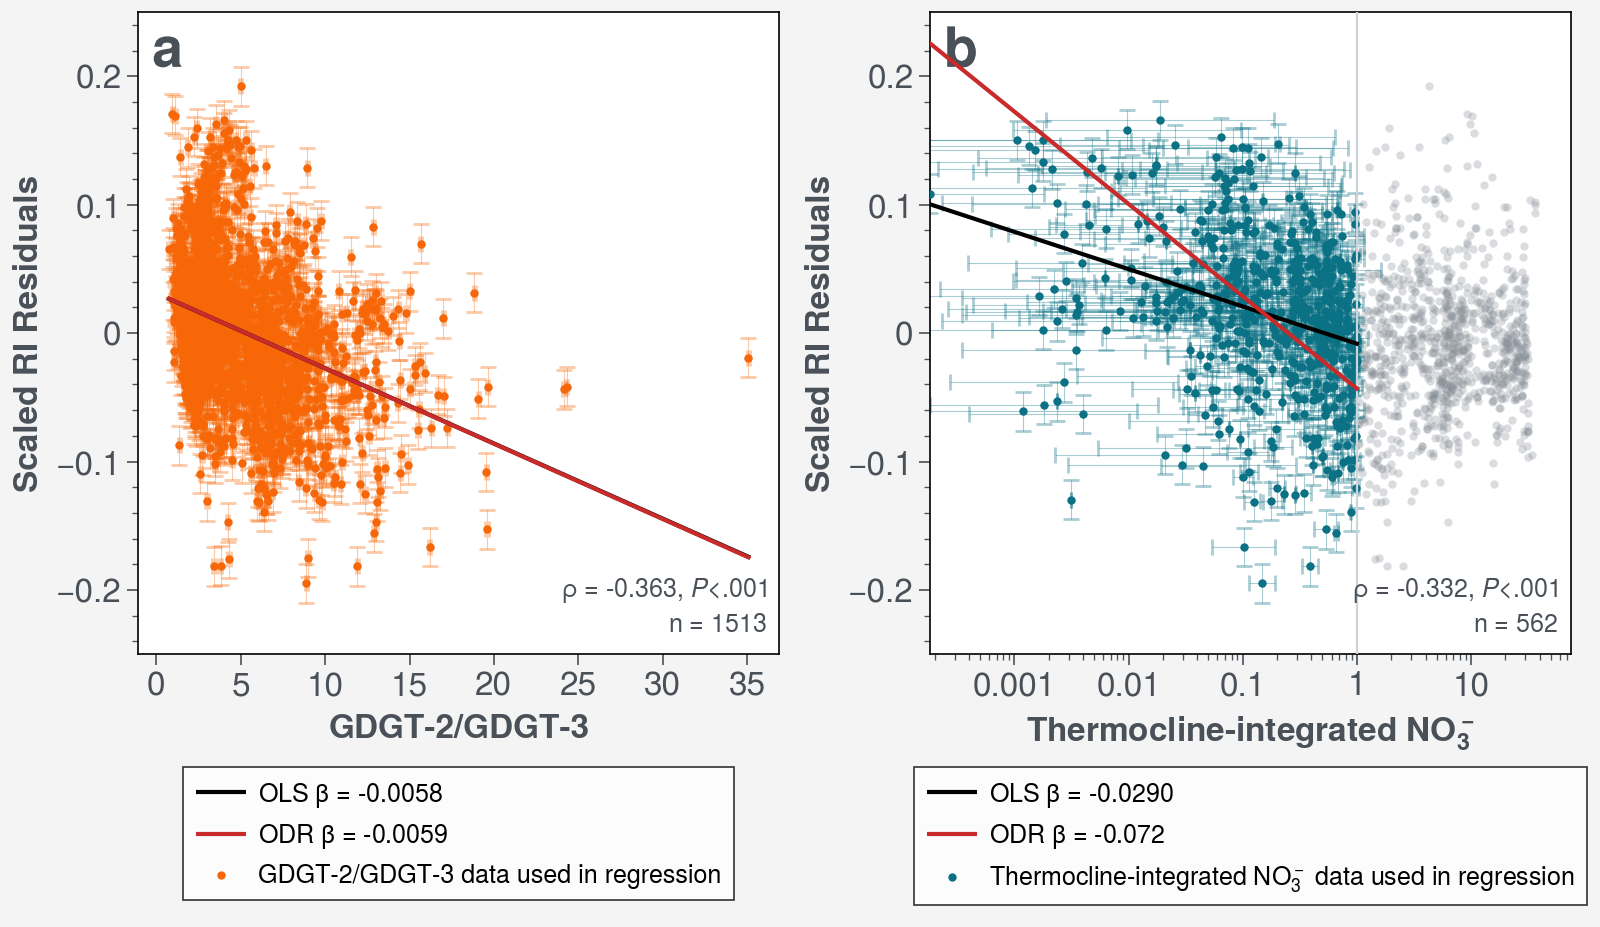

In [79]:
# ═════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════════════════
x_param          = 'SST'
y_param          = 'scaledRI_cren3'
scaledRI_se      = 0.03
show_xerr        = True
show_sig_regions = False
NO3_SE_FLOOR     = 0.0001
NO3_SE_CAP       = 1.0

MODES = {
    'G23': dict(
        sel_nonthermal_param    = 'gdgt23ratio',
        sel_nonthermal_param_se = 'gdgt23ratio_se',
        param_threshold         = None,
        threshold_direction     = 'lower',
        param_label             = r'GDGT-2/GDGT-3',
        se_is_log10             = False,
        log_x                   = False,
        stan_param_name         = 'beta_G23_crtp',
        pt_color                = 'orange7',
        display_label           = r'G2/3 (all)',
    ),
    'NO3': dict(
        sel_nonthermal_param    = 'no3_sf2tc_avg',
        sel_nonthermal_param_se = 'thermoNO3_se',
        param_threshold         = 1,
        threshold_direction     = 'upper',
        param_label             = r'Thermocline-integrated NO$_3^-$',
        se_is_log10             = False,
        log_x                   = True,
        stan_param_name         = 'beta_NO3_crtp',
        pt_color                = 'cyan9',
        display_label           = r'[NO$_{\text{3}}^{-}$] $\leq$ 1.0 $\mu$mol/L',
    ),
}

# ─── helpers ─────────────────────────────────────────────────────────────────
def _threshold_label(param, threshold, direction):
    if threshold is None:
        return f'{param} > 0'
    return f'{param} ≥ {threshold}' if direction == 'lower' else f'{param} ≤ {threshold}'

def compute_xerr(x_vals, se_raw, se_is_log10, log_x):
    if log_x:
        se_log10 = se_raw if se_is_log10 else se_raw / (x_vals * np.log(10))
        se_log10 = np.clip(se_log10, NO3_SE_FLOOR, NO3_SE_CAP)
        xerr_lo  = x_vals - 10 ** (np.log10(x_vals) - se_log10)
        xerr_hi  = 10 ** (np.log10(x_vals) + se_log10) - x_vals
    else:
        se_lin  = se_raw * x_vals * np.log(10) if se_is_log10 else se_raw
        se_lin  = np.clip(se_lin, 0, None)
        xerr_lo = se_lin
        xerr_hi = se_lin
    return xerr_lo, xerr_hi

def _odr_sx(raw_se, x_lin, se_is_log10, log_x):
    if log_x:
        if se_is_log10:
            return raw_se
        else:
            return raw_se / (x_lin * np.log(10))
    else:
        if se_is_log10:
            return raw_se * x_lin * np.log(10)
        else:
            return raw_se

# ═════════════════════════════════════════════════════════════════════════════
# Step 0: sigmoid fit + residuals — computed ONCE, shared by both modes
# ═════════════════════════════════════════════════════════════════════════════
plot_data  = gridded_combined_df.copy()
ct_mask    = plot_data['datatype'] == 'coretop'
valid_mask = plot_data[y_param].notna() & plot_data[x_param].notna()

XX = plot_data.loc[valid_mask & ct_mask, x_param].values
YY = plot_data.loc[valid_mask & ct_mask, y_param].values

popt     = res_hier['popt_T']
r2_therm = res_hier['r2']['base']
sy_resid = scaledRI_se * np.sqrt(max(0.0, 1.0 - r2_therm))
print(f'Using res_hier popt_T: {popt}')
print(f'Thermal R² (coretop) = {r2_therm:.3f}  →  ODR sy = {sy_resid:.4f}')

plot_data['pred_' + y_param] = generalized_logistic_model_fixed_upper(
    plot_data[x_param], *popt)
plot_data[y_param + '_res']  = plot_data[y_param] - plot_data['pred_' + y_param]
coretop_data = plot_data[ct_mask].copy()

# ═════════════════════════════════════════════════════════════════════════════
# Steps 1–7: per-mode computation → store in `results`
# ═════════════════════════════════════════════════════════════════════════════
results = {}

for mode, cfg in MODES.items():
    sel_param    = cfg['sel_nonthermal_param']
    sel_param_se = cfg['sel_nonthermal_param_se']
    threshold    = cfg['param_threshold']
    direction    = cfg['threshold_direction']
    se_is_log10  = cfg['se_is_log10']
    log_x        = cfg['log_x']
    thr_label    = _threshold_label(sel_param, threshold, direction)

    # Step 1: threshold filter
    tmask = coretop_data[sel_param] > 0
    if threshold is not None:
        tmask &= (coretop_data[sel_param] <= threshold
                  if direction == 'upper'
                  else coretop_data[sel_param] >= threshold)
    sub_global = coretop_data[tmask]
    print(f'\n[{mode}] {thr_label} → n = {len(sub_global)}')

    # Step 2: per-region Spearman (always in log10 — rank-invariant)
    region_stats = []
    for region, grp in sub_global.groupby('ocean_region'):
        sub = grp[[sel_param, y_param + '_res']].dropna()
        if len(sub) < 10:
            continue
        rho, pval = spearmanr(np.log10(sub[sel_param]), sub[y_param + '_res'])
        region_stats.append(dict(region=region, rho=rho, pval=pval, n=len(sub),
                                 max_param=sub[sel_param].max()))
    region_stats_df = pd.DataFrame(region_stats).sort_values('rho')
    print('  Per-region Spearman:\n' +
          region_stats_df[['region','rho','pval','n']].to_string(index=False))

    # Step 3: region selection (unused when show_sig_regions=False)
    sig_neg_regions  = []
    region_color_map = {}
    region_label     = 'all data'

    # Step 6b: global OLS + ODR — both two-step on T-residuals
    global_data = sub_global.dropna(subset=[sel_param, y_param + '_res'])
    if sel_param_se in sub_global.columns:
        global_data = global_data.dropna(subset=[sel_param_se])

    x_lin_all = global_data[sel_param].values
    ri_g      = global_data[y_param + '_res'].values
    nt_g      = np.log10(x_lin_all) if log_x else x_lin_all

    if sel_param_se in global_data.columns:
        raw_se = global_data[sel_param_se].values.astype(float)
        se_g   = _odr_sx(raw_se, x_lin_all, se_is_log10, log_x)
    else:
        se_g = np.full(len(global_data), 0.1)
    se_g = np.clip(se_g, NO3_SE_FLOOR, NO3_SE_CAP)

    ols_g = ols_fit(nt_g, ri_g)

    _odr_key  = 'odr_g23' if mode == 'G23' else 'odr_no3'
    _odr_dict = res_hier[_odr_key]
    if _odr_dict is not None:
        _odr_slope = _odr_dict['slope']
        _odr_se    = _odr_dict['se']
        _odr_inter = float(np.mean(ri_g) - _odr_slope * np.mean(nt_g))
        odr_g = dict(slope=_odr_slope, inter=_odr_inter, se=_odr_se,
                     ci68_lo=_odr_slope - _odr_se, ci68_hi=_odr_slope + _odr_se)
    else:
        odr_g = dict(slope=ols_g['slope'], inter=ols_g['inter'], se=ols_g['se'],
                     ci68_lo=ols_g['ci68_lo'], ci68_hi=ols_g['ci68_hi'])

    print(f'  [two-step OLS] slope={ols_g["slope"]:.4f} ± {ols_g["se"]:.4f}  '
          f'R²={ols_g["r2"]:.3f}')
    print(f'  [two-step ODR] slope={odr_g["slope"]:.4f} ± {odr_g["se"]:.4f}')

    rho_g, pval_g = spearmanr(np.log10(x_lin_all), ri_g)
    pval_lbl_g    = label_pvalues(pval_g)

    prior_mu    = round_to_n_sf(ols_g['slope'],   2)
    prior_sigma = round_to_n_sf(ols_g['se'],      2)
    prior_cons  = round_to_n_sf(ols_g['se'] * 2, 2)
    print(f'  Stan prior: {cfg["stan_param_name"]} ~ normal({prior_mu}, {prior_sigma})  '
          f'[conservative: normal({prior_mu}, {prior_cons})]')

    if log_x:
        xx_log_g = np.linspace(nt_g.min(), nt_g.max(), 200)
        xx_lin_g = 10 ** xx_log_g
        yy_ols_g = ols_g['slope'] * xx_log_g + ols_g['inter']
        yy_odr_g = odr_g['slope'] * xx_log_g + odr_g['inter']
    else:
        xx_lin_g = np.linspace(nt_g.min(), nt_g.max(), 200)
        yy_ols_g = ols_g['slope'] * xx_lin_g + ols_g['inter']
        yy_odr_g = odr_g['slope'] * xx_lin_g + odr_g['inter']

    results[mode] = dict(
        cfg=cfg, thr_label=thr_label, region_label=region_label,
        sub_global=sub_global, global_data=global_data,
        sig_neg_regions=sig_neg_regions, region_color_map=region_color_map,
        region_stats_df=region_stats_df,
        ols_g=ols_g, odr_g=odr_g,
        rho_g=rho_g, pval_g=pval_g, pval_lbl_g=pval_lbl_g,
        nt_g=nt_g, ri_g=ri_g,
        xx_lin_g=xx_lin_g, yy_ols_g=yy_ols_g, yy_odr_g=yy_odr_g,
        prior_mu=prior_mu, prior_sigma=prior_sigma, n_global=len(global_data),
    )

# ═════════════════════════════════════════════════════════════════════════════
# Step 9: figure — 1 row × 2 cols: [G23 scatter | NO3 scatter]
# ═════════════════════════════════════════════════════════════════════════════
fig, axs = plot.subplots(ncols=2, width=8, share=0)

for col_idx, mode in enumerate(['G23', 'NO3']):
    r            = results[mode]
    cfg          = r['cfg']
    ax_scat      = axs[col_idx]
    sel_param    = cfg['sel_nonthermal_param']
    sel_param_se = cfg['sel_nonthermal_param_se']
    se_is_log10  = cfg['se_is_log10']
    log_x        = cfg['log_x']
    param_label  = cfg['param_label']
    pt_color     = cfg['pt_color']
    threshold    = cfg['param_threshold']

    # ── background: all coretop ───────────────────────────────────────────────
    ax_scat.scatter(coretop_data[sel_param], coretop_data[y_param + '_res'],
                    c='gray6', marker='.', alpha=0.3, zorder=1, mew=0,
                    label='')

    if threshold is not None:
        ax_scat.axvline(x=threshold, color='gray4', ls='-', lw=0.8, zorder=3)

    # ── error bars ────────────────────────────────────────────────────────────
    if show_xerr and sel_param_se in r['global_data'].columns:
        gd_se  = r['global_data'].dropna(subset=[sel_param_se])
        x_vals = gd_se[sel_param].values
        xerr_lo, xerr_hi = compute_xerr(
            x_vals, gd_se[sel_param_se].values, se_is_log10, log_x)
        ax_scat.errorbar(x_vals, gd_se[y_param + '_res'].values,
                         xerr=[xerr_lo, xerr_hi],
                         yerr=sy_resid,
                         fmt='none', ecolor=pt_color,
                         elinewidth=0.4, alpha=0.35, zorder=2)

    # ── colored points ────────────────────────────────────────────────────────
    
    _thr_str = rf"$\leq 1.0$ $\mu$mol/L" if mode == 'NO3' else r""
    ax_scat.scatter(r['global_data'][sel_param], r['global_data'][y_param + '_res'],
                    c=pt_color, marker='.', zorder=3, mew=0,
                    label=(rf"{param_label} data used in regression"))

    # ── regression lines ──────────────────────────────────────────────────────
    ols_g, odr_g = r['ols_g'], r['odr_g']
    _ols_hw  = abs(ols_g['ci68_hi'] - ols_g['slope'])
    _odr_hw  = abs(odr_g['ci68_hi'] - odr_g['slope'])
    _ols_dec = max(_n_decimals(_ols_hw), 3)
    _odr_dec = max(_n_decimals(_odr_hw), 3)

    ax_scat.plot(r['xx_lin_g'], r['yy_ols_g'], color='k',      lw=1.5, ls='-', zorder=4,
                 label=rf"OLS $\beta$ = {ols_g['slope']:.{_ols_dec}f}")
    ax_scat.plot(r['xx_lin_g'], r['yy_odr_g'], color='red9', lw=1.5, ls='-', zorder=4,
                 label=rf"ODR $\beta$ = {odr_g['slope']:.{_odr_dec}f}")

    # ── annotations ───────────────────────────────────────────────────────────
    for i, txt in enumerate([
        rf"$\rho$ = {r['rho_g']:.3f}, {r['pval_lbl_g']}",
        rf"$n$ = {r['n_global']}",
    ]):
        ax_scat.text(0.98, 0.10 - i*0.055, txt, transform=ax_scat.transAxes,
                     ha='right', va='center', c='gray7', fontsize=9)

    ax_scat.legend(loc='b', ncol=1, fontsize=7.5)

    ax_scat.format(
        xscale='log' if log_x else 'linear',
        xtickminor=log_x,
        xlabel=param_label,
        ylabel='Scaled RI Residuals',
        ylim=(-0.25, 0.25), grid=False,
        fontsize=11, labelsize=11,
        labelcolor='gray7', xtickcolor='gray7', ytickcolor='gray7',
        xticklabelcolor='gray7', yticklabelcolor='gray7',
        xlabelweight='bold', ylabelweight='bold',
    )

plot.rc['abc'] = True
axs.format(
    labelsize=12, fontsize=12, labelweight='bold',
    grid=False,
    abc=True, abcstyle='a', abcsize=20, abcweight='bold', abcloc='ul',
    abccolor='gray7', labelcolor='gray7', textcolor='gray7',
    tickcolor='gray7', ticklabelcolor='gray7',
    xreverse=False,
)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig6_ODR_regression_dilution.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [80]:
fpath = os.path.join(local_github_path,'data/spreadsheets')
fname = 'ds_gridded_screened_global_compilation_finalized'

gridded_combined_df.to_csv(os.path.join(fpath, fname + '.csv'), index=False)